In [ ]:
import sys
sys.argv = [sys.argv[0]]

In [ ]:
"""Minimal predictive-coding world model with local learning rules.

Designed for Google Colab / NVIDIA T4, but includes a CPU smoke-test mode.
No autograd is used for learning. All parameter changes are explicit local
prediction-error x presynaptic-activity updates.
"""

from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm



@dataclass
class PCConfig:
    # Reproducibility / device
    seed: int = 7
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Environment and model dimensions. Multiples of 8 are friendly to T4 matmuls.
    state_dim: int = 32
    latent_dim: int = 32
    obs_dim: int = 32
    action_dim: int = 8
    batch_size: int = 4096

    # Training
    train_steps: int = 1400
    inference_steps: int = 12
    inference_rate: float = 0.08
    observation_precision: float = 1.0
    temporal_precision: float = 0.5
    latent_decay: float = 1e-4

    # Strictly local synaptic learning rates
    lr_observation: float = 0.003
    lr_transition: float = 0.08
    lr_action: float = 0.08
    weight_decay: float = 1e-6
    weight_clip: float = 4.0

    # Environment
    dynamics_radius: float = 0.92
    action_scale: float = 0.12
    action_std: float = 0.55
    process_noise: float = 0.01
    observation_noise: float = 0.01
    mixed_observations: bool = False

    # Optional nonstationarity test. Set shift_step=None for stationary training.
    shift_step: Optional[int] = None
    shift_strength: float = 0.35

    # T4 path: autocast only forward/inference matmuls; local update accumulators stay FP32.
    use_amp: bool = True

    # Stable monitoring: no image is redrawn inside the training loop.
    visualize: bool = True
    progress_every: int = 20
    record_checkpoints: bool = True
    checkpoint_every: int = 100
    max_checkpoints: int = 40
    tracked_batch_index: int = 0

    # Evaluation
    eval_batch_size: int = 1024
    rollout_horizon: int = 20

    def validate(self) -> None:
        if self.latent_dim != self.state_dim:
            raise ValueError(
                "This first-principles notebook keeps latent_dim == state_dim so the "
                "baseline is identifiable. Change both together."
            )
        if not self.mixed_observations and self.obs_dim != self.state_dim:
            raise ValueError(
                "With mixed_observations=False, obs_dim must equal state_dim."
            )
        if self.batch_size < 1 or self.inference_steps < 1:
            raise ValueError("batch_size and inference_steps must be positive.")


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def stable_matrix(dim: int, radius: float, device: torch.device) -> torch.Tensor:
    """Return a random matrix rescaled to a requested spectral radius."""
    matrix = torch.randn(dim, dim, device=device, dtype=torch.float32)
    spectral_radius = torch.linalg.eigvals(matrix).abs().max().real.clamp_min(1e-6)
    return matrix * (radius / spectral_radius)


class ControlledLinearWorld:
    """Ground-truth controlled linear dynamical system.

    x[t+1] = F x[t] + G a[t] + process noise
    o[t]   = C x[t] + observation noise
    """

    def __init__(self, cfg: PCConfig):
        self.cfg = cfg
        self.device = torch.device(cfg.device)
        self.F = stable_matrix(cfg.state_dim, cfg.dynamics_radius, self.device)
        self.G = (
            torch.randn(cfg.state_dim, cfg.action_dim, device=self.device)
            * cfg.action_scale
        )

        if cfg.mixed_observations:
            # Tall orthonormal observation map when obs_dim >= state_dim.
            if cfg.obs_dim < cfg.state_dim:
                raise ValueError("mixed_observations requires obs_dim >= state_dim.")
            raw = torch.randn(cfg.obs_dim, cfg.state_dim, device=self.device)
            self.C = torch.linalg.qr(raw, mode="reduced").Q
        else:
            self.C = torch.eye(cfg.state_dim, device=self.device)

        self.x: Optional[torch.Tensor] = None

    @torch.no_grad()
    def reset(self, batch_size: int) -> torch.Tensor:
        self.x = 0.25 * torch.randn(
            batch_size, self.cfg.state_dim, device=self.device
        )
        return self.observe()

    @torch.no_grad()
    def observe(self) -> torch.Tensor:
        if self.x is None:
            raise RuntimeError("Call reset before observe.")
        noise = self.cfg.observation_noise * torch.randn(
            self.x.shape[0], self.cfg.obs_dim, device=self.device
        )
        return self.x @ self.C.T + noise

    @torch.no_grad()
    def step(self, action: torch.Tensor) -> torch.Tensor:
        if self.x is None:
            raise RuntimeError("Call reset before step.")
        process_noise = self.cfg.process_noise * torch.randn_like(self.x)
        self.x = self.x @ self.F.T + action @ self.G.T + process_noise
        return self.observe()

    @torch.no_grad()
    def shift_dynamics(self, strength: float) -> None:
        """Abruptly alter dynamics while preserving stability."""
        new_F = stable_matrix(self.cfg.state_dim, self.cfg.dynamics_radius, self.device)
        mixed_F = (1.0 - strength) * self.F + strength * new_F
        radius = torch.linalg.eigvals(mixed_F).abs().max().real.clamp_min(1e-6)
        self.F = mixed_F * (self.cfg.dynamics_radius / radius)

        new_G = torch.randn_like(self.G) * self.cfg.action_scale
        self.G = (1.0 - strength) * self.G + strength * new_G


class PredictiveCodingWorldModel:
    """Single-level predictive-coding world model.

    Predictions:
        z_hat = A z_prev + B action
        o_hat = W z

    Errors:
        e_z = z - z_hat
        e_o = observation - o_hat

    Activity update:
        z <- z + alpha * (pi_o e_o W - pi_z e_z - lambda z)

    Local synaptic updates after inference settles:
        W <- W + eta_W pi_o e_o^T z
        A <- A + eta_A pi_z e_z^T z_prev
        B <- B + eta_B pi_z e_z^T action
    """

    def __init__(self, cfg: PCConfig):
        self.cfg = cfg
        self.device = torch.device(cfg.device)

        self.A = torch.zeros(
            cfg.latent_dim, cfg.latent_dim, device=self.device, dtype=torch.float32
        )
        self.B = torch.zeros(
            cfg.latent_dim, cfg.action_dim, device=self.device, dtype=torch.float32
        )

        if not cfg.mixed_observations and cfg.obs_dim == cfg.latent_dim:
            self.W = torch.eye(cfg.obs_dim, device=self.device)
            self.W.add_(0.08 * torch.randn_like(self.W))
        else:
            self.W = torch.randn(
                cfg.obs_dim, cfg.latent_dim, device=self.device, dtype=torch.float32
            ) / math.sqrt(cfg.latent_dim)

        self.amp_enabled = cfg.use_amp and self.device.type == "cuda"

    @torch.no_grad()
    def infer(
        self,
        observation: torch.Tensor,
        z_previous: torch.Tensor,
        action: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        cfg = self.cfg

        # Autocast is used only for repeated forward/inference matmuls.
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=self.amp_enabled,
        ):
            z_prediction = z_previous @ self.A.T + action @ self.B.T
            prior_observation_prediction = z_prediction @ self.W.T
            z = z_prediction.clone()

            for _ in range(cfg.inference_steps):
                observation_prediction = z @ self.W.T
                observation_error = observation - observation_prediction
                temporal_error = z - z_prediction

                sensory_drive = observation_error @ self.W
                z = z + cfg.inference_rate * (
                    cfg.observation_precision * sensory_drive
                    - cfg.temporal_precision * temporal_error
                    - cfg.latent_decay * z
                )

            observation_prediction = z @ self.W.T
            observation_error = observation - observation_prediction
            temporal_error = z - z_prediction

        # FP32 snapshots are used for local learning and metrics.
        z = z.float()
        z_prediction = z_prediction.float()
        observation_prediction = observation_prediction.float()
        prior_observation_prediction = prior_observation_prediction.float()
        observation_error = observation_error.float()
        temporal_error = temporal_error.float()

        return {
            "observation": observation.float(),
            "z": z,
            "z_prediction": z_prediction,
            "observation_prediction": observation_prediction,
            "prior_observation_prediction": prior_observation_prediction,
            "observation_error": observation_error,
            "temporal_error": temporal_error,
        }

    @torch.no_grad()
    def local_update(
        self,
        z: torch.Tensor,
        z_previous: torch.Tensor,
        action: torch.Tensor,
        observation_error: torch.Tensor,
        temporal_error: torch.Tensor,
    ) -> Dict[str, float]:
        cfg = self.cfg
        inv_batch = 1.0 / z.shape[0]

        # Each outer product is local: postsynaptic error x presynaptic activity.
        delta_W = (
            cfg.observation_precision
            * (observation_error.T @ z)
            * inv_batch
        )
        delta_A = (
            cfg.temporal_precision
            * (temporal_error.T @ z_previous)
            * inv_batch
        )
        delta_B = (
            cfg.temporal_precision
            * (temporal_error.T @ action)
            * inv_batch
        )

        self.W.add_(cfg.lr_observation * delta_W)
        self.A.add_(cfg.lr_transition * delta_A)
        self.B.add_(cfg.lr_action * delta_B)

        # Both regularizers are synapse-local.
        if cfg.weight_decay:
            decay = 1.0 - cfg.weight_decay
            self.W.mul_(decay)
            self.A.mul_(decay)
            self.B.mul_(decay)

        if cfg.weight_clip:
            self.W.clamp_(-cfg.weight_clip, cfg.weight_clip)
            self.A.clamp_(-cfg.weight_clip, cfg.weight_clip)
            self.B.clamp_(-cfg.weight_clip, cfg.weight_clip)

        return {
            "delta_W_rms": delta_W.square().mean().sqrt().item(),
            "delta_A_rms": delta_A.square().mean().sqrt().item(),
            "delta_B_rms": delta_B.square().mean().sqrt().item(),
        }

    @torch.no_grad()
    def predict_next(self, z: torch.Tensor, action: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z_next = z @ self.A.T + action @ self.B.T
        o_next = z_next @ self.W.T
        return z_next, o_next

    @torch.no_grad()
    def plan_cem(
        self,
        z_start: torch.Tensor,
        target_observation: torch.Tensor,
        horizon: int = 15,
        population: int = 1024,
        elites: int = 96,
        iterations: int = 5,
        action_penalty: float = 0.01,
    ) -> torch.Tensor:
        """Optional model-predictive controller using the learned local world model.

        z_start must contain one latent state: shape [1, latent_dim].
        Returns a single action sequence of shape [horizon, action_dim].
        """
        if z_start.shape[0] != 1:
            raise ValueError("plan_cem expects exactly one starting state.")

        mean = torch.zeros(horizon, self.cfg.action_dim, device=self.device)
        std = torch.ones_like(mean) * self.cfg.action_std
        target = target_observation.reshape(1, -1)

        for _ in range(iterations):
            noise = torch.randn(population, horizon, self.cfg.action_dim, device=self.device)
            actions = mean.unsqueeze(0) + std.unsqueeze(0) * noise
            z = z_start.expand(population, -1).clone()
            total_cost = torch.zeros(population, device=self.device)

            for k in range(horizon):
                z, o = self.predict_next(z, actions[:, k])
                total_cost.add_((o - target).square().mean(dim=1))
                total_cost.add_(action_penalty * actions[:, k].square().mean(dim=1))

            elite_ids = torch.topk(total_cost, k=elites, largest=False).indices
            elite_actions = actions[elite_ids]
            mean = elite_actions.mean(dim=0)
            std = elite_actions.std(dim=0).clamp_min(0.05)

        return mean


class StableTrainingMonitor:
    """Stable notebook monitor with no Matplotlib rendering during training.

    The progress bar is one persistent text display. Weight/activity tensors are copied
    to CPU only at sparse checkpoints and rendered later as ordinary Matplotlib figures.
    """

    def __init__(self, cfg: PCConfig):
        self.cfg = cfg
        self.checkpoints: List[Dict[str, object]] = []
        self.progress = None
        self.last_progress_step = 0

        if cfg.visualize:
            self.progress = tqdm(
                total=cfg.train_steps,
                desc="local predictive coding",
                unit="step",
                leave=True,
                dynamic_ncols=True,
            )

    def should_record(self, step: int) -> bool:
        if not self.cfg.record_checkpoints:
            return False
        return (
            step == 1
            or step % self.cfg.checkpoint_every == 0
            or step == self.cfg.train_steps
        )

    @torch.no_grad()
    def record(
        self,
        step: int,
        model: PredictiveCodingWorldModel,
        metrics: Dict[str, float],
        z: torch.Tensor,
        temporal_error: torch.Tensor,
        observation_error: torch.Tensor,
        shifted: bool,
    ) -> None:
        i = min(self.cfg.tracked_batch_index, z.shape[0] - 1)
        checkpoint = {
            "step": int(step),
            "shifted": bool(shifted),
            "metrics": {key: float(value) for key, value in metrics.items()},
            "A": model.A.detach().float().cpu().clone(),
            "B": model.B.detach().float().cpu().clone(),
            "W": model.W.detach().float().cpu().clone(),
            "z": z[i].detach().float().cpu().clone(),
            "temporal_error": temporal_error[i].detach().float().cpu().clone(),
            "observation_error": observation_error[i].detach().float().cpu().clone(),
        }
        self.checkpoints.append(checkpoint)

        # Keep the first checkpoint plus the most recent checkpoints if the user
        # chooses a very small maximum.
        if len(self.checkpoints) > self.cfg.max_checkpoints:
            self.checkpoints.pop(1 if len(self.checkpoints) > 1 else 0)

    def update_progress(
        self,
        step: int,
        metrics: Dict[str, float],
        shifted: bool,
        force: bool = False,
    ) -> None:
        if self.progress is None:
            return
        should_refresh = (
            force
            or step == 1
            or step % self.cfg.progress_every == 0
            or step == self.cfg.train_steps
        )
        if not should_refresh:
            return

        increment = step - self.last_progress_step
        if increment > 0:
            self.progress.update(increment)
            self.last_progress_step = step

        self.progress.set_postfix(
            prior=f"{metrics['prior_obs_mse']:.3e}",
            post=f"{metrics['posterior_obs_mse']:.3e}",
            temporal=f"{metrics['temporal_mse']:.3e}",
            shifted="yes" if shifted else "no",
            refresh=True,
        )

    def close(self, final_step: int) -> None:
        if self.progress is None:
            return
        if final_step > self.last_progress_step:
            self.progress.update(final_step - self.last_progress_step)
        self.progress.close()



def _tensor_to_numpy(value: torch.Tensor) -> np.ndarray:
    return value.detach().float().cpu().numpy()


def _select_checkpoint_indices(count: int, maximum: int = 5) -> List[int]:
    """Evenly select checkpoints, always including the first and last."""
    if count <= 0:
        return []
    if count <= maximum:
        return list(range(count))
    raw = np.linspace(0, count - 1, maximum)
    return sorted(set(int(round(index)) for index in raw))


def _symmetric_scale(arrays: List[np.ndarray], percentile: float = 99.5) -> float:
    """Robust shared color scale, symmetric around zero."""
    if not arrays:
        return 1.0
    values = np.concatenate([np.abs(array).ravel() for array in arrays])
    scale = float(np.percentile(values, percentile))
    return max(scale, 1e-8)


def plot_training_curves(result: Dict[str, object]) -> object:
    """Always-visible scalar diagnostics using ordinary Matplotlib."""
    history = result["history"]
    steps = history["step"]

    fig, axis = plt.subplots(figsize=(10, 4.5))
    axis.plot(steps, history["prior_obs_mse"], label="Prior observation MSE")
    axis.plot(steps, history["posterior_obs_mse"], label="Posterior observation MSE")
    axis.plot(steps, history["temporal_mse"], label="Temporal MSE")
    axis.set_xlabel("Training step")
    axis.set_ylabel("Mean squared error")
    axis.set_yscale("log")
    axis.set_title("Predictive-coding learning curves")
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    plt.show()
    return fig


def plot_weight_evolution(
    result: Dict[str, object],
    maximum_checkpoints: int = 5,
    mode: str = "weights",
) -> object:
    """Show A, B, and W at several checkpoints in one static figure.

    This uses plain Matplotlib and therefore does not require ipywidgets or the
    Colab custom-widget manager.
    """
    checkpoints = result.get("checkpoints", [])
    if not checkpoints:
        raise RuntimeError(
            "No checkpoints were recorded. Set record_checkpoints=True and rerun training."
        )
    if mode not in {"weights", "change"}:
        raise ValueError("mode must be 'weights' or 'change'.")

    indices = _select_checkpoint_indices(len(checkpoints), maximum_checkpoints)
    names = ("A", "B", "W")
    row_titles = (
        "A: latent transition",
        "B: action to latent",
        "W: latent to observation",
    )

    arrays_by_name: Dict[str, List[np.ndarray]] = {name: [] for name in names}
    for index in indices:
        for name in names:
            current = _tensor_to_numpy(checkpoints[index][name])
            if mode == "change":
                previous = _tensor_to_numpy(checkpoints[max(index - 1, 0)][name])
                current = current - previous
            arrays_by_name[name].append(current)

    scales = {
        name: _symmetric_scale(arrays_by_name[name])
        for name in names
    }

    column_count = len(indices)
    fig, axes = plt.subplots(
        3,
        column_count,
        figsize=(3.15 * column_count, 8.5),
        squeeze=False,
        constrained_layout=True,
    )

    for row, (name, row_title) in enumerate(zip(names, row_titles)):
        last_image = None
        for column, index in enumerate(indices):
            axis = axes[row, column]
            matrix = arrays_by_name[name][column]
            last_image = axis.imshow(
                matrix,
                aspect="auto",
                interpolation="nearest",
                cmap="coolwarm",
                vmin=-scales[name],
                vmax=scales[name],
            )
            axis.set_title(f"step {checkpoints[index]['step']}")
            axis.set_xlabel("presynaptic unit")
            if column == 0:
                axis.set_ylabel(f"{row_title}\npostsynaptic/error unit")
            else:
                axis.set_yticks([])
        if last_image is not None:
            fig.colorbar(
                last_image,
                ax=axes[row, :].tolist(),
                fraction=0.018,
                pad=0.012,
                label="weight" if mode == "weights" else "weight change",
            )

    title = "Weight evolution" if mode == "weights" else "Weight changes between checkpoints"
    fig.suptitle(title, fontsize=14)
    plt.show()
    return fig


def plot_checkpoint_heatmaps(
    result: Dict[str, object],
    checkpoint: int = -1,
    mode: str = "weights",
) -> object:
    """Detailed static heatmap for one checkpoint, including activities/errors."""
    checkpoints = result.get("checkpoints", [])
    if not checkpoints:
        raise RuntimeError(
            "No checkpoints were recorded. Set record_checkpoints=True and rerun training."
        )
    if mode not in {"weights", "change"}:
        raise ValueError("mode must be 'weights' or 'change'.")

    index = checkpoint if checkpoint >= 0 else len(checkpoints) + checkpoint
    if index < 0 or index >= len(checkpoints):
        raise IndexError(f"checkpoint {checkpoint} is outside 0..{len(checkpoints)-1}")

    selected = checkpoints[index]
    previous = checkpoints[max(index - 1, 0)]

    fig, axes = plt.subplots(2, 3, figsize=(13, 6.8), constrained_layout=True)
    names = ("A", "B", "W")
    titles = (
        "A — latent transition weights",
        "B — action-to-latent weights",
        "W — latent-to-observation weights",
    )

    all_checkpoints = checkpoints
    for axis, name, title in zip(axes[0], names, titles):
        matrix = _tensor_to_numpy(selected[name])
        if mode == "change":
            matrix = matrix - _tensor_to_numpy(previous[name])
            title = f"Δ{name} since prior checkpoint"

        comparison_arrays = []
        for cp_index, cp in enumerate(all_checkpoints):
            array = _tensor_to_numpy(cp[name])
            if mode == "change":
                prior = _tensor_to_numpy(all_checkpoints[max(cp_index - 1, 0)][name])
                array = array - prior
            comparison_arrays.append(array)
        scale = _symmetric_scale(comparison_arrays)

        image = axis.imshow(
            matrix,
            aspect="auto",
            interpolation="nearest",
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
        )
        axis.set_title(title)
        axis.set_xlabel("presynaptic unit")
        axis.set_ylabel("postsynaptic/error unit")
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    activity_items = (
        ("z", "Inferred latent state z"),
        ("temporal_error", "Temporal prediction error e_z"),
        ("observation_error", "Sensory prediction error e_o"),
    )
    for axis, (name, title) in zip(axes[1], activity_items):
        vector = _tensor_to_numpy(selected[name])[None, :]
        scale = max(float(np.max(np.abs(vector))), 1e-8)
        image = axis.imshow(
            vector,
            aspect="auto",
            interpolation="nearest",
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
        )
        axis.set_title(title)
        axis.set_xlabel("unit")
        axis.set_yticks([])
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    shift_text = " — after dynamics shift" if selected["shifted"] else ""
    fig.suptitle(f"Checkpoint step {selected['step']}{shift_text}", fontsize=14)
    plt.show()
    return fig


def show_checkpoint_browser(result: Dict[str, object]) -> object:
    """Compatibility alias: render guaranteed static visuals instead of widgets."""
    plot_weight_evolution(result, maximum_checkpoints=5, mode="weights")
    return plot_checkpoint_heatmaps(result, checkpoint=-1, mode="weights")

def verify_local_rules(device: Optional[str] = None) -> Dict[str, float]:
    """Numerically verify that the written local rules equal negative energy gradients.

    Autograd is used only as a unit-test oracle here; run_experiment never uses it.
    """
    device_obj = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    batch, latent_dim, obs_dim, action_dim = 7, 5, 6, 3
    pi_o, pi_z = 1.3, 0.7

    z = torch.randn(batch, latent_dim, device=device_obj, requires_grad=True)
    z_previous = torch.randn(batch, latent_dim, device=device_obj)
    action = torch.randn(batch, action_dim, device=device_obj)
    observation = torch.randn(batch, obs_dim, device=device_obj)
    W = torch.randn(obs_dim, latent_dim, device=device_obj, requires_grad=True)
    A = torch.randn(latent_dim, latent_dim, device=device_obj, requires_grad=True)
    B = torch.randn(latent_dim, action_dim, device=device_obj, requires_grad=True)

    z_prediction = z_previous @ A.T + action @ B.T
    observation_error = observation - z @ W.T
    temporal_error = z - z_prediction
    energy = (
        0.5 * pi_o * observation_error.square().sum()
        + 0.5 * pi_z * temporal_error.square().sum()
    ) / batch
    energy.backward()

    expected_W = pi_o * (observation_error.detach().T @ z.detach()) / batch
    expected_A = pi_z * (temporal_error.detach().T @ z_previous) / batch
    expected_B = pi_z * (temporal_error.detach().T @ action) / batch

    # State energy is naturally per sample, so remove the batch normalization
    # from autograd's gradient before comparing the local activity drive.
    expected_z_drive = pi_o * (observation_error.detach() @ W.detach()) - pi_z * temporal_error.detach()
    autograd_z_drive = -z.grad.detach() * batch

    errors = {
        "W_max_abs_error": (-W.grad.detach() - expected_W).abs().max().item(),
        "A_max_abs_error": (-A.grad.detach() - expected_A).abs().max().item(),
        "B_max_abs_error": (-B.grad.detach() - expected_B).abs().max().item(),
        "z_drive_max_abs_error": (autograd_z_drive - expected_z_drive).abs().max().item(),
    }
    if max(errors.values()) > 2e-5:
        raise AssertionError(f"Local-rule gradient verification failed: {errors}")
    return errors


@torch.no_grad()
def compute_metrics(result: Dict[str, torch.Tensor]) -> Dict[str, float]:
    return {
        "prior_obs_mse": (
            result["prior_observation_prediction"] - result["observation"]
        ).square().mean().item(),
        "posterior_obs_mse": result["observation_error"].square().mean().item(),
        "temporal_mse": result["temporal_error"].square().mean().item(),
    }


@torch.no_grad()
def linear_probe_r2(z: torch.Tensor, x: torch.Tensor) -> float:
    """How linearly decodable is true state x from latent z?"""
    ones = torch.ones(z.shape[0], 1, device=z.device)
    design = torch.cat([z, ones], dim=1)
    solution = torch.linalg.lstsq(design, x).solution
    prediction = design @ solution
    residual = (x - prediction).square().sum()
    total = (x - x.mean(dim=0, keepdim=True)).square().sum().clamp_min(1e-12)
    return (1.0 - residual / total).item()


@torch.no_grad()
def evaluate_rollout(
    cfg: PCConfig,
    environment: ControlledLinearWorld,
    model: PredictiveCodingWorldModel,
) -> Dict[str, float]:
    """Evaluate latent decodability and open-loop observation prediction."""
    batch = cfg.eval_batch_size
    initial_observation = environment.reset(batch)
    zeros_z = torch.zeros(batch, cfg.latent_dim, device=environment.device)
    zeros_a = torch.zeros(batch, cfg.action_dim, device=environment.device)
    initial = model.infer(initial_observation, zeros_z, zeros_a)
    z_model = initial["z"]
    x_true = environment.x.clone()
    probe = linear_probe_r2(z_model, x_true)

    rollout_error = 0.0
    for _ in range(cfg.rollout_horizon):
        action = cfg.action_std * torch.randn(batch, cfg.action_dim, device=environment.device)
        true_observation = environment.step(action)
        z_model, predicted_observation = model.predict_next(z_model, action)
        rollout_error += (predicted_observation - true_observation).square().mean().item()

    return {
        "linear_probe_r2": probe,
        "open_loop_obs_mse": rollout_error / cfg.rollout_horizon,
    }


@torch.no_grad()
def run_experiment(cfg: PCConfig) -> Dict[str, object]:
    cfg.validate()
    set_seed(cfg.seed)

    if cfg.device.startswith("cuda") and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but unavailable. Set cfg.device='cpu'.")

    environment = ControlledLinearWorld(cfg)
    model = PredictiveCodingWorldModel(cfg)
    monitor = StableTrainingMonitor(cfg)

    observation = environment.reset(cfg.batch_size)
    z_previous = torch.zeros(cfg.batch_size, cfg.latent_dim, device=environment.device)
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=environment.device)
    initial = model.infer(observation, z_previous, zero_action)
    z_previous = initial["z"]

    history = {
        "step": [],
        "prior_obs_mse": [],
        "posterior_obs_mse": [],
        "temporal_mse": [],
    }
    shifted = False

    for step in range(1, cfg.train_steps + 1):
        if cfg.shift_step is not None and step == cfg.shift_step:
            environment.shift_dynamics(cfg.shift_strength)
            shifted = True

        action = cfg.action_std * torch.randn(
            cfg.batch_size, cfg.action_dim, device=environment.device
        )
        observation = environment.step(action)

        result = model.infer(observation, z_previous, action)
        local_stats = model.local_update(
            z=result["z"],
            z_previous=z_previous,
            action=action,
            observation_error=result["observation_error"],
            temporal_error=result["temporal_error"],
        )

        metrics = compute_metrics(result)
        metrics.update(local_stats)
        z_previous = result["z"]

        history["step"].append(step)
        for key in ("prior_obs_mse", "posterior_obs_mse", "temporal_mse"):
            history[key].append(metrics[key])

        monitor.update_progress(step, metrics, shifted)
        if monitor.should_record(step):
            monitor.record(
                step=step,
                model=model,
                metrics=metrics,
                z=result["z"],
                temporal_error=result["temporal_error"],
                observation_error=result["observation_error"],
                shifted=shifted,
            )

    monitor.close(cfg.train_steps)
    evaluation = evaluate_rollout(cfg, environment, model)

    return {
        "config": asdict(cfg),
        "history": history,
        "evaluation": evaluation,
        "model": model,
        "environment": environment,
        "checkpoints": monitor.checkpoints,
    }


def print_summary(result: Dict[str, object]) -> None:
    history = result["history"]
    evaluation = result["evaluation"]
    print("\nFinal training metrics")
    print(f"  prior observation MSE:     {history['prior_obs_mse'][-1]:.6f}")
    print(f"  posterior observation MSE: {history['posterior_obs_mse'][-1]:.6f}")
    print(f"  temporal error MSE:        {history['temporal_mse'][-1]:.6f}")
    print("\nHeld-out evaluation")
    print(f"  latent linear-probe R²:    {evaluation['linear_probe_r2']:.4f}")
    print(f"  open-loop observation MSE: {evaluation['open_loop_obs_mse']:.6f}")


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("--cpu-smoke-test", action="store_true")
    parser.add_argument("--no-visualization", action="store_true")
    args, _unknown = parser.parse_known_args()

    if args.cpu_smoke_test:
        config = PCConfig(
            device="cpu",
            state_dim=8, latent_dim=8, obs_dim=8, action_dim=4,
            batch_size=64, train_steps=20, inference_steps=4,
            visualize=not args.no_visualization, progress_every=5,
            checkpoint_every=10, use_amp=False,
        )
    else:
        config = PCConfig(visualize=not args.no_visualization)

    print(verify_local_rules(config.device))
    output = run_experiment(config)
    print_summary(output)

{'W_max_abs_error': 2.384185791015625e-07, 'A_max_abs_error': 2.384185791015625e-07, 'B_max_abs_error': 2.384185791015625e-07, 'z_drive_max_abs_error': 2.86102294921875e-06}


local predictive coding:   0%|          | 0/1400 [00:00<?, ?step/s]


Final training metrics
  prior observation MSE:     0.002950
  posterior observation MSE: 0.000829
  temporal error MSE:        0.000715

Held-out evaluation
  latent linear-probe R²:    0.9985
  open-loop observation MSE: 0.007816


F1 -> F2 -> F1:   0%|          | 0/1500 [00:00<?, ?step/s]


Recurring switching-dynamics result
Initial learning of F1:       370 steps
Adaptation from F1 to F2:     353 steps
Recovery when F1 returns:     187 steps
F1 recovery threshold:        0.014400
F2 recovery threshold:        0.013730
F1 first exposure  | final prior=0.011520 posterior=0.003080 inference reduction= 73.3%
F2 exposure        | final prior=0.010984 posterior=0.002746 inference reduction= 75.0%
F1 return          | final prior=0.006820 posterior=0.001583 inference reduction= 76.8%

Return-to-F1 speedup:         1.98x
Interpretation: F1 was reacquired faster, consistent with retained structure. This is not proof of a stored regime; inspect the effective-dynamics plots below.


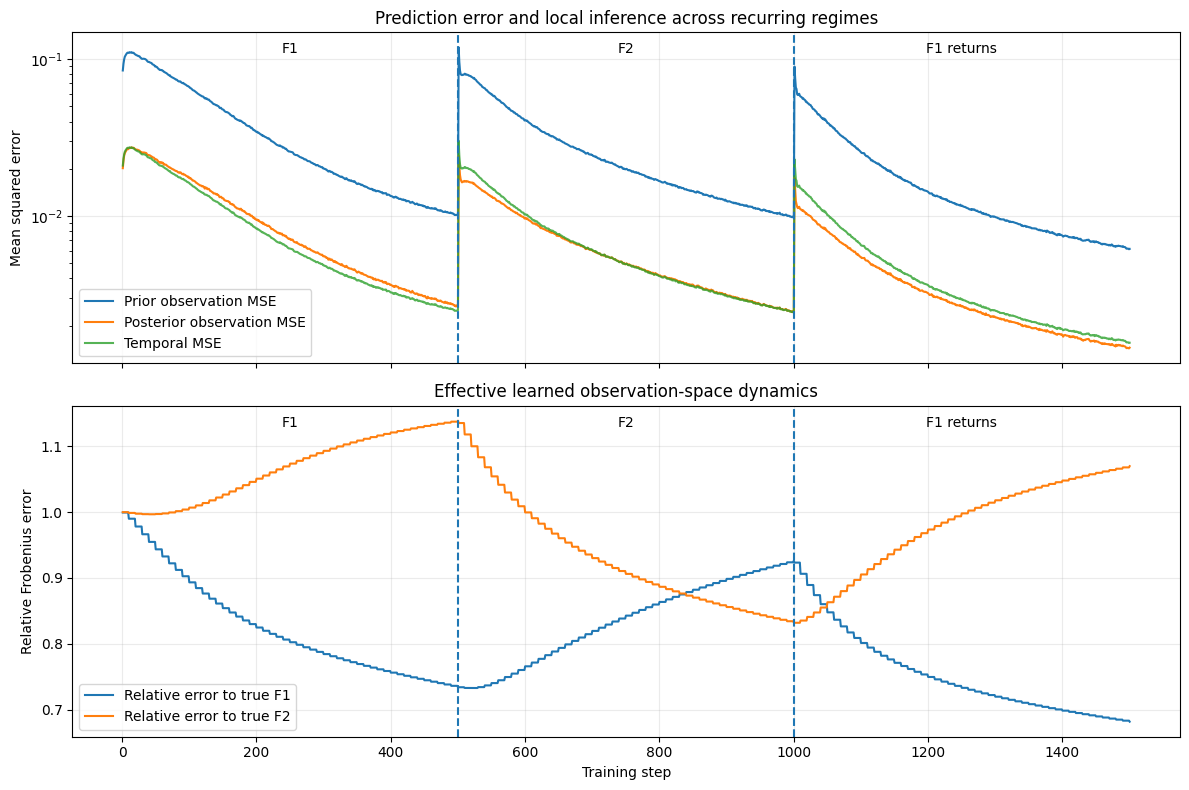

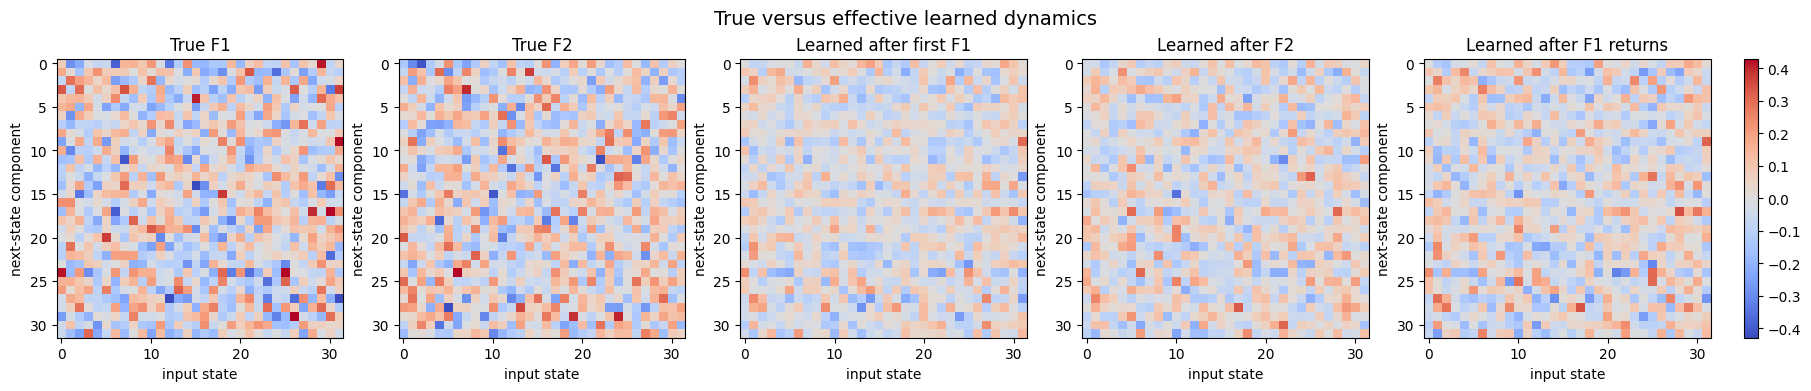

In [ ]:
# ============================================================
# NEXT CELL: recurring switching-dynamics test (F1 -> F2 -> F1)
# Assumes the previous cell defined:
#   PCConfig, PredictiveCodingWorldModel, stable_matrix, set_seed
# ============================================================

import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

_required = ["PCConfig", "PredictiveCodingWorldModel", "stable_matrix", "set_seed"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the predictive-coding architecture cell first. Missing: "
        + ", ".join(_missing)
    )


class RecurringSwitchingLinearWorld:
    """Controlled linear world with an unannounced F1 -> F2 -> F1 schedule.

    Only the transition matrix changes. The action map G and observation map C
    remain fixed, isolating whether the model can revise and recover dynamics.
    """

    def __init__(self, cfg, switch_strength=0.90):
        if cfg.obs_dim != cfg.state_dim or cfg.latent_dim != cfg.state_dim:
            raise ValueError(
                "For this diagnostic, use state_dim == latent_dim == obs_dim. "
                "This keeps dynamics comparison identifiable."
            )
        if cfg.mixed_observations:
            raise ValueError(
                "Set mixed_observations=False for this test. Representation "
                "learning should be tested only after switching dynamics works."
            )

        self.cfg = cfg
        self.device = torch.device(cfg.device)

        self.F1 = stable_matrix(cfg.state_dim, cfg.dynamics_radius, self.device)
        candidate = stable_matrix(cfg.state_dim, cfg.dynamics_radius, self.device)
        F2 = (1.0 - switch_strength) * self.F1 + switch_strength * candidate
        radius = torch.linalg.eigvals(F2).abs().max().real.clamp_min(1e-6)
        self.F2 = F2 * (cfg.dynamics_radius / radius)

        self.G = (
            torch.randn(cfg.state_dim, cfg.action_dim, device=self.device)
            * cfg.action_scale
        )
        self.C = torch.eye(cfg.state_dim, device=self.device)
        self.regime = 1
        self.x = None

    @property
    def F(self):
        return self.F1 if self.regime == 1 else self.F2

    @torch.no_grad()
    def set_regime(self, regime):
        if regime not in (1, 2):
            raise ValueError("regime must be 1 or 2")
        self.regime = regime

    @torch.no_grad()
    def reset(self, batch_size):
        self.x = 0.25 * torch.randn(
            batch_size, self.cfg.state_dim, device=self.device
        )
        return self.observe()

    @torch.no_grad()
    def observe(self):
        noise = self.cfg.observation_noise * torch.randn(
            self.x.shape[0], self.cfg.obs_dim, device=self.device
        )
        return self.x @ self.C.T + noise

    @torch.no_grad()
    def step(self, action):
        process_noise = self.cfg.process_noise * torch.randn_like(self.x)
        self.x = self.x @ self.F.T + action @ self.G.T + process_noise
        return self.observe()


def _effective_observation_dynamics(model):
    """Coordinate-aware dynamics represented by W, A, and B.

    o_t ~= W z_t and z_{t+1} ~= A z_t + B a_t imply
        o_{t+1} ~= (W A W^+) o_t + (W B) a_t.
    This remains meaningful even if the latent coordinates rotate.
    """
    W_pinv = torch.linalg.pinv(model.W)
    F_effective = model.W @ model.A @ W_pinv
    G_effective = model.W @ model.B
    return F_effective, G_effective


def _relative_frobenius(estimate, target):
    return (
        torch.linalg.matrix_norm(estimate - target)
        / torch.linalg.matrix_norm(target).clamp_min(1e-12)
    ).item()


def _first_sustained_recovery(values, start, end, threshold, window=25):
    """Steps from phase start until a whole window stays below threshold."""
    values = np.asarray(values, dtype=np.float64)
    # start/end are zero-based half-open indices.
    for index in range(start, end - window + 1):
        if np.median(values[index:index + window]) <= threshold:
            return index - start + 1
    return None


@torch.no_grad()
def run_recurring_switch_test(cfg, phase_steps=500, switch_strength=0.90, diagnostic_every=10):
    """Train the unchanged predictive-coding model on F1 -> F2 -> F1."""
    cfg = copy.deepcopy(cfg)
    cfg.train_steps = 3 * phase_steps
    cfg.shift_step = None
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.validate()

    set_seed(cfg.seed + 101)
    environment = RecurringSwitchingLinearWorld(cfg, switch_strength=switch_strength)
    model = PredictiveCodingWorldModel(cfg)

    observation = environment.reset(cfg.batch_size)
    z_previous = torch.zeros(
        cfg.batch_size, cfg.latent_dim, device=environment.device
    )
    zero_action = torch.zeros(
        cfg.batch_size, cfg.action_dim, device=environment.device
    )
    z_previous = model.infer(observation, z_previous, zero_action)["z"]

    history = {
        "step": [],
        "regime": [],
        "prior_mse": [],
        "posterior_mse": [],
        "temporal_mse": [],
        "distance_to_F1": [],
        "distance_to_F2": [],
        "delta_A_rms": [],
    }
    endpoints = {}

    progress = tqdm(
        range(1, 3 * phase_steps + 1),
        desc="F1 -> F2 -> F1",
        unit="step",
        dynamic_ncols=True,
    )

    last_F_effective, last_G_effective = _effective_observation_dynamics(model)
    last_distance_F1 = _relative_frobenius(last_F_effective, environment.F1)
    last_distance_F2 = _relative_frobenius(last_F_effective, environment.F2)

    for step in progress:
        if step == phase_steps + 1:
            environment.set_regime(2)
        elif step == 2 * phase_steps + 1:
            environment.set_regime(1)

        action = cfg.action_std * torch.randn(
            cfg.batch_size, cfg.action_dim, device=environment.device
        )
        observation = environment.step(action)

        inferred = model.infer(observation, z_previous, action)
        local_stats = model.local_update(
            z=inferred["z"],
            z_previous=z_previous,
            action=action,
            observation_error=inferred["observation_error"],
            temporal_error=inferred["temporal_error"],
        )
        z_previous = inferred["z"]

        prior_mse = (
            inferred["prior_observation_prediction"] - observation
        ).square().mean().item()
        posterior_mse = inferred["observation_error"].square().mean().item()
        temporal_mse = inferred["temporal_error"].square().mean().item()

        should_diagnose = (
            step == 1
            or step % diagnostic_every == 0
            or step in (phase_steps, phase_steps + 1, 2 * phase_steps, 2 * phase_steps + 1, 3 * phase_steps)
        )
        if should_diagnose:
            F_effective, G_effective = _effective_observation_dynamics(model)
            distance_F1 = _relative_frobenius(F_effective, environment.F1)
            distance_F2 = _relative_frobenius(F_effective, environment.F2)
            last_F_effective = F_effective
            last_G_effective = G_effective
            last_distance_F1 = distance_F1
            last_distance_F2 = distance_F2
        else:
            F_effective = last_F_effective
            G_effective = last_G_effective
            distance_F1 = last_distance_F1
            distance_F2 = last_distance_F2

        history["step"].append(step)
        history["regime"].append(environment.regime)
        history["prior_mse"].append(prior_mse)
        history["posterior_mse"].append(posterior_mse)
        history["temporal_mse"].append(temporal_mse)
        history["distance_to_F1"].append(distance_F1)
        history["distance_to_F2"].append(distance_F2)
        history["delta_A_rms"].append(local_stats["delta_A_rms"])

        if step in (phase_steps, 2 * phase_steps, 3 * phase_steps):
            endpoints[step] = {
                "F_effective": F_effective.detach().cpu().clone(),
                "G_effective": G_effective.detach().cpu().clone(),
                "A": model.A.detach().cpu().clone(),
                "B": model.B.detach().cpu().clone(),
                "W": model.W.detach().cpu().clone(),
            }

        if step == 1 or step % 25 == 0:
            progress.set_postfix(
                regime=f"F{environment.regime}",
                prior=f"{prior_mse:.2e}",
                post=f"{posterior_mse:.2e}",
                dF1=f"{distance_F1:.2f}",
                dF2=f"{distance_F2:.2f}",
            )

    return {
        "config": cfg,
        "environment": environment,
        "model": model,
        "history": history,
        "endpoints": endpoints,
        "phase_steps": phase_steps,
    }


def summarize_recurring_switch_test(test_result, recovery_window=25):
    h = test_result["history"]
    P = test_result["phase_steps"]
    prior = np.asarray(h["prior_mse"])
    posterior = np.asarray(h["posterior_mse"])

    tail = min(100, max(5, P // 5))
    recovery_window = min(recovery_window, max(3, P // 4))

    # A1 criterion is fixed from the first A1 phase and reused on return.
    a1_threshold = 1.25 * np.median(prior[P - tail:P])
    a2_threshold = 1.25 * np.median(prior[2 * P - tail:2 * P])

    initial_A1 = _first_sustained_recovery(
        prior, 0, P, a1_threshold, recovery_window
    )
    adapt_A2 = _first_sustained_recovery(
        prior, P, 2 * P, a2_threshold, recovery_window
    )
    return_A1 = _first_sustained_recovery(
        prior, 2 * P, 3 * P, a1_threshold, recovery_window
    )

    def fmt(value):
        return "not recovered" if value is None else f"{value} steps"

    print("\nRecurring switching-dynamics result")
    print("=" * 45)
    print(f"Initial learning of F1:       {fmt(initial_A1)}")
    print(f"Adaptation from F1 to F2:     {fmt(adapt_A2)}")
    print(f"Recovery when F1 returns:     {fmt(return_A1)}")
    print(f"F1 recovery threshold:        {a1_threshold:.6f}")
    print(f"F2 recovery threshold:        {a2_threshold:.6f}")

    for phase, (start, end) in {
        "F1 first exposure": (0, P),
        "F2 exposure": (P, 2 * P),
        "F1 return": (2 * P, 3 * P),
    }.items():
        phase_prior = np.median(prior[end - tail:end])
        phase_post = np.median(posterior[end - tail:end])
        correction = 1.0 - phase_post / max(phase_prior, 1e-12)
        print(
            f"{phase:18s} | final prior={phase_prior:.6f} "
            f"posterior={phase_post:.6f} "
            f"inference reduction={100 * correction:5.1f}%"
        )

    if initial_A1 is not None and return_A1 is not None:
        speedup = initial_A1 / max(return_A1, 1)
        print(f"\nReturn-to-F1 speedup:         {speedup:.2f}x")
        if speedup > 1.25:
            print(
                "Interpretation: F1 was reacquired faster, consistent with retained "
                "structure. This is not proof of a stored regime; inspect the "
                "effective-dynamics plots below."
            )
        elif speedup < 0.8:
            print(
                "Interpretation: returning to F1 was slower than initial learning, "
                "which is evidence of interference rather than reusable memory."
            )
        else:
            print(
                "Interpretation: no meaningful savings on return to F1. The model "
                "adapts online but does not clearly retain the old dynamics."
            )

    return {
        "initial_A1_steps": initial_A1,
        "adapt_A2_steps": adapt_A2,
        "return_A1_steps": return_A1,
        "A1_threshold": a1_threshold,
        "A2_threshold": a2_threshold,
    }


def plot_recurring_switch_test(test_result):
    h = test_result["history"]
    P = test_result["phase_steps"]
    steps = np.asarray(h["step"])

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(steps, h["prior_mse"], label="Prior observation MSE")
    axes[0].plot(steps, h["posterior_mse"], label="Posterior observation MSE")
    axes[0].plot(steps, h["temporal_mse"], label="Temporal MSE", alpha=0.8)
    axes[0].set_yscale("log")
    axes[0].set_ylabel("Mean squared error")
    axes[0].set_title("Prediction error and local inference across recurring regimes")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(steps, h["distance_to_F1"], label="Relative error to true F1")
    axes[1].plot(steps, h["distance_to_F2"], label="Relative error to true F2")
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Relative Frobenius error")
    axes[1].set_title("Effective learned observation-space dynamics")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    for axis in axes:
        axis.axvline(P, linestyle="--", linewidth=1.5)
        axis.axvline(2 * P, linestyle="--", linewidth=1.5)
        axis.text(P / 2, 0.97, "F1", transform=axis.get_xaxis_transform(), ha="center", va="top")
        axis.text(1.5 * P, 0.97, "F2", transform=axis.get_xaxis_transform(), ha="center", va="top")
        axis.text(2.5 * P, 0.97, "F1 returns", transform=axis.get_xaxis_transform(), ha="center", va="top")

    fig.tight_layout()
    plt.show()

    env = test_result["environment"]
    endpoints = test_result["endpoints"]
    matrices = [
        env.F1.detach().cpu().numpy(),
        env.F2.detach().cpu().numpy(),
        endpoints[P]["F_effective"].numpy(),
        endpoints[2 * P]["F_effective"].numpy(),
        endpoints[3 * P]["F_effective"].numpy(),
    ]
    titles = [
        "True F1",
        "True F2",
        "Learned after first F1",
        "Learned after F2",
        "Learned after F1 returns",
    ]
    scale = max(np.percentile(np.abs(m), 99.5) for m in matrices)

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), constrained_layout=True)
    for axis, matrix, title in zip(axes, matrices, titles):
        image = axis.imshow(
            matrix,
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
            interpolation="nearest",
            aspect="auto",
        )
        axis.set_title(title)
        axis.set_xlabel("input state")
        axis.set_ylabel("next-state component")
    fig.colorbar(image, ax=axes, fraction=0.02, pad=0.02)
    fig.suptitle("True versus effective learned dynamics", fontsize=14)
    plt.show()


# -------------------------
# Run the test
# -------------------------
switch_cfg = PCConfig(
    seed=7,
    device="cuda" if torch.cuda.is_available() else "cpu",
    state_dim=32,
    latent_dim=32,
    obs_dim=32,
    action_dim=8,
    batch_size=4096 if torch.cuda.is_available() else 256,
    inference_steps=12,
    inference_rate=0.08,
    observation_precision=1.0,
    temporal_precision=0.5,
    latent_decay=1e-4,
    lr_observation=0.003,
    lr_transition=0.08,
    lr_action=0.08,
    dynamics_radius=0.92,
    action_scale=0.12,
    action_std=0.55,
    process_noise=0.01,
    observation_noise=0.01,
    mixed_observations=False,
    use_amp=True,
    visualize=False,
    record_checkpoints=False,
)

PHASE_STEPS = 500
switch_test_result = run_recurring_switch_test(
    switch_cfg,
    phase_steps=PHASE_STEPS,
    switch_strength=0.90,
)
switch_test_summary = summarize_recurring_switch_test(switch_test_result)
plot_recurring_switch_test(switch_test_result)

5 recurring F1/F2 cycles:   0%|          | 0/15000 [00:00<?, ?step/s]


Long repeated switching-dynamics result
Schedule: F1 -> F2 -> F1 -> F2 -> F1 -> F2 -> F1 -> F2 -> F1 -> F2 | 1500 steps/regime | 9 switches
Fixed recovery thresholds: F1=0.003499, F2=0.004258
------------------------------------------------------------------------------------------------
Phase Reg Exp  Recovery  Start prior  Final prior  Final post  Infer red.   dF1    dF2
------------------------------------------------------------------------------------------------
    1  F1    1        1123     0.070633     0.002799    0.000789      71.8%   0.68   1.18
    2  F2    1        1163     0.081698     0.003406    0.000909      73.3%   1.14   0.68
    3  F1    2         867     0.055917     0.002277    0.000537      76.4%   0.74   1.07
    4  F2    2         699     0.060419     0.002272    0.000525      76.9%   1.16   0.69
    5  F1    3         786     0.052664     0.002169    0.000449      79.3%   0.78   1.07
    6  F2    3         602     0.057141     0.002062    0.000432      79.1% 

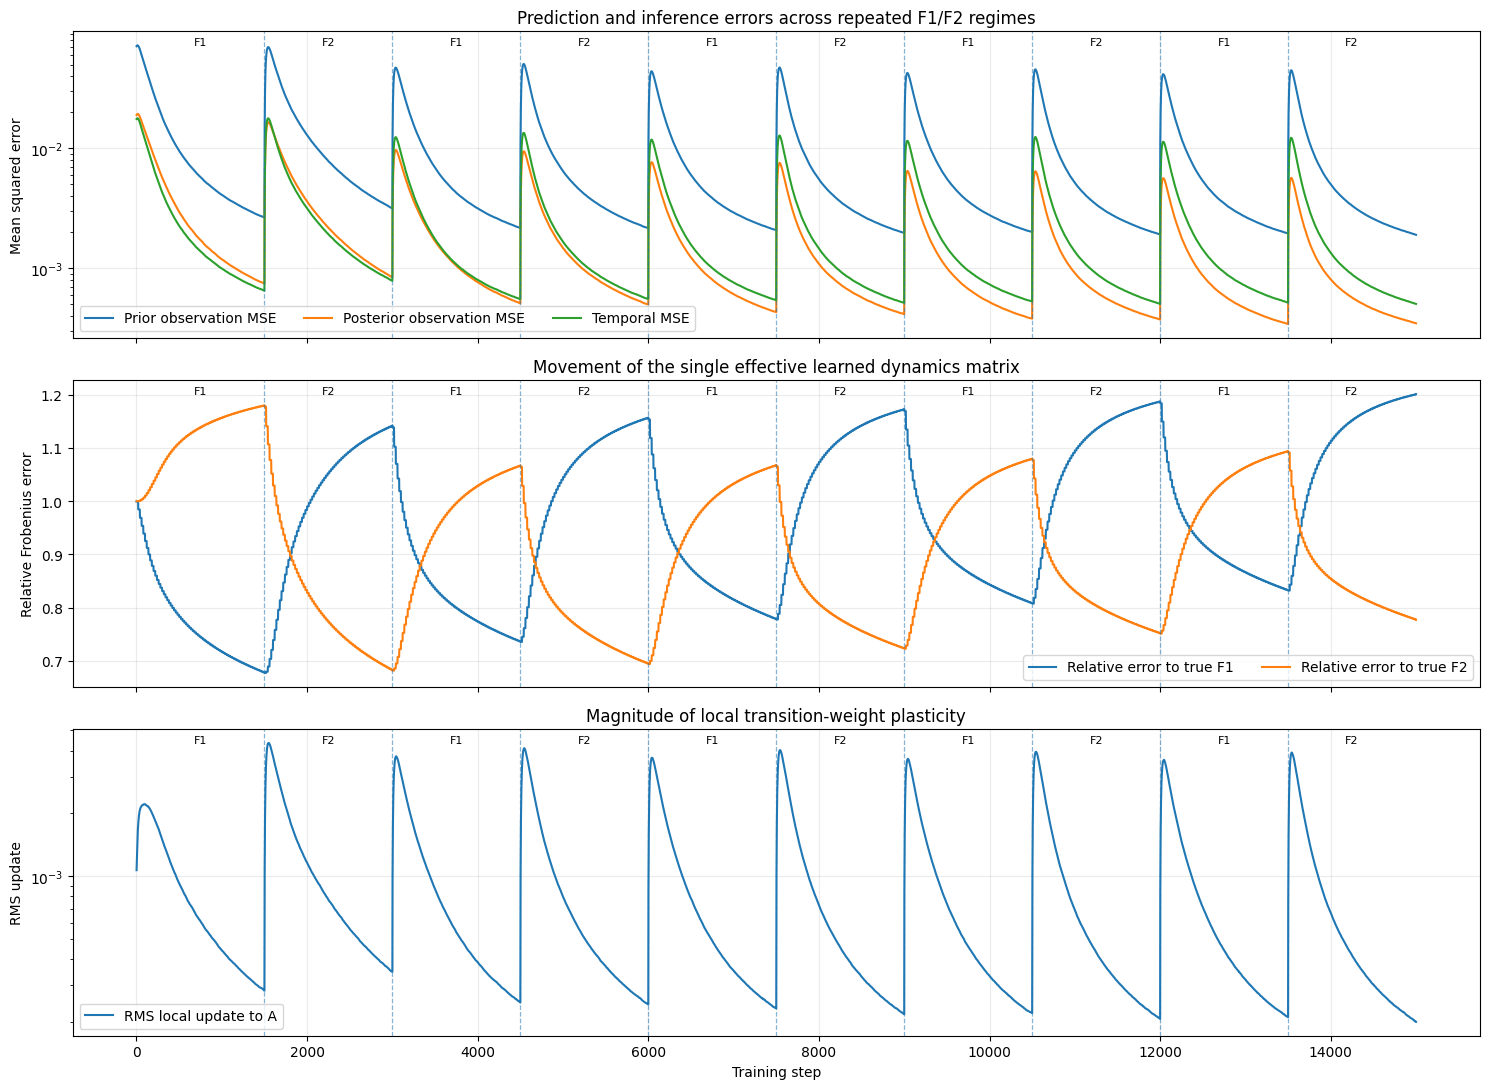

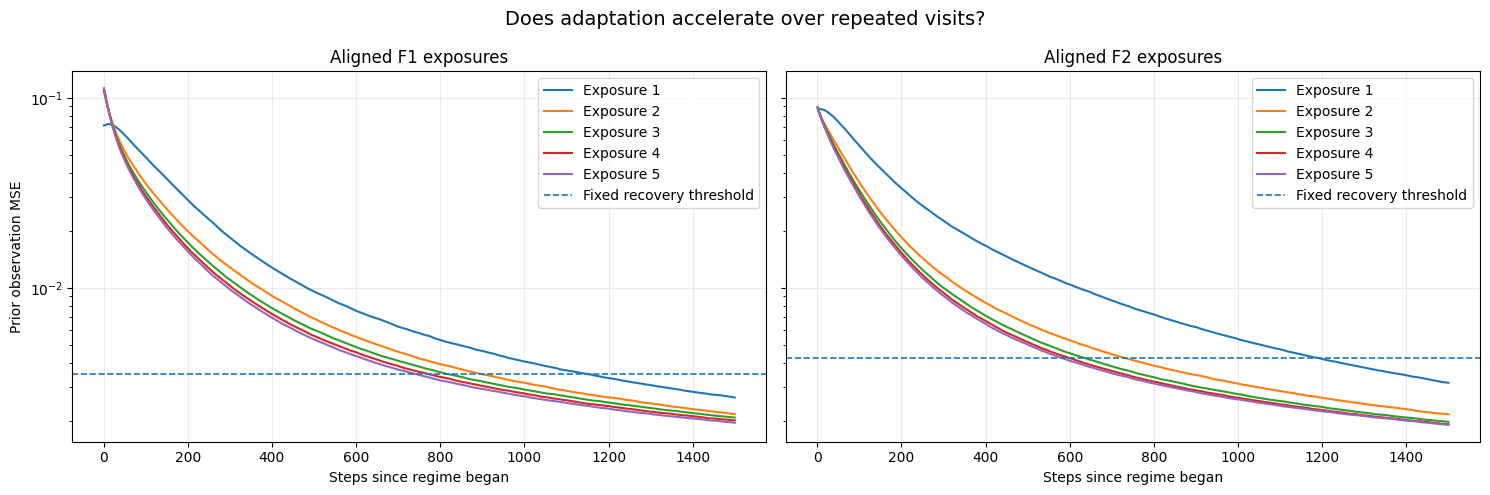

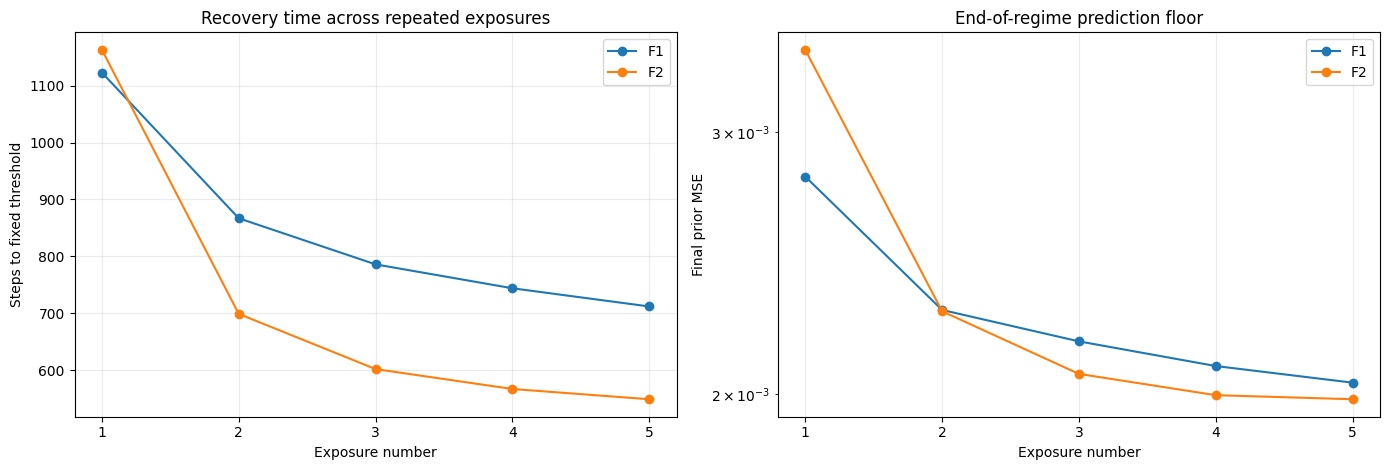

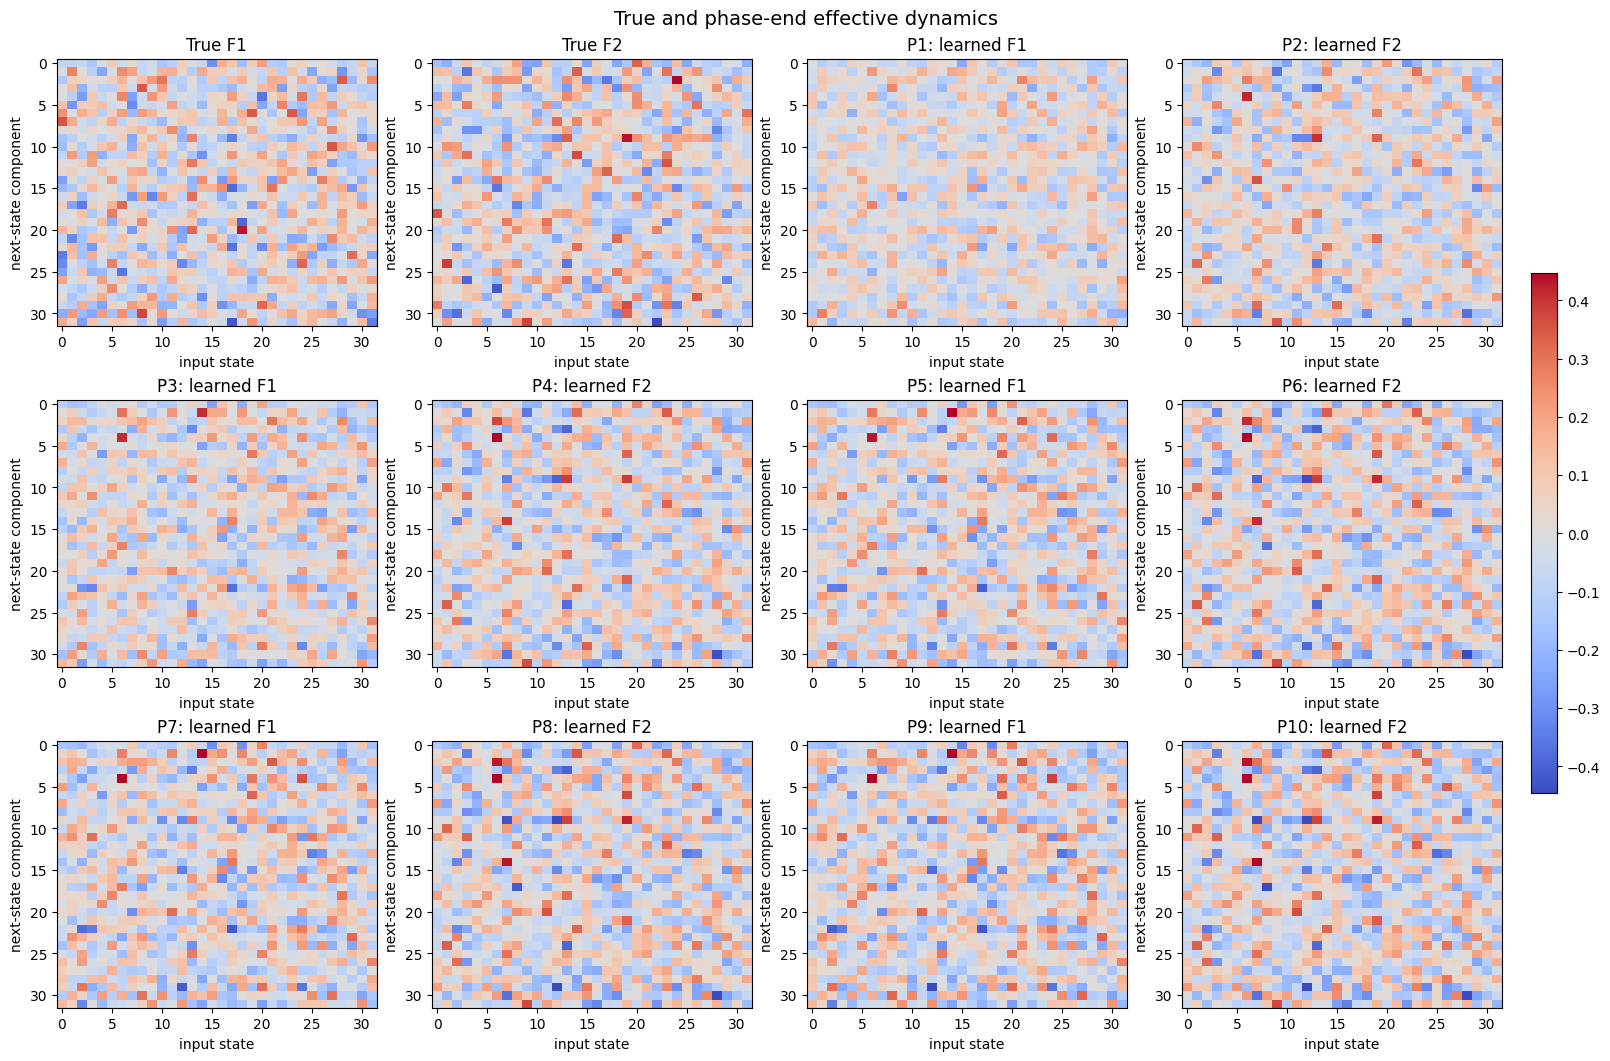

In [ ]:
# ============================================================
# NEXT CELL: long repeated switching test
# F1 -> F2 -> F1 -> F2 ... for multiple cycles
#
# Assumes the previous switching-test cell already defined:
#   switch_cfg
#   RecurringSwitchingLinearWorld
#   PredictiveCodingWorldModel
#   _effective_observation_dynamics
#   _relative_frobenius
#   _first_sustained_recovery
#   set_seed
# ============================================================

import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

_required = [
    "switch_cfg",
    "RecurringSwitchingLinearWorld",
    "PredictiveCodingWorldModel",
    "_effective_observation_dynamics",
    "_relative_frobenius",
    "_first_sustained_recovery",
    "set_seed",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the architecture cell and the first F1 -> F2 -> F1 test cell first. "
        "Missing: " + ", ".join(_missing)
    )


def _ema(values, span=35):
    """Simple exponential moving average for readable plots."""
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return values
    alpha = 2.0 / (span + 1.0)
    out = np.empty_like(values)
    out[0] = values[0]
    for i in range(1, len(values)):
        out[i] = alpha * values[i] + (1.0 - alpha) * out[i - 1]
    return out


@torch.no_grad()
def run_long_repeated_switch_test(
    cfg,
    phase_steps=1500,
    num_cycles=5,
    switch_strength=0.90,
    diagnostic_every=20,
):
    """Train a fresh unchanged predictive-coding model over repeated F1/F2 cycles.

    Default schedule:
        F1 -> F2 -> F1 -> F2 -> F1 -> F2 -> F1 -> F2 -> F1 -> F2

    Five cycles with 1,500 steps per regime gives 15,000 total updates and
    nine unannounced regime changes.
    """
    if phase_steps < 100:
        raise ValueError("phase_steps should be at least 100 for stable recovery metrics")
    if num_cycles < 2:
        raise ValueError("num_cycles should be at least 2")

    cfg = copy.deepcopy(cfg)
    schedule = tuple(regime for _ in range(num_cycles) for regime in (1, 2))
    total_steps = phase_steps * len(schedule)

    cfg.train_steps = total_steps
    cfg.shift_step = None
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.validate()

    # New seed and fresh model: this is not continuing from the three-phase run.
    set_seed(cfg.seed + 303)
    environment = RecurringSwitchingLinearWorld(
        cfg,
        switch_strength=switch_strength,
    )
    model = PredictiveCodingWorldModel(cfg)

    observation = environment.reset(cfg.batch_size)
    z_previous = torch.zeros(
        cfg.batch_size,
        cfg.latent_dim,
        device=environment.device,
    )
    zero_action = torch.zeros(
        cfg.batch_size,
        cfg.action_dim,
        device=environment.device,
    )
    z_previous = model.infer(observation, z_previous, zero_action)["z"]

    history = {
        "step": [],
        "phase": [],
        "regime": [],
        "prior_mse": [],
        "posterior_mse": [],
        "temporal_mse": [],
        "distance_to_F1": [],
        "distance_to_F2": [],
        "delta_A_rms": [],
    }
    phase_endpoints = []

    environment.set_regime(schedule[0])
    last_F_effective, last_G_effective = _effective_observation_dynamics(model)
    last_distance_F1 = _relative_frobenius(last_F_effective, environment.F1)
    last_distance_F2 = _relative_frobenius(last_F_effective, environment.F2)

    progress = tqdm(
        range(1, total_steps + 1),
        desc=f"{num_cycles} recurring F1/F2 cycles",
        unit="step",
        dynamic_ncols=True,
    )

    for step in progress:
        phase_index = (step - 1) // phase_steps
        step_in_phase = (step - 1) % phase_steps + 1
        regime = schedule[phase_index]

        if step_in_phase == 1:
            environment.set_regime(regime)

        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=environment.device,
        )
        observation = environment.step(action)

        inferred = model.infer(observation, z_previous, action)
        local_stats = model.local_update(
            z=inferred["z"],
            z_previous=z_previous,
            action=action,
            observation_error=inferred["observation_error"],
            temporal_error=inferred["temporal_error"],
        )
        z_previous = inferred["z"]

        prior_mse = (
            inferred["prior_observation_prediction"] - observation
        ).square().mean().item()
        posterior_mse = inferred["observation_error"].square().mean().item()
        temporal_mse = inferred["temporal_error"].square().mean().item()

        is_boundary = step_in_phase in (1, phase_steps)
        should_diagnose = (
            step == 1
            or step % diagnostic_every == 0
            or is_boundary
        )
        if should_diagnose:
            F_effective, G_effective = _effective_observation_dynamics(model)
            last_F_effective = F_effective
            last_G_effective = G_effective
            last_distance_F1 = _relative_frobenius(
                F_effective,
                environment.F1,
            )
            last_distance_F2 = _relative_frobenius(
                F_effective,
                environment.F2,
            )

        history["step"].append(step)
        history["phase"].append(phase_index + 1)
        history["regime"].append(regime)
        history["prior_mse"].append(prior_mse)
        history["posterior_mse"].append(posterior_mse)
        history["temporal_mse"].append(temporal_mse)
        history["distance_to_F1"].append(last_distance_F1)
        history["distance_to_F2"].append(last_distance_F2)
        history["delta_A_rms"].append(local_stats["delta_A_rms"])

        if step_in_phase == phase_steps:
            phase_endpoints.append(
                {
                    "phase": phase_index + 1,
                    "regime": regime,
                    "step": step,
                    "F_effective": last_F_effective.detach().cpu().clone(),
                    "G_effective": last_G_effective.detach().cpu().clone(),
                    "A": model.A.detach().cpu().clone(),
                    "B": model.B.detach().cpu().clone(),
                    "W": model.W.detach().cpu().clone(),
                }
            )

        if step == 1 or step % 50 == 0 or is_boundary:
            progress.set_postfix(
                phase=f"{phase_index + 1}/{len(schedule)}",
                regime=f"F{regime}",
                prior=f"{prior_mse:.2e}",
                post=f"{posterior_mse:.2e}",
                dF1=f"{last_distance_F1:.2f}",
                dF2=f"{last_distance_F2:.2f}",
            )

    return {
        "config": cfg,
        "environment": environment,
        "model": model,
        "history": history,
        "phase_endpoints": phase_endpoints,
        "phase_steps": phase_steps,
        "schedule": schedule,
        "num_cycles": num_cycles,
        "switch_strength": switch_strength,
    }


def summarize_long_repeated_switch_test(
    result,
    recovery_window=35,
    threshold_multiplier=1.25,
):
    """Measure learning/relearning with fixed regime-specific thresholds.

    F1 threshold is derived from the tail of the first F1 exposure and then
    reused for every later F1 exposure. F2 is treated the same way. This makes
    recovery times directly comparable across repeated visits.
    """
    h = result["history"]
    P = result["phase_steps"]
    schedule = result["schedule"]
    prior = np.asarray(h["prior_mse"], dtype=np.float64)
    posterior = np.asarray(h["posterior_mse"], dtype=np.float64)

    tail = min(200, max(20, P // 5))
    recovery_window = min(recovery_window, max(5, P // 4))

    first_phase_for_regime = {
        regime: schedule.index(regime)
        for regime in (1, 2)
    }
    thresholds = {}
    for regime, phase_index in first_phase_for_regime.items():
        start = phase_index * P
        end = start + P
        thresholds[regime] = threshold_multiplier * np.median(
            prior[end - tail:end]
        )

    rows = []
    exposure_count = {1: 0, 2: 0}
    for phase_index, regime in enumerate(schedule):
        exposure_count[regime] += 1
        start = phase_index * P
        end = start + P
        recovery = _first_sustained_recovery(
            prior,
            start,
            end,
            thresholds[regime],
            recovery_window,
        )

        start_window = min(35, P)
        start_prior = np.median(prior[start:start + start_window])
        final_prior = np.median(prior[end - tail:end])
        final_post = np.median(posterior[end - tail:end])
        inference_reduction = 1.0 - final_post / max(final_prior, 1e-12)
        endpoint = result["phase_endpoints"][phase_index]

        rows.append(
            {
                "phase": phase_index + 1,
                "regime": regime,
                "exposure": exposure_count[regime],
                "recovery_steps": recovery,
                "start_prior": start_prior,
                "final_prior": final_prior,
                "final_posterior": final_post,
                "inference_reduction": inference_reduction,
                "distance_to_F1": _relative_frobenius(
                    endpoint["F_effective"],
                    result["environment"].F1.detach().cpu(),
                ),
                "distance_to_F2": _relative_frobenius(
                    endpoint["F_effective"],
                    result["environment"].F2.detach().cpu(),
                ),
            }
        )

    print("\nLong repeated switching-dynamics result")
    print("=" * 96)
    print(
        f"Schedule: {' -> '.join(f'F{r}' for r in schedule)} | "
        f"{P} steps/regime | {len(schedule) - 1} switches"
    )
    print(
        f"Fixed recovery thresholds: F1={thresholds[1]:.6f}, "
        f"F2={thresholds[2]:.6f}"
    )
    print("-" * 96)
    print(
        "Phase Reg Exp  Recovery  Start prior  Final prior  Final post  "
        "Infer red.   dF1    dF2"
    )
    print("-" * 96)

    for row in rows:
        recovery_text = (
            "not reached"
            if row["recovery_steps"] is None
            else str(row["recovery_steps"])
        )
        print(
            f"{row['phase']:>5d}  F{row['regime']}  "
            f"{row['exposure']:>3d}  {recovery_text:>10s}  "
            f"{row['start_prior']:>11.6f}  "
            f"{row['final_prior']:>11.6f}  "
            f"{row['final_posterior']:>10.6f}  "
            f"{100 * row['inference_reduction']:>8.1f}%  "
            f"{row['distance_to_F1']:>5.2f}  "
            f"{row['distance_to_F2']:>5.2f}"
        )

    print("-" * 96)
    for regime in (1, 2):
        regime_rows = [r for r in rows if r["regime"] == regime]
        valid = [r for r in regime_rows if r["recovery_steps"] is not None]
        if len(valid) >= 2:
            first = valid[0]["recovery_steps"]
            last = valid[-1]["recovery_steps"]
            speedup = first / max(last, 1)
            print(
                f"F{regime}: first recovery={first} steps, "
                f"latest recovery={last} steps, speedup={speedup:.2f}x"
            )
        else:
            print(f"F{regime}: insufficient successful recoveries for a speedup estimate")

    return {
        "thresholds": thresholds,
        "rows": rows,
        "recovery_window": recovery_window,
        "tail": tail,
    }


def _draw_phase_boundaries(axis, schedule, phase_steps):
    total_phases = len(schedule)
    for phase_index in range(1, total_phases):
        axis.axvline(phase_index * phase_steps, linestyle="--", linewidth=0.9, alpha=0.55)
    for phase_index, regime in enumerate(schedule):
        center = (phase_index + 0.5) * phase_steps
        axis.text(
            center,
            0.98,
            f"F{regime}",
            transform=axis.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
        )


def plot_long_repeated_switch_test(result, summary, smoothing_span=35):
    """Generate four static Colab-safe figures."""
    h = result["history"]
    P = result["phase_steps"]
    schedule = result["schedule"]
    steps = np.asarray(h["step"])

    # --------------------------------------------------------
    # Figure 1: complete training trajectory
    # --------------------------------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

    axes[0].plot(steps, _ema(h["prior_mse"], smoothing_span), label="Prior observation MSE")
    axes[0].plot(steps, _ema(h["posterior_mse"], smoothing_span), label="Posterior observation MSE")
    axes[0].plot(steps, _ema(h["temporal_mse"], smoothing_span), label="Temporal MSE")
    axes[0].set_yscale("log")
    axes[0].set_ylabel("Mean squared error")
    axes[0].set_title("Prediction and inference errors across repeated F1/F2 regimes")
    axes[0].legend(ncol=3)
    axes[0].grid(alpha=0.25)

    axes[1].plot(steps, h["distance_to_F1"], label="Relative error to true F1")
    axes[1].plot(steps, h["distance_to_F2"], label="Relative error to true F2")
    axes[1].set_ylabel("Relative Frobenius error")
    axes[1].set_title("Movement of the single effective learned dynamics matrix")
    axes[1].legend(ncol=2)
    axes[1].grid(alpha=0.25)

    axes[2].plot(steps, _ema(h["delta_A_rms"], smoothing_span), label="RMS local update to A")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Training step")
    axes[2].set_ylabel("RMS update")
    axes[2].set_title("Magnitude of local transition-weight plasticity")
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    for axis in axes:
        _draw_phase_boundaries(axis, schedule, P)

    fig.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Figure 2: aligned within-regime learning curves
    # --------------------------------------------------------
    prior = np.asarray(h["prior_mse"], dtype=np.float64)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    exposure_count = {1: 0, 2: 0}

    for phase_index, regime in enumerate(schedule):
        exposure_count[regime] += 1
        start = phase_index * P
        end = start + P
        curve = _ema(prior[start:end], smoothing_span)
        axes[regime - 1].plot(
            np.arange(1, P + 1),
            curve,
            label=f"Exposure {exposure_count[regime]}",
        )

    for regime, axis in ((1, axes[0]), (2, axes[1])):
        axis.axhline(
            summary["thresholds"][regime],
            linestyle="--",
            linewidth=1.2,
            label="Fixed recovery threshold",
        )
        axis.set_yscale("log")
        axis.set_xlabel("Steps since regime began")
        axis.set_title(f"Aligned F{regime} exposures")
        axis.grid(alpha=0.25)
        axis.legend()
    axes[0].set_ylabel("Prior observation MSE")
    fig.suptitle("Does adaptation accelerate over repeated visits?", fontsize=14)
    fig.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Figure 3: recovery time and final error by exposure
    # --------------------------------------------------------
    rows = summary["rows"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    for regime in (1, 2):
        regime_rows = [row for row in rows if row["regime"] == regime]
        exposures = [row["exposure"] for row in regime_rows]
        recoveries = [
            np.nan if row["recovery_steps"] is None else row["recovery_steps"]
            for row in regime_rows
        ]
        final_errors = [row["final_prior"] for row in regime_rows]
        axes[0].plot(exposures, recoveries, marker="o", label=f"F{regime}")
        axes[1].plot(exposures, final_errors, marker="o", label=f"F{regime}")

    axes[0].set_xlabel("Exposure number")
    axes[0].set_ylabel("Steps to fixed threshold")
    axes[0].set_title("Recovery time across repeated exposures")
    axes[0].set_xticks(range(1, result["num_cycles"] + 1))
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].set_xlabel("Exposure number")
    axes[1].set_ylabel("Final prior MSE")
    axes[1].set_yscale("log")
    axes[1].set_title("End-of-regime prediction floor")
    axes[1].set_xticks(range(1, result["num_cycles"] + 1))
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Figure 4: true matrices and learned endpoint matrices
    # --------------------------------------------------------
    env = result["environment"]
    matrices = [
        env.F1.detach().cpu().numpy(),
        env.F2.detach().cpu().numpy(),
    ] + [endpoint["F_effective"].numpy() for endpoint in result["phase_endpoints"]]
    titles = ["True F1", "True F2"] + [
        f"P{endpoint['phase']}: learned F{endpoint['regime']}"
        for endpoint in result["phase_endpoints"]
    ]

    columns = 4
    rows_count = math.ceil(len(matrices) / columns)
    scale = max(np.percentile(np.abs(matrix), 99.5) for matrix in matrices)
    fig, axes = plt.subplots(
        rows_count,
        columns,
        figsize=(4.0 * columns, 3.5 * rows_count),
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(-1)

    image = None
    for axis, matrix, title in zip(axes, matrices, titles):
        image = axis.imshow(
            matrix,
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
            interpolation="nearest",
            aspect="auto",
        )
        axis.set_title(title)
        axis.set_xlabel("input state")
        axis.set_ylabel("next-state component")

    for axis in axes[len(matrices):]:
        axis.axis("off")

    if image is not None:
        fig.colorbar(image, ax=axes[:len(matrices)].tolist(), fraction=0.018, pad=0.02)
    fig.suptitle("True and phase-end effective dynamics", fontsize=14)
    plt.show()


# -------------------------
# Run the longer repeated test
# -------------------------
long_switch_cfg = copy.deepcopy(switch_cfg)
long_switch_cfg.seed = switch_cfg.seed + 1

PHASE_STEPS_LONG = 1500   # 3x longer than the first 500-step test
NUM_CYCLES = 5            # F1/F2 repeated five times: 10 phases, 9 switches

long_switch_result = run_long_repeated_switch_test(
    long_switch_cfg,
    phase_steps=PHASE_STEPS_LONG,
    num_cycles=NUM_CYCLES,
    switch_strength=0.90,
    diagnostic_every=20,
)
long_switch_summary = summarize_long_repeated_switch_test(long_switch_result)
plot_long_repeated_switch_test(long_switch_result, long_switch_summary)

shared-checkpoint branch ablation:   0%|          | 0/9000 [00:00<?, ?step/s]


Shared-checkpoint branch ablation
All branches started from the same post-F1/F2 checkpoint and saw the identical training stream.
------------------------------------------------------------------------------------------------------------
Branch          Phase Reg Exp       E0       E_inf       tau      fit R²
------------------------------------------------------------------------------------------------------------
Full                1  F1    1    0.05647    0.002856     181.5     0.9854
Full                2  F2    1    0.07776    0.003591     121.0     0.9914
Full                3  F1    2    0.08093    0.003732     102.5     0.9679
Full                4  F2    2    0.07706    0.003285     108.7     0.9900
Full                5  F1    3    0.08237    0.003660      94.0     0.9647
Full                6  F2    3    0.07595    0.003174     104.7     0.9895
A-only              1  F1    1    0.05643    0.002984     184.2     0.9854
A-only              2  F2    1    0.07715    0.003783

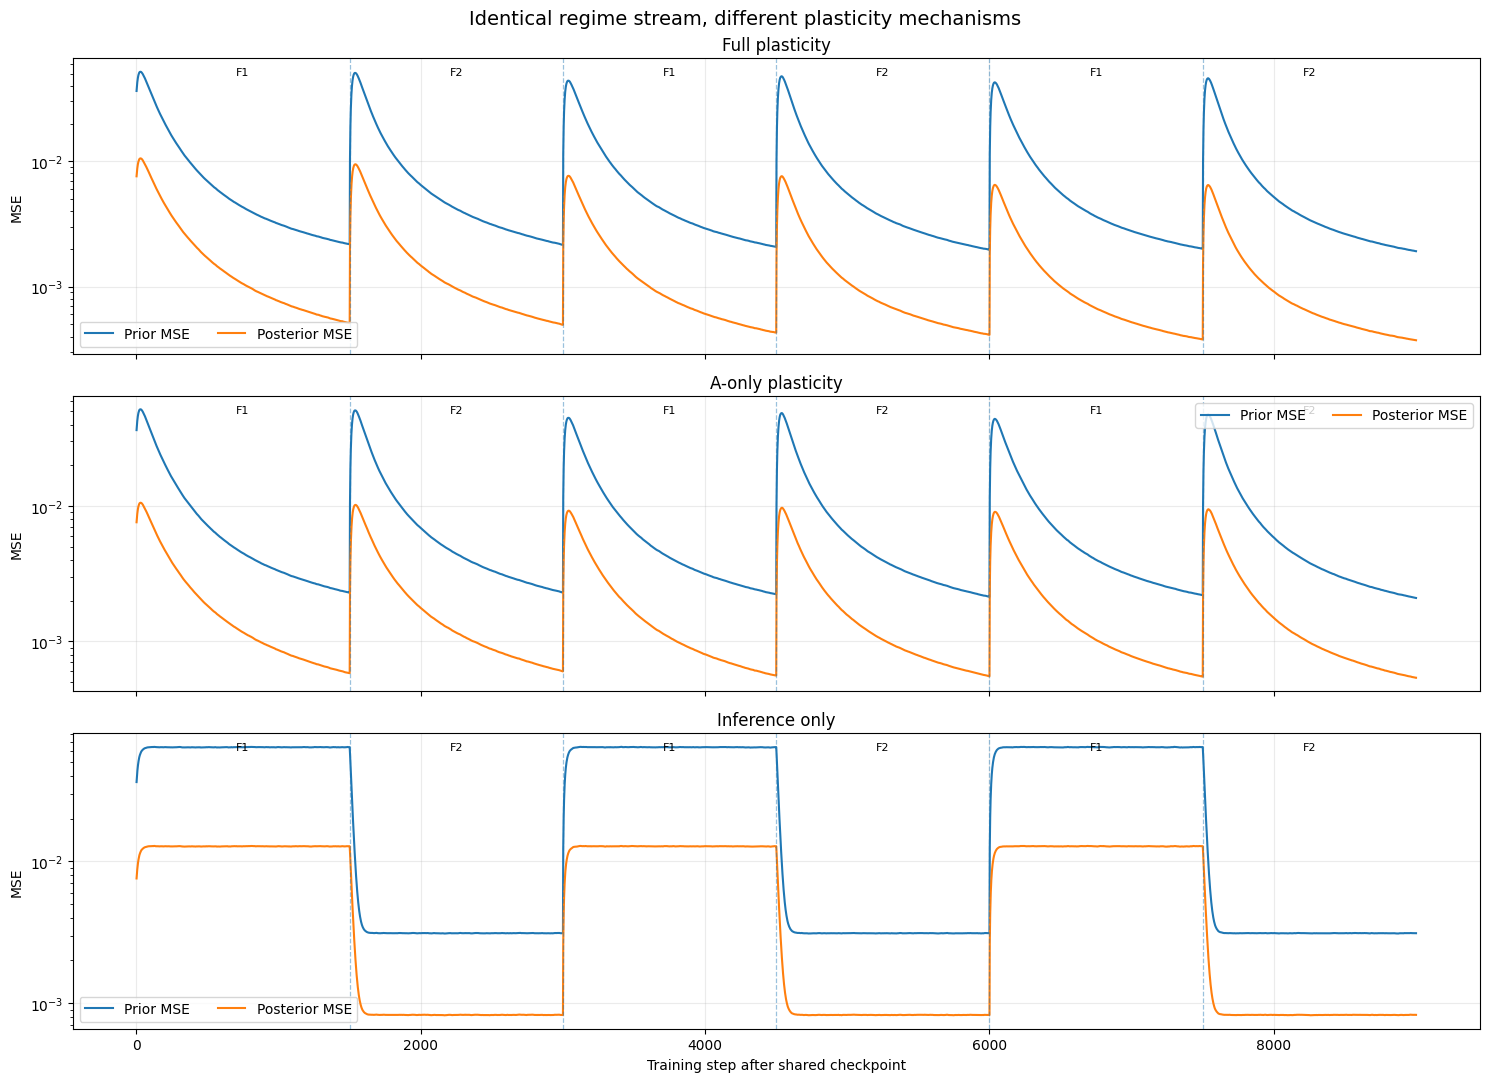

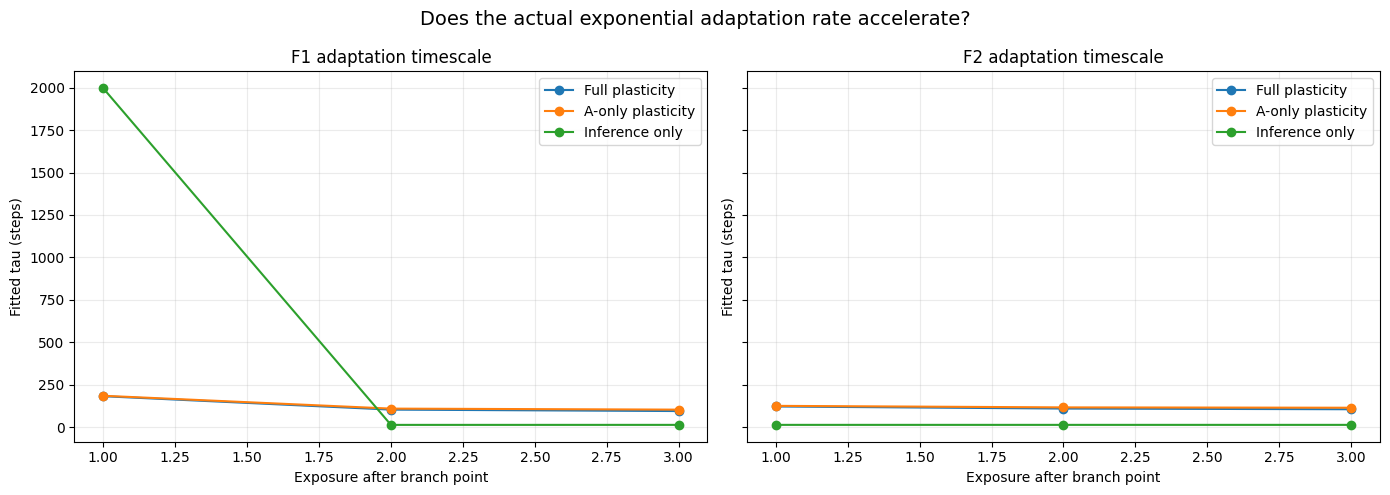

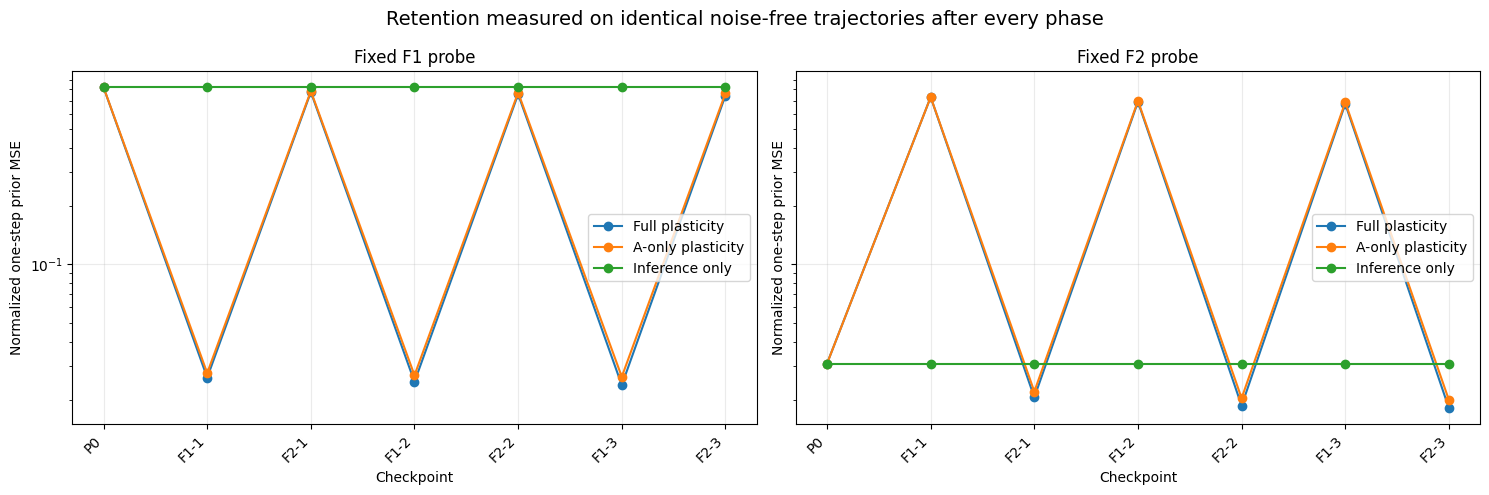

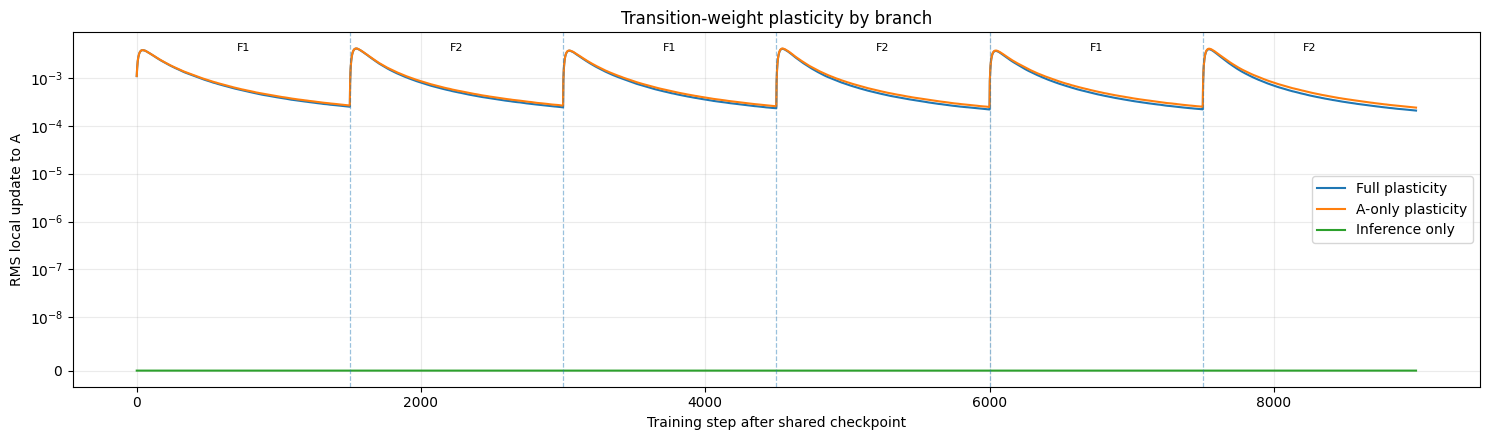

In [ ]:
# ============================================================
# NEXT CELL: where does repeated-regime speedup come from?
#
# Branches from the SAME checkpoint after the first F1 -> F2 cycle:
#   1) full_plasticity : update W, A, B
#   2) A_only          : update only transition matrix A
#   3) inference_only  : freeze all weights; update latent state only
#
# Every branch receives the exact same actions and observations.
# At the initial checkpoint and every phase endpoint, all branches are
# evaluated on the same deterministic F1 and F2 probe trajectories.
#
# Assumes the V6 cells already defined and ran:
#   long_switch_result
#   PredictiveCodingWorldModel
#   _effective_observation_dynamics
#   _relative_frobenius
#   set_seed
# ============================================================

import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

try:
    from scipy.optimize import curve_fit
except ImportError as exc:
    raise RuntimeError("SciPy is required for exponential timescale fitting.") from exc

_REQUIRED = [
    "long_switch_result",
    "PredictiveCodingWorldModel",
    "_effective_observation_dynamics",
    "_relative_frobenius",
    "set_seed",
]
_missing = [name for name in _REQUIRED if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the V6 architecture and repeated-switch cells first. Missing: "
        + ", ".join(_missing)
    )


def _ema_branch(values, span=35):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return values
    alpha = 2.0 / (span + 1.0)
    out = np.empty_like(values)
    out[0] = values[0]
    for i in range(1, len(values)):
        out[i] = alpha * values[i] + (1.0 - alpha) * out[i - 1]
    return out


def _clone_model_from_endpoint(cfg, endpoint):
    model = PredictiveCodingWorldModel(copy.deepcopy(cfg))
    with torch.no_grad():
        model.A.copy_(endpoint["A"].to(model.device))
        model.B.copy_(endpoint["B"].to(model.device))
        model.W.copy_(endpoint["W"].to(model.device))
    return model


@torch.no_grad()
def _A_only_local_update(model, z, z_previous, action, temporal_error):
    """Exact A component of the original local predictive-coding rule."""
    cfg = model.cfg
    inv_batch = 1.0 / z.shape[0]
    delta_A = (
        cfg.temporal_precision
        * (temporal_error.T @ z_previous)
        * inv_batch
    )
    model.A.add_(cfg.lr_transition * delta_A)

    # Apply the same synapse-local regularizers, but only to plastic A.
    if cfg.weight_decay:
        model.A.mul_(1.0 - cfg.weight_decay)
    if cfg.weight_clip:
        model.A.clamp_(-cfg.weight_clip, cfg.weight_clip)

    return delta_A.square().mean().sqrt().item()


@torch.no_grad()
def _make_fixed_probe(F, G, cfg, *, length=200, batch_size=256, seed=9901):
    """Noise-free, persistently excited trajectory shared by every branch."""
    device = F.device
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    x = 0.25 * torch.randn(
        batch_size,
        cfg.state_dim,
        generator=generator,
        device=device,
    )
    observations = [x.clone()]
    actions = []

    for _ in range(length):
        action = cfg.action_std * torch.randn(
            batch_size,
            cfg.action_dim,
            generator=generator,
            device=device,
        )
        x = x @ F.T + action @ G.T
        actions.append(action)
        observations.append(x.clone())

    return {
        "observations": observations,
        "actions": actions,
    }


@torch.no_grad()
def _evaluate_fixed_probe(model, probe):
    """One-step prior prediction on a fixed trajectory, without learning."""
    observations = probe["observations"]
    actions = probe["actions"]
    batch_size = observations[0].shape[0]

    zero_z = torch.zeros(
        batch_size,
        model.cfg.latent_dim,
        device=model.device,
    )
    zero_action = torch.zeros(
        batch_size,
        model.cfg.action_dim,
        device=model.device,
    )
    z_previous = model.infer(observations[0], zero_z, zero_action)["z"]

    squared_error = 0.0
    target_energy = 0.0
    for action, observation in zip(actions, observations[1:]):
        inferred = model.infer(observation, z_previous, action)
        error = inferred["prior_observation_prediction"] - observation
        squared_error += error.square().sum().item()
        target_energy += observation.square().sum().item()
        z_previous = inferred["z"]

    element_count = len(actions) * observations[0].numel()
    mse = squared_error / max(element_count, 1)
    normalized_mse = squared_error / max(target_energy, 1e-12)
    return {
        "mse": mse,
        "normalized_mse": normalized_mse,
    }


def _exp_curve(step, floor, amplitude, tau):
    return floor + amplitude * np.exp(-step / tau)


def _fit_adaptation_timescale(curve, smoothing_span=25):
    """Fit E(s)=E_inf + amplitude*exp(-s/tau) to one regime exposure."""
    y = _ema_branch(curve, smoothing_span)
    x = np.arange(len(y), dtype=np.float64)

    if len(y) < 20 or not np.all(np.isfinite(y)):
        return {"E0": np.nan, "E_inf": np.nan, "tau": np.nan, "r2": np.nan}

    tail = max(10, len(y) // 8)
    floor0 = max(float(np.median(y[-tail:])), 1e-12)
    amplitude0 = max(float(y[0] - floor0), 1e-12)
    tau0 = max(10.0, len(y) / 3.0)

    try:
        params, _ = curve_fit(
            _exp_curve,
            x,
            y,
            p0=(floor0, amplitude0, tau0),
            bounds=(
                (0.0, 0.0, 1.0),
                (max(float(y.max()) * 2.0, 1e-8),
                 max(float(y.max()) * 4.0, 1e-8),
                 len(y) * 20.0),
            ),
            maxfev=20000,
        )
        floor, amplitude, tau = [float(value) for value in params]
        prediction = _exp_curve(x, floor, amplitude, tau)
        residual = np.sum((y - prediction) ** 2)
        total = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - residual / max(total, 1e-12)
        return {
            "E0": floor + amplitude,
            "E_inf": floor,
            "tau": tau,
            "r2": float(r2),
        }
    except Exception:
        return {"E0": float(y[0]), "E_inf": floor0, "tau": np.nan, "r2": np.nan}


@torch.no_grad()
def run_branch_ablation_from_shared_checkpoint(
    source_result,
    *,
    phase_steps=1500,
    num_cycles=3,
    probe_length=200,
    probe_batch_size=256,
    smoothing_span=25,
):
    """Run full/A-only/frozen branches on an identical recurring data stream."""
    if len(source_result["phase_endpoints"]) < 2:
        raise ValueError("source_result must contain the first F1 and F2 endpoints")
    if phase_steps < 100:
        raise ValueError("phase_steps must be at least 100")
    if num_cycles < 1:
        raise ValueError("num_cycles must be at least 1")

    cfg = copy.deepcopy(source_result["config"])
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.shift_step = None
    cfg.validate()

    # Exact common checkpoint: end of phase 2, after first F1 -> F2 cycle.
    checkpoint = source_result["phase_endpoints"][1]
    branch_names = ("full_plasticity", "A_only", "inference_only")
    models = {
        name: _clone_model_from_endpoint(cfg, checkpoint)
        for name in branch_names
    }

    source_env = source_result["environment"]
    device = torch.device(cfg.device)
    F1 = source_env.F1.detach().to(device).clone()
    F2 = source_env.F2.detach().to(device).clone()
    G = source_env.G.detach().to(device).clone()

    probes = {
        1: _make_fixed_probe(
            F1,
            G,
            cfg,
            length=probe_length,
            batch_size=probe_batch_size,
            seed=9901,
        ),
        2: _make_fixed_probe(
            F2,
            G,
            cfg,
            length=probe_length,
            batch_size=probe_batch_size,
            seed=9902,
        ),
    }

    schedule = tuple(regime for _ in range(num_cycles) for regime in (1, 2))
    total_steps = phase_steps * len(schedule)

    # Shared environment state and shared randomness for all branches.
    set_seed(cfg.seed + 707)
    x = 0.25 * torch.randn(cfg.batch_size, cfg.state_dim, device=device)
    observation = x + cfg.observation_noise * torch.randn_like(x)
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)

    z_previous = {
        name: model.infer(observation, zero_z, zero_action)["z"]
        for name, model in models.items()
    }

    history = {
        name: {
            "prior_mse": [],
            "posterior_mse": [],
            "temporal_mse": [],
            "delta_A_rms": [],
        }
        for name in branch_names
    }

    probe_history = []

    def record_probes(label, phase, active_regime):
        for branch_name, model in models.items():
            for probe_regime in (1, 2):
                metric = _evaluate_fixed_probe(model, probes[probe_regime])
                F_effective, _ = _effective_observation_dynamics(model)
                probe_history.append(
                    {
                        "label": label,
                        "phase": phase,
                        "active_regime": active_regime,
                        "branch": branch_name,
                        "probe_regime": probe_regime,
                        "mse": metric["mse"],
                        "normalized_mse": metric["normalized_mse"],
                        "distance_to_F1": _relative_frobenius(F_effective, F1),
                        "distance_to_F2": _relative_frobenius(F_effective, F2),
                    }
                )

    record_probes("P0", phase=0, active_regime=2)

    progress = tqdm(
        range(total_steps),
        desc="shared-checkpoint branch ablation",
        unit="step",
        dynamic_ncols=True,
    )

    for global_index in progress:
        phase_index = global_index // phase_steps
        step_in_phase = global_index % phase_steps
        regime = schedule[phase_index]
        F = F1 if regime == 1 else F2

        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
        )
        process_noise = cfg.process_noise * torch.randn_like(x)
        x = x @ F.T + action @ G.T + process_noise
        observation = x + cfg.observation_noise * torch.randn_like(x)

        latest_prior = {}
        for branch_name, model in models.items():
            inferred = model.infer(
                observation,
                z_previous[branch_name],
                action,
            )

            if branch_name == "full_plasticity":
                local_stats = model.local_update(
                    z=inferred["z"],
                    z_previous=z_previous[branch_name],
                    action=action,
                    observation_error=inferred["observation_error"],
                    temporal_error=inferred["temporal_error"],
                )
                delta_A_rms = local_stats["delta_A_rms"]
            elif branch_name == "A_only":
                delta_A_rms = _A_only_local_update(
                    model,
                    inferred["z"],
                    z_previous[branch_name],
                    action,
                    inferred["temporal_error"],
                )
            else:
                delta_A_rms = 0.0

            z_previous[branch_name] = inferred["z"]

            prior_mse = (
                inferred["prior_observation_prediction"] - observation
            ).square().mean().item()
            posterior_mse = inferred["observation_error"].square().mean().item()
            temporal_mse = inferred["temporal_error"].square().mean().item()

            history[branch_name]["prior_mse"].append(prior_mse)
            history[branch_name]["posterior_mse"].append(posterior_mse)
            history[branch_name]["temporal_mse"].append(temporal_mse)
            history[branch_name]["delta_A_rms"].append(delta_A_rms)
            latest_prior[branch_name] = prior_mse

        if step_in_phase == phase_steps - 1:
            exposure = phase_index // 2 + 1
            record_probes(
                f"F{regime}-{exposure}",
                phase=phase_index + 1,
                active_regime=regime,
            )

        if global_index == 0 or (global_index + 1) % 100 == 0:
            progress.set_postfix(
                phase=f"{phase_index + 1}/{len(schedule)}",
                regime=f"F{regime}",
                full=f"{latest_prior['full_plasticity']:.2e}",
                Aonly=f"{latest_prior['A_only']:.2e}",
                frozen=f"{latest_prior['inference_only']:.2e}",
            )

    fits = []
    for branch_name in branch_names:
        curve = np.asarray(history[branch_name]["prior_mse"], dtype=np.float64)
        exposure_count = {1: 0, 2: 0}
        for phase_index, regime in enumerate(schedule):
            exposure_count[regime] += 1
            start = phase_index * phase_steps
            end = start + phase_steps
            fit = _fit_adaptation_timescale(
                curve[start:end],
                smoothing_span=smoothing_span,
            )
            fits.append(
                {
                    "branch": branch_name,
                    "phase": phase_index + 1,
                    "regime": regime,
                    "exposure": exposure_count[regime],
                    **fit,
                }
            )

    return {
        "config": cfg,
        "models": models,
        "history": history,
        "probe_history": probe_history,
        "fits": fits,
        "schedule": schedule,
        "phase_steps": phase_steps,
        "F1": F1.detach().cpu(),
        "F2": F2.detach().cpu(),
        "G": G.detach().cpu(),
        "checkpoint": checkpoint,
    }


def summarize_branch_ablation(result):
    branch_order = ("full_plasticity", "A_only", "inference_only")
    label_map = {
        "full_plasticity": "Full",
        "A_only": "A-only",
        "inference_only": "Inference-only",
    }

    print("\nShared-checkpoint branch ablation")
    print("=" * 108)
    print(
        "All branches started from the same post-F1/F2 checkpoint and saw "
        "the identical training stream."
    )
    print("-" * 108)
    print("Branch          Phase Reg Exp       E0       E_inf       tau      fit R²")
    print("-" * 108)
    for row in result["fits"]:
        print(
            f"{label_map[row['branch']]:<15s} "
            f"{row['phase']:>5d}  F{row['regime']}  {row['exposure']:>3d}  "
            f"{row['E0']:>9.5f}  {row['E_inf']:>10.6f}  "
            f"{row['tau']:>8.1f}  {row['r2']:>9.4f}"
        )

    print("\nFinal fixed-probe normalized MSE")
    print("-" * 72)
    final_label = result["probe_history"][-1]["label"]
    final_rows = [
        row for row in result["probe_history"]
        if row["label"] == final_label
    ]
    print("Branch              F1 probe        F2 probe")
    print("-" * 72)
    for branch in branch_order:
        by_regime = {
            row["probe_regime"]: row["normalized_mse"]
            for row in final_rows
            if row["branch"] == branch
        }
        print(
            f"{label_map[branch]:<18s} "
            f"{by_regime[1]:>12.6f}  {by_regime[2]:>12.6f}"
        )


def _draw_branch_phase_boundaries(axis, schedule, phase_steps):
    for phase_index in range(1, len(schedule)):
        axis.axvline(
            phase_index * phase_steps,
            linestyle="--",
            linewidth=0.9,
            alpha=0.45,
        )
    for phase_index, regime in enumerate(schedule):
        center = (phase_index + 0.5) * phase_steps
        axis.text(
            center,
            0.97,
            f"F{regime}",
            transform=axis.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
        )


def plot_branch_ablation(result, smoothing_span=35):
    branch_order = ("full_plasticity", "A_only", "inference_only")
    label_map = {
        "full_plasticity": "Full plasticity",
        "A_only": "A-only plasticity",
        "inference_only": "Inference only",
    }
    schedule = result["schedule"]
    P = result["phase_steps"]
    total_steps = P * len(schedule)
    steps = np.arange(1, total_steps + 1)

    # Figure 1: online errors for each branch.
    fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
    for axis, branch in zip(axes, branch_order):
        h = result["history"][branch]
        axis.plot(steps, _ema_branch(h["prior_mse"], smoothing_span), label="Prior MSE")
        axis.plot(steps, _ema_branch(h["posterior_mse"], smoothing_span), label="Posterior MSE")
        axis.set_yscale("log")
        axis.set_ylabel("MSE")
        axis.set_title(label_map[branch])
        axis.grid(alpha=0.25)
        axis.legend(ncol=2)
        _draw_branch_phase_boundaries(axis, schedule, P)
    axes[-1].set_xlabel("Training step after shared checkpoint")
    fig.suptitle("Identical regime stream, different plasticity mechanisms", fontsize=14)
    fig.tight_layout()
    plt.show()

    # Figure 2: fitted adaptation timescale tau.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for regime, axis in ((1, axes[0]), (2, axes[1])):
        for branch in branch_order:
            rows = [
                row for row in result["fits"]
                if row["branch"] == branch and row["regime"] == regime
            ]
            axis.plot(
                [row["exposure"] for row in rows],
                [row["tau"] for row in rows],
                marker="o",
                label=label_map[branch],
            )
        axis.set_title(f"F{regime} adaptation timescale")
        axis.set_xlabel("Exposure after branch point")
        axis.set_ylabel("Fitted tau (steps)")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle("Does the actual exponential adaptation rate accelerate?", fontsize=14)
    fig.tight_layout()
    plt.show()

    # Figure 3: fixed deterministic probe retention for both regimes.
    probe_rows = result["probe_history"]
    labels = []
    for row in probe_rows:
        if row["branch"] == branch_order[0] and row["probe_regime"] == 1:
            labels.append(row["label"])
    x = np.arange(len(labels))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for probe_regime, axis in ((1, axes[0]), (2, axes[1])):
        for branch in branch_order:
            values = [
                row["normalized_mse"]
                for label in labels
                for row in probe_rows
                if row["label"] == label
                and row["branch"] == branch
                and row["probe_regime"] == probe_regime
            ]
            axis.plot(x, values, marker="o", label=label_map[branch])
        axis.set_yscale("log")
        axis.set_xticks(x)
        axis.set_xticklabels(labels, rotation=45, ha="right")
        axis.set_xlabel("Checkpoint")
        axis.set_ylabel("Normalized one-step prior MSE")
        axis.set_title(f"Fixed F{probe_regime} probe")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle(
        "Retention measured on identical noise-free trajectories after every phase",
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()

    # Figure 4: plasticity magnitude, showing what is actually changing.
    fig, axis = plt.subplots(figsize=(15, 4.5))
    for branch in branch_order:
        values = result["history"][branch]["delta_A_rms"]
        axis.plot(
            steps,
            _ema_branch(values, smoothing_span),
            label=label_map[branch],
        )
    axis.set_yscale("symlog", linthresh=1e-8)
    axis.set_xlabel("Training step after shared checkpoint")
    axis.set_ylabel("RMS local update to A")
    axis.set_title("Transition-weight plasticity by branch")
    axis.grid(alpha=0.25)
    axis.legend()
    _draw_branch_phase_boundaries(axis, schedule, P)
    fig.tight_layout()
    plt.show()


# -------------------------
# Run the experiment
# -------------------------
BRANCH_PHASE_STEPS = 1500
BRANCH_NUM_CYCLES = 3

branch_ablation_result = run_branch_ablation_from_shared_checkpoint(
    long_switch_result,
    phase_steps=BRANCH_PHASE_STEPS,
    num_cycles=BRANCH_NUM_CYCLES,
    probe_length=200,
    probe_batch_size=256,
    smoothing_span=25,
)

summarize_branch_ablation(branch_ablation_result)
plot_branch_ablation(branch_ablation_result)

continuous A vs reset-A control:   0%|          | 0/15000 [00:00<?, ?step/s]


Continuous-A versus phase-reset-A control
Both branches use A-only local plasticity and see the identical trajectory. W and B are frozen.
Latent reset at boundaries: False
--------------------------------------------------------------------------------------------------------------
Branch                Phase Reg Exp       E0       E_inf       tau      fit R²
--------------------------------------------------------------------------------------------------------------
Continuous A              1  F1    1    0.05640    0.002986     184.2     0.9853
Continuous A              2  F2    1    0.07713    0.003786     124.7     0.9908
Continuous A              3  F1    2    0.08077    0.003946     107.4     0.9681
Continuous A              4  F2    2    0.07554    0.003508     117.3     0.9902
Continuous A              5  F1    3    0.08065    0.003877     103.5     0.9668
Continuous A              6  F2    3    0.07582    0.003435     113.1     0.9892
Continuous A              7  F1    4    

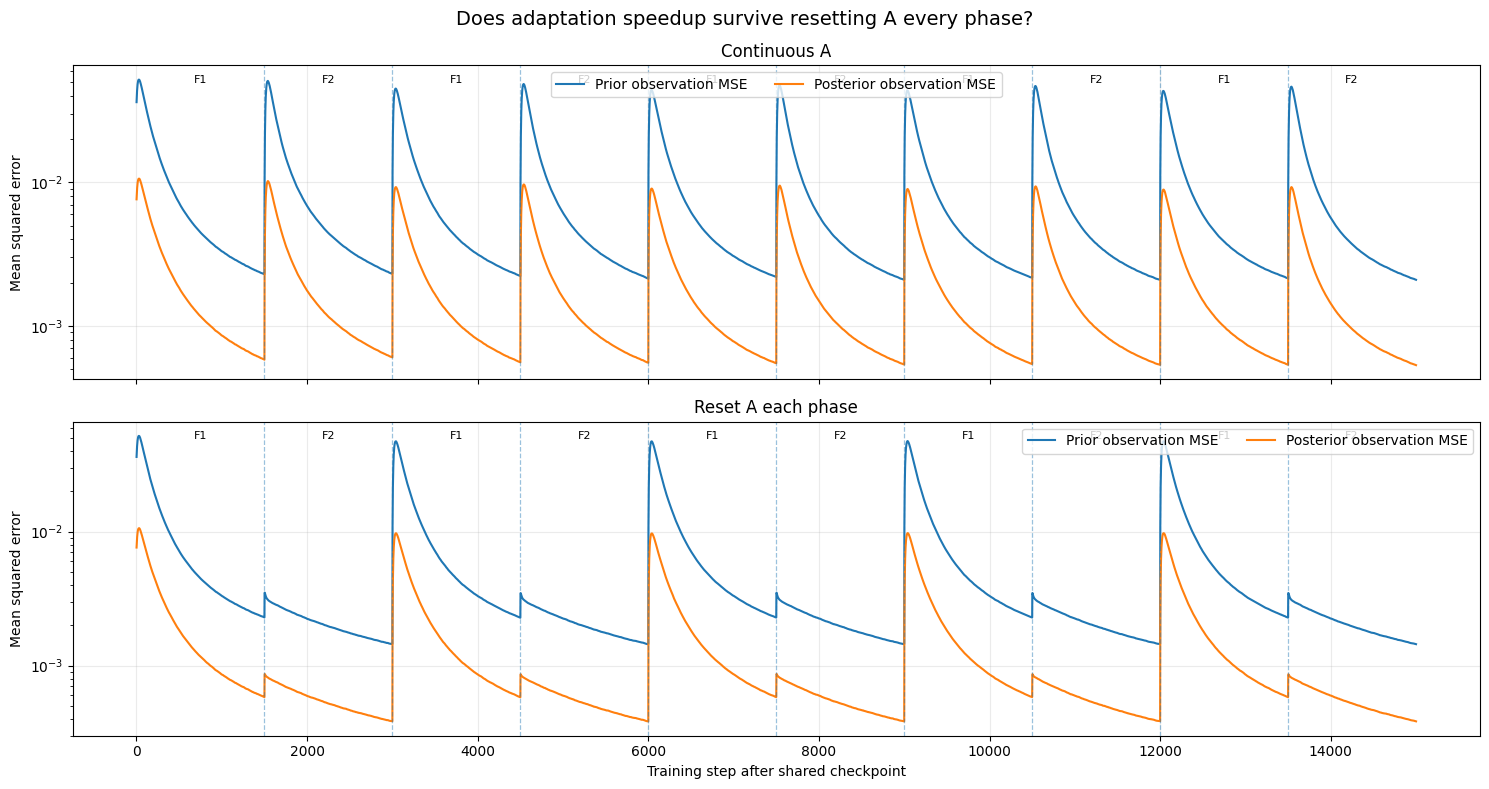

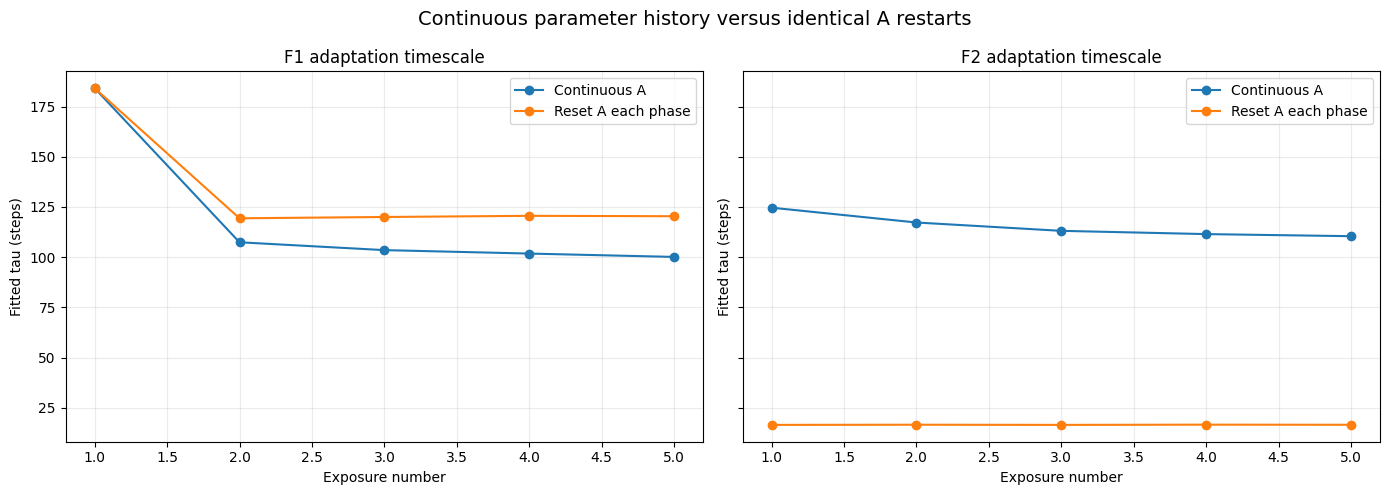

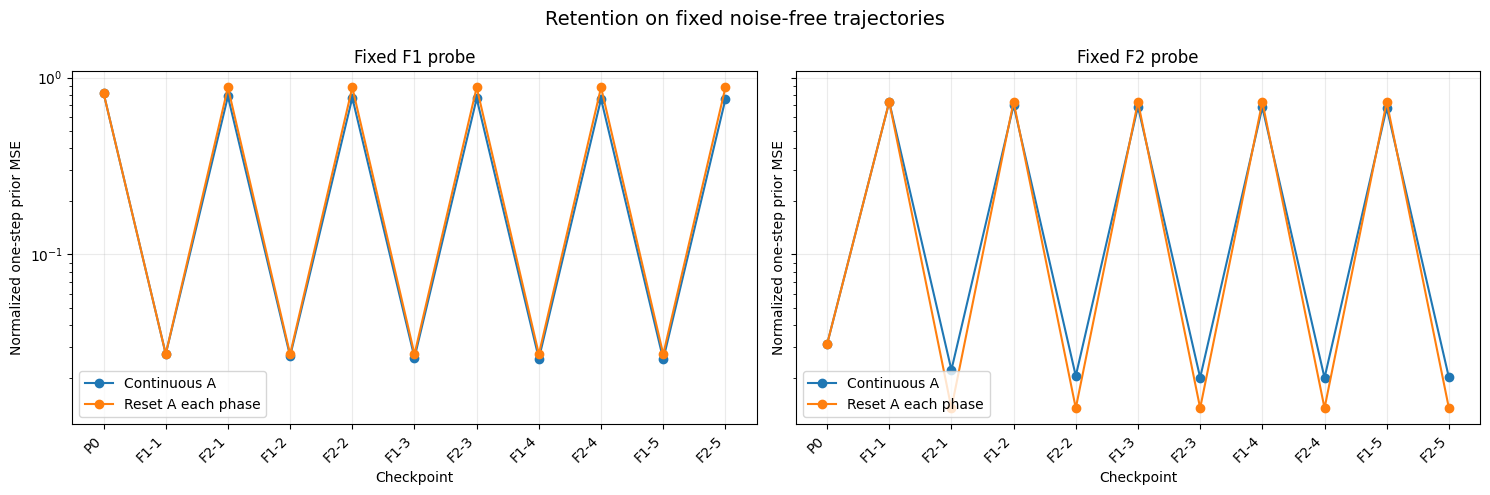

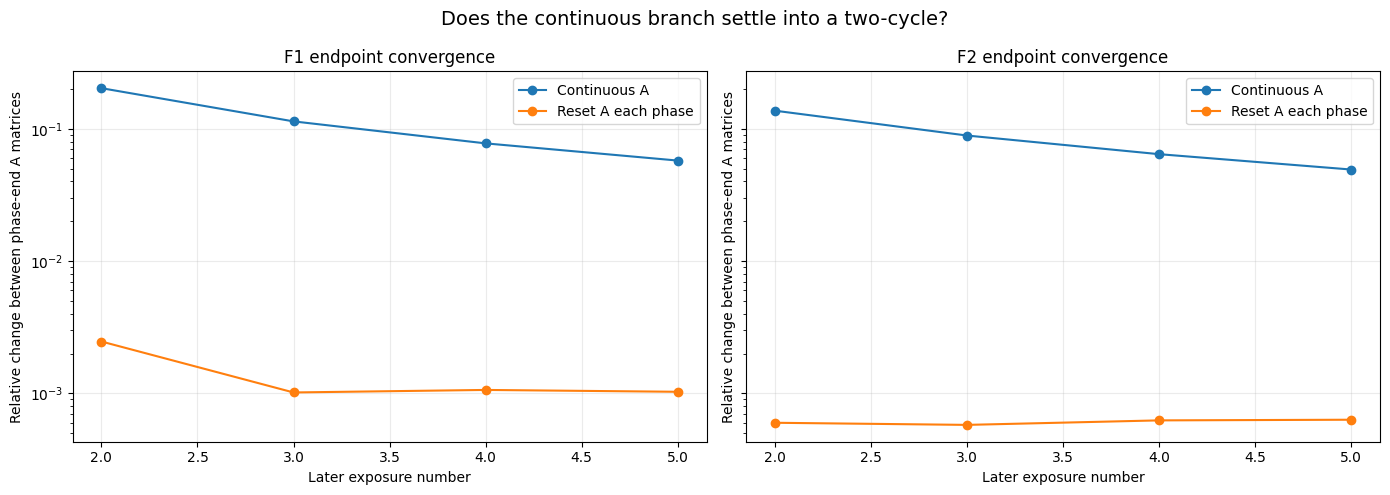

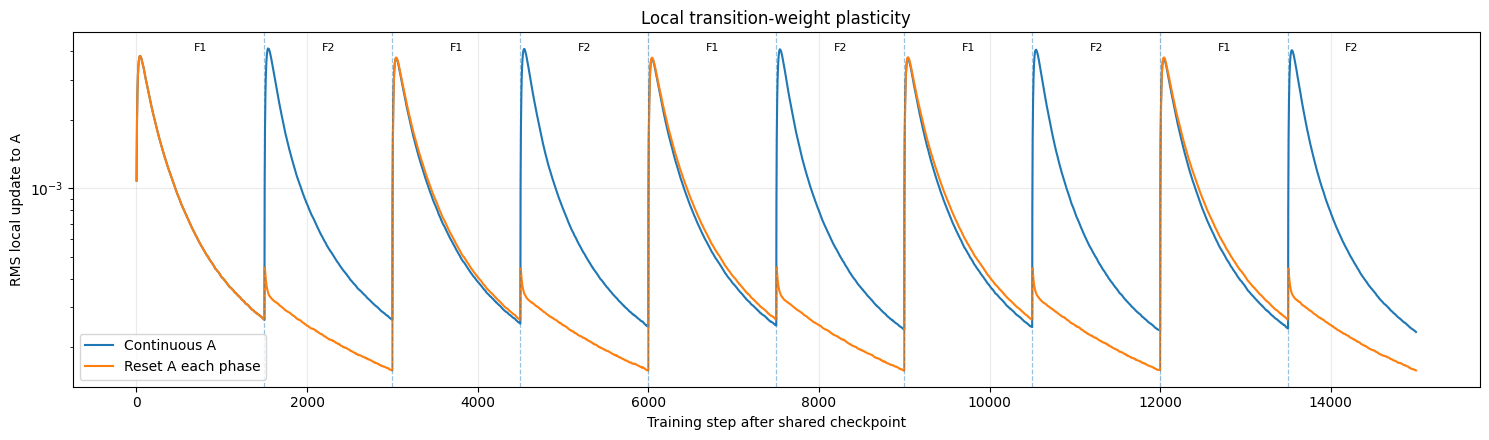

In [ ]:
# ============================================================
# NEXT CELL: continuous A-learning vs phase-reset A-learning
#
# Scientific question:
#   Does the decreasing adaptation timescale come from accumulated
#   history in A, or from something else (latent-state transients,
#   changing data distribution, etc.)?
#
# Branches start from the SAME post-F1/F2 checkpoint:
#   1) continuous_A : A keeps changing across every F1/F2 phase
#   2) reset_A      : A is reset to the exact shared checkpoint at
#                     the beginning of every phase, then relearned
#
# W and B are frozen in BOTH branches. Both branches receive the
# exact same actions, process noise, observations, and regime stream.
#
# Assumes the V7 cell already defined and ran:
#   branch_ablation_result
#   _clone_model_from_endpoint
#   _A_only_local_update
#   _make_fixed_probe
#   _evaluate_fixed_probe
#   _fit_adaptation_timescale
#   _ema_branch
#   _effective_observation_dynamics
#   _relative_frobenius
#   set_seed
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

_REQUIRED_RESET_TEST = [
    "branch_ablation_result",
    "_clone_model_from_endpoint",
    "_A_only_local_update",
    "_make_fixed_probe",
    "_evaluate_fixed_probe",
    "_fit_adaptation_timescale",
    "_ema_branch",
    "_effective_observation_dynamics",
    "_relative_frobenius",
    "set_seed",
]
_missing_reset_test = [name for name in _REQUIRED_RESET_TEST if name not in globals()]
if _missing_reset_test:
    raise RuntimeError(
        "Run the V7 branch-ablation cell first. Missing: "
        + ", ".join(_missing_reset_test)
    )


def _relative_matrix_change(new_matrix, old_matrix, eps=1e-12):
    """Relative Frobenius movement between two matrices."""
    numerator = torch.linalg.matrix_norm(new_matrix - old_matrix).item()
    denominator = torch.linalg.matrix_norm(old_matrix).item()
    return numerator / max(denominator, eps)


@torch.no_grad()
def run_continuous_vs_reset_A(
    source_result,
    *,
    phase_steps=1500,
    num_cycles=5,
    probe_length=200,
    probe_batch_size=256,
    smoothing_span=25,
    reset_latent_on_boundary=False,
):
    """Compare continuous A plasticity against resetting A every phase.

    Only A is plastic in either branch. W and B remain frozen.
    The environment trajectory and all random disturbances are shared.

    reset_latent_on_boundary=False is the primary test: only A is reset.
    Set it True as a stricter secondary control that also re-infers the
    current latent state from the boundary observation after the A reset.
    """
    if phase_steps < 100:
        raise ValueError("phase_steps must be at least 100")
    if num_cycles < 2:
        raise ValueError("num_cycles must be at least 2")

    cfg = copy.deepcopy(source_result["config"])
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.shift_step = None
    cfg.validate()

    checkpoint = source_result["checkpoint"]
    branch_names = ("continuous_A", "reset_A")
    models = {
        name: _clone_model_from_endpoint(cfg, checkpoint)
        for name in branch_names
    }

    device = torch.device(cfg.device)
    F1 = source_result["F1"].to(device)
    F2 = source_result["F2"].to(device)
    G = source_result["G"].to(device)
    shared_A = checkpoint["A"].to(device).clone()

    probes = {
        1: _make_fixed_probe(
            F1, G, cfg,
            length=probe_length,
            batch_size=probe_batch_size,
            seed=12001,
        ),
        2: _make_fixed_probe(
            F2, G, cfg,
            length=probe_length,
            batch_size=probe_batch_size,
            seed=12002,
        ),
    }

    schedule = tuple(regime for _ in range(num_cycles) for regime in (1, 2))
    total_steps = phase_steps * len(schedule)

    # One common environment trajectory for both branches.
    set_seed(cfg.seed + 909)
    x = 0.25 * torch.randn(cfg.batch_size, cfg.state_dim, device=device)
    observation = x + cfg.observation_noise * torch.randn_like(x)
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)

    z_previous = {
        name: model.infer(observation, zero_z, zero_action)["z"]
        for name, model in models.items()
    }

    history = {
        name: {
            "prior_mse": [],
            "posterior_mse": [],
            "temporal_mse": [],
            "delta_A_rms": [],
            "distance_to_F1": [],
            "distance_to_F2": [],
        }
        for name in branch_names
    }
    fits = []
    probe_history = []
    phase_endpoints = {name: [] for name in branch_names}
    reset_events = []

    def record_fixed_probes(label, phase, active_regime):
        for branch_name, model in models.items():
            F_effective, _ = _effective_observation_dynamics(model)
            for probe_regime in (1, 2):
                metric = _evaluate_fixed_probe(model, probes[probe_regime])
                probe_history.append(
                    {
                        "label": label,
                        "phase": phase,
                        "active_regime": active_regime,
                        "branch": branch_name,
                        "probe_regime": probe_regime,
                        "mse": metric["mse"],
                        "normalized_mse": metric["normalized_mse"],
                        "distance_to_F1": _relative_frobenius(F_effective, F1),
                        "distance_to_F2": _relative_frobenius(F_effective, F2),
                    }
                )

    record_fixed_probes("P0", phase=0, active_regime=2)

    progress = tqdm(
        range(total_steps),
        desc="continuous A vs reset-A control",
        unit="step",
        dynamic_ncols=True,
    )

    for global_index in progress:
        phase_index = global_index // phase_steps
        step_in_phase = global_index % phase_steps
        regime = schedule[phase_index]
        F = F1 if regime == 1 else F2

        # Reset only the transition weights in the reset branch.
        if step_in_phase == 0:
            reset_model = models["reset_A"]
            before_reset = reset_model.A.detach().clone()
            reset_model.A.copy_(shared_A)
            reset_events.append(
                {
                    "phase": phase_index + 1,
                    "regime": regime,
                    "movement_removed": _relative_matrix_change(
                        before_reset,
                        shared_A,
                    ),
                }
            )

            if reset_latent_on_boundary and global_index > 0:
                # Optional harder control: remove one-step latent carryover too,
                # while still using the current boundary observation.
                z_previous["reset_A"] = reset_model.infer(
                    observation,
                    zero_z,
                    zero_action,
                )["z"]

        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
        )
        process_noise = cfg.process_noise * torch.randn_like(x)
        x = x @ F.T + action @ G.T + process_noise
        observation = x + cfg.observation_noise * torch.randn_like(x)

        latest = {}
        for branch_name, model in models.items():
            inferred = model.infer(
                observation,
                z_previous[branch_name],
                action,
            )
            delta_A_rms = _A_only_local_update(
                model,
                inferred["z"],
                z_previous[branch_name],
                action,
                inferred["temporal_error"],
            )
            z_previous[branch_name] = inferred["z"]

            prior_mse = (
                inferred["prior_observation_prediction"] - observation
            ).square().mean().item()
            posterior_mse = inferred["observation_error"].square().mean().item()
            temporal_mse = inferred["temporal_error"].square().mean().item()
            F_effective, _ = _effective_observation_dynamics(model)

            history[branch_name]["prior_mse"].append(prior_mse)
            history[branch_name]["posterior_mse"].append(posterior_mse)
            history[branch_name]["temporal_mse"].append(temporal_mse)
            history[branch_name]["delta_A_rms"].append(delta_A_rms)
            history[branch_name]["distance_to_F1"].append(
                _relative_frobenius(F_effective, F1)
            )
            history[branch_name]["distance_to_F2"].append(
                _relative_frobenius(F_effective, F2)
            )
            latest[branch_name] = prior_mse

        if step_in_phase == phase_steps - 1:
            exposure = phase_index // 2 + 1
            for branch_name, model in models.items():
                F_effective, _ = _effective_observation_dynamics(model)
                phase_endpoints[branch_name].append(
                    {
                        "phase": phase_index + 1,
                        "regime": regime,
                        "exposure": exposure,
                        "A": model.A.detach().cpu().clone(),
                        "F_effective": F_effective.detach().cpu().clone(),
                    }
                )
            record_fixed_probes(
                f"F{regime}-{exposure}",
                phase=phase_index + 1,
                active_regime=regime,
            )

        if global_index == 0 or (global_index + 1) % 100 == 0:
            progress.set_postfix(
                phase=f"{phase_index + 1}/{len(schedule)}",
                regime=f"F{regime}",
                continuous=f"{latest['continuous_A']:.2e}",
                reset=f"{latest['reset_A']:.2e}",
            )

    # Fit adaptation timescale separately within every phase.
    for branch_name in branch_names:
        prior_curve = np.asarray(history[branch_name]["prior_mse"], dtype=np.float64)
        exposure_count = {1: 0, 2: 0}
        for phase_index, regime in enumerate(schedule):
            exposure_count[regime] += 1
            start = phase_index * phase_steps
            end = start + phase_steps
            fit = _fit_adaptation_timescale(
                prior_curve[start:end],
                smoothing_span=smoothing_span,
            )
            fits.append(
                {
                    "branch": branch_name,
                    "phase": phase_index + 1,
                    "regime": regime,
                    "exposure": exposure_count[regime],
                    **fit,
                }
            )

    # Same-regime endpoint convergence in parameter space.
    endpoint_drift = []
    for branch_name in branch_names:
        for regime in (1, 2):
            rows = [
                row for row in phase_endpoints[branch_name]
                if row["regime"] == regime
            ]
            for previous, current in zip(rows[:-1], rows[1:]):
                endpoint_drift.append(
                    {
                        "branch": branch_name,
                        "regime": regime,
                        "from_exposure": previous["exposure"],
                        "to_exposure": current["exposure"],
                        "A_drift": _relative_matrix_change(
                            current["A"], previous["A"]
                        ),
                        "F_effective_drift": _relative_matrix_change(
                            current["F_effective"], previous["F_effective"]
                        ),
                    }
                )

    return {
        "config": cfg,
        "models": models,
        "history": history,
        "fits": fits,
        "probe_history": probe_history,
        "phase_endpoints": phase_endpoints,
        "endpoint_drift": endpoint_drift,
        "reset_events": reset_events,
        "schedule": schedule,
        "phase_steps": phase_steps,
        "shared_A": shared_A.detach().cpu(),
        "F1": F1.detach().cpu(),
        "F2": F2.detach().cpu(),
        "G": G.detach().cpu(),
        "reset_latent_on_boundary": reset_latent_on_boundary,
    }


def summarize_continuous_vs_reset_A(result):
    labels = {
        "continuous_A": "Continuous A",
        "reset_A": "Reset A each phase",
    }

    print("\nContinuous-A versus phase-reset-A control")
    print("=" * 110)
    print(
        "Both branches use A-only local plasticity and see the identical "
        "trajectory. W and B are frozen."
    )
    print(
        f"Latent reset at boundaries: {result['reset_latent_on_boundary']}"
    )
    print("-" * 110)
    print("Branch                Phase Reg Exp       E0       E_inf       tau      fit R²")
    print("-" * 110)
    for row in result["fits"]:
        print(
            f"{labels[row['branch']]:<21s} "
            f"{row['phase']:>5d}  F{row['regime']}  {row['exposure']:>3d}  "
            f"{row['E0']:>9.5f}  {row['E_inf']:>10.6f}  "
            f"{row['tau']:>8.1f}  {row['r2']:>9.4f}"
        )

    print("\nFirst-to-last fitted tau")
    print("-" * 74)
    print("Branch                 Regime    first tau    last tau    speedup")
    print("-" * 74)
    for branch_name in ("continuous_A", "reset_A"):
        for regime in (1, 2):
            rows = [
                row for row in result["fits"]
                if row["branch"] == branch_name and row["regime"] == regime
            ]
            first_tau = rows[0]["tau"]
            last_tau = rows[-1]["tau"]
            speedup = first_tau / max(last_tau, 1e-12)
            print(
                f"{labels[branch_name]:<22s} F{regime:<7d} "
                f"{first_tau:>10.1f}  {last_tau:>10.1f}  {speedup:>8.2f}x"
            )

    print("\nFinal fixed-probe normalized MSE")
    print("-" * 70)
    final_label = result["probe_history"][-1]["label"]
    final_rows = [
        row for row in result["probe_history"]
        if row["label"] == final_label
    ]
    print("Branch                    F1 probe      F2 probe")
    print("-" * 70)
    for branch_name in ("continuous_A", "reset_A"):
        values = {
            row["probe_regime"]: row["normalized_mse"]
            for row in final_rows
            if row["branch"] == branch_name
        }
        print(
            f"{labels[branch_name]:<26s} "
            f"{values[1]:>11.6f}  {values[2]:>11.6f}"
        )


def _draw_reset_test_boundaries(axis, schedule, phase_steps):
    for phase_index in range(1, len(schedule)):
        axis.axvline(
            phase_index * phase_steps,
            linestyle="--",
            linewidth=0.9,
            alpha=0.45,
        )
    for phase_index, regime in enumerate(schedule):
        center = (phase_index + 0.5) * phase_steps
        axis.text(
            center,
            0.97,
            f"F{regime}",
            transform=axis.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
        )


def plot_continuous_vs_reset_A(result, smoothing_span=35):
    labels = {
        "continuous_A": "Continuous A",
        "reset_A": "Reset A each phase",
    }
    schedule = result["schedule"]
    P = result["phase_steps"]
    total_steps = P * len(schedule)
    steps = np.arange(1, total_steps + 1)

    # 1) Online prediction errors.
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    for axis, branch_name in zip(axes, ("continuous_A", "reset_A")):
        h = result["history"][branch_name]
        axis.plot(
            steps,
            _ema_branch(h["prior_mse"], smoothing_span),
            label="Prior observation MSE",
        )
        axis.plot(
            steps,
            _ema_branch(h["posterior_mse"], smoothing_span),
            label="Posterior observation MSE",
        )
        axis.set_yscale("log")
        axis.set_ylabel("Mean squared error")
        axis.set_title(labels[branch_name])
        axis.grid(alpha=0.25)
        axis.legend(ncol=2)
        _draw_reset_test_boundaries(axis, schedule, P)
    axes[-1].set_xlabel("Training step after shared checkpoint")
    fig.suptitle("Does adaptation speedup survive resetting A every phase?", fontsize=14)
    fig.tight_layout()
    plt.show()

    # 2) Fitted adaptation timescales.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for regime, axis in ((1, axes[0]), (2, axes[1])):
        for branch_name in ("continuous_A", "reset_A"):
            rows = [
                row for row in result["fits"]
                if row["branch"] == branch_name and row["regime"] == regime
            ]
            axis.plot(
                [row["exposure"] for row in rows],
                [row["tau"] for row in rows],
                marker="o",
                label=labels[branch_name],
            )
        axis.set_title(f"F{regime} adaptation timescale")
        axis.set_xlabel("Exposure number")
        axis.set_ylabel("Fitted tau (steps)")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle("Continuous parameter history versus identical A restarts", fontsize=14)
    fig.tight_layout()
    plt.show()

    # 3) Fixed-probe retention after each phase.
    probe_rows = result["probe_history"]
    checkpoint_labels = []
    for row in probe_rows:
        if row["branch"] == "continuous_A" and row["probe_regime"] == 1:
            checkpoint_labels.append(row["label"])
    x_ticks = np.arange(len(checkpoint_labels))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for probe_regime, axis in ((1, axes[0]), (2, axes[1])):
        for branch_name in ("continuous_A", "reset_A"):
            values = [
                row["normalized_mse"]
                for label in checkpoint_labels
                for row in probe_rows
                if row["label"] == label
                and row["branch"] == branch_name
                and row["probe_regime"] == probe_regime
            ]
            axis.plot(
                x_ticks,
                values,
                marker="o",
                label=labels[branch_name],
            )
        axis.set_yscale("log")
        axis.set_xticks(x_ticks)
        axis.set_xticklabels(checkpoint_labels, rotation=45, ha="right")
        axis.set_xlabel("Checkpoint")
        axis.set_ylabel("Normalized one-step prior MSE")
        axis.set_title(f"Fixed F{probe_regime} probe")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle("Retention on fixed noise-free trajectories", fontsize=14)
    fig.tight_layout()
    plt.show()

    # 4) Convergence of same-regime phase-end A matrices.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for regime, axis in ((1, axes[0]), (2, axes[1])):
        for branch_name in ("continuous_A", "reset_A"):
            rows = [
                row for row in result["endpoint_drift"]
                if row["branch"] == branch_name and row["regime"] == regime
            ]
            axis.plot(
                [row["to_exposure"] for row in rows],
                [row["A_drift"] for row in rows],
                marker="o",
                label=labels[branch_name],
            )
        axis.set_yscale("log")
        axis.set_title(f"F{regime} endpoint convergence")
        axis.set_xlabel("Later exposure number")
        axis.set_ylabel("Relative change between phase-end A matrices")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle("Does the continuous branch settle into a two-cycle?", fontsize=14)
    fig.tight_layout()
    plt.show()

    # 5) Local plasticity magnitude.
    fig, axis = plt.subplots(figsize=(15, 4.5))
    for branch_name in ("continuous_A", "reset_A"):
        axis.plot(
            steps,
            _ema_branch(
                result["history"][branch_name]["delta_A_rms"],
                smoothing_span,
            ),
            label=labels[branch_name],
        )
    axis.set_yscale("log")
    axis.set_xlabel("Training step after shared checkpoint")
    axis.set_ylabel("RMS local update to A")
    axis.set_title("Local transition-weight plasticity")
    axis.grid(alpha=0.25)
    axis.legend()
    _draw_reset_test_boundaries(axis, schedule, P)
    fig.tight_layout()
    plt.show()


# -------------------------
# Run the experiment
# -------------------------
CONTINUOUS_RESET_PHASE_STEPS = 1500
CONTINUOUS_RESET_NUM_CYCLES = 5

continuous_reset_result = run_continuous_vs_reset_A(
    branch_ablation_result,
    phase_steps=CONTINUOUS_RESET_PHASE_STEPS,
    num_cycles=CONTINUOUS_RESET_NUM_CYCLES,
    probe_length=200,
    probe_batch_size=256,
    smoothing_span=25,
    reset_latent_on_boundary=False,
)

summarize_continuous_vs_reset_A(continuous_reset_result)
plot_continuous_vs_reset_A(continuous_reset_result)

pretrain alternating F1/F2:   0%|          | 0/6000 [00:00<?, ?step/s]

pretrain matched F2-only control:   0%|          | 0/6000 [00:00<?, ?step/s]

identical F3 adaptation stream:   0%|          | 0/1500 [00:00<?, ?step/s]


F1/F2 -> composed F3 positive-transfer experiment
F3 is exactly F0 + beta(D1 + D2). All three models remain fully plastic and see the identical F3 trajectory.
beta=1.36647 | spectral radii: F0=0.662, F1=0.723, F2=0.783, F3=0.864
------------------------------------------------------------------------------------------------------------------------------
Branch             Start dF3   Final dF3       E0       E_inf      tau   fit R²  half-step   early AUC   final prior   final post
------------------------------------------------------------------------------------------------------------------------------
F1/F2 history           0.588       0.476    0.01820    0.001471     84.5   0.9596         48     0.00539     0.001019    0.000236
F2-only history         0.628       0.509    0.01865    0.001769    104.0   0.9560         58     0.00650     0.001233    0.000284
Scratch on F3           1.000       0.639    0.09801    0.003819    196.7   0.9931        141     0.05016     0.003227    0.

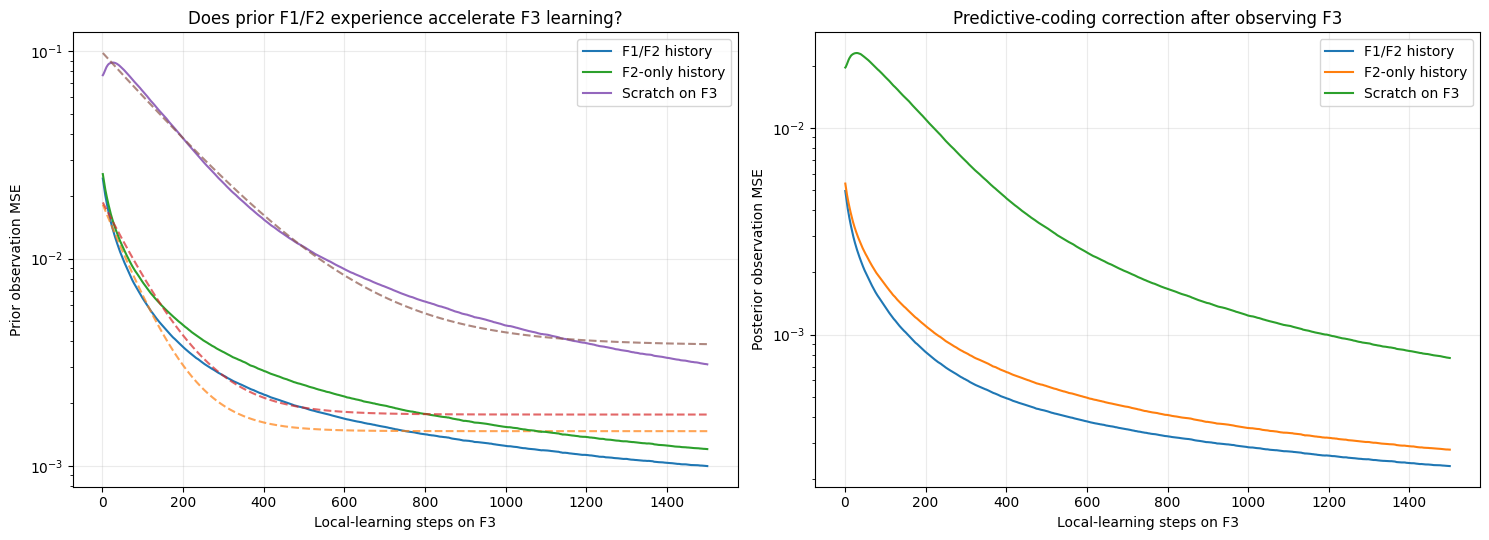

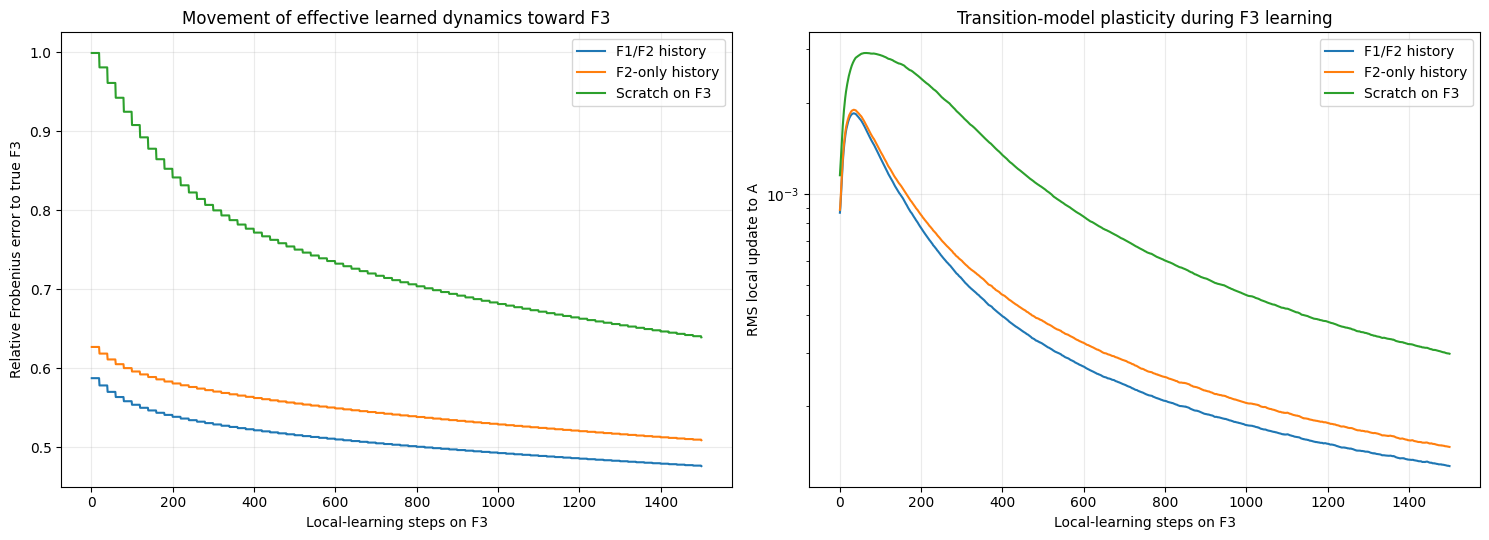

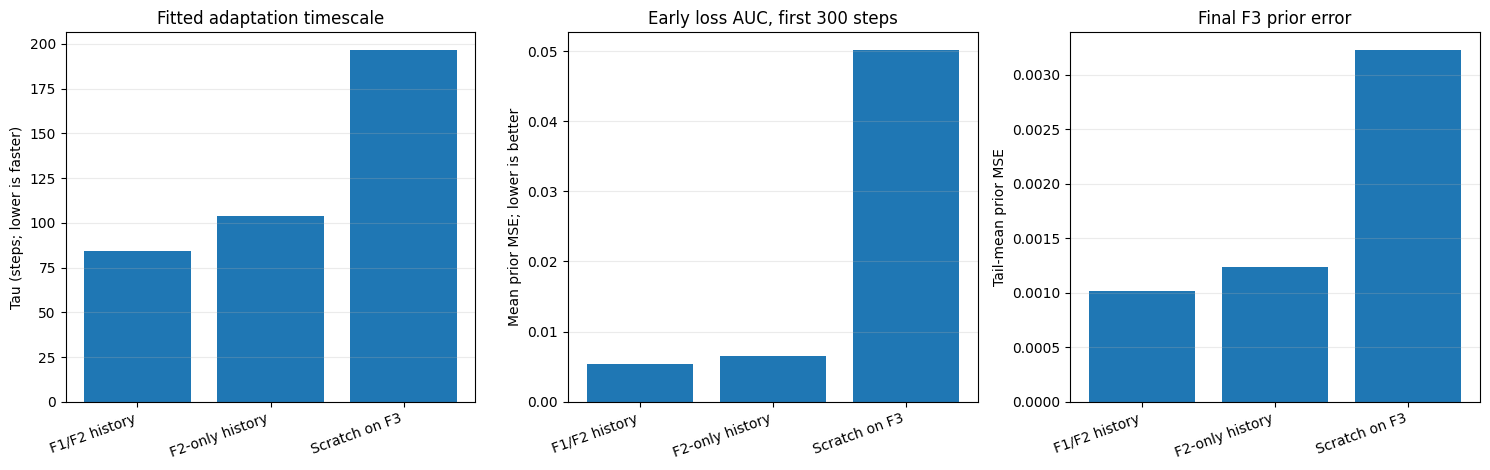

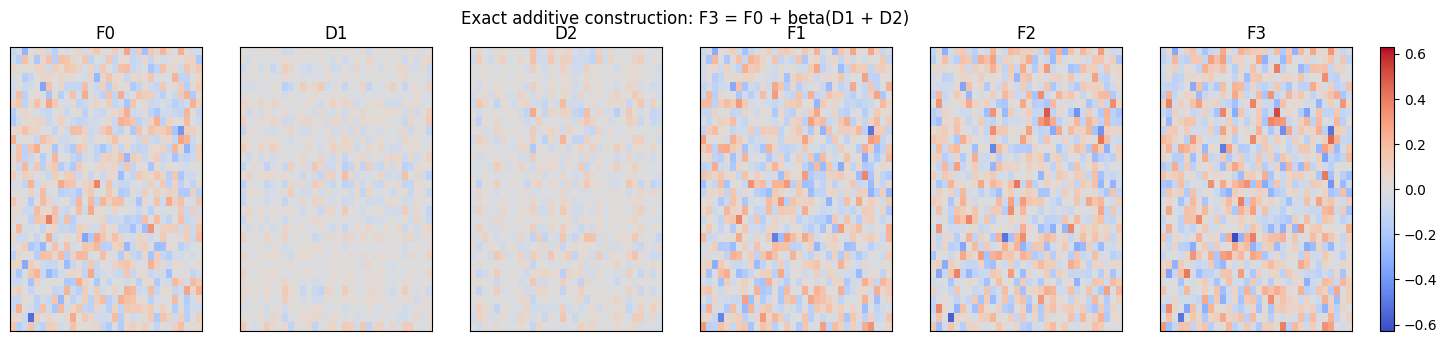

In [ ]:
# ============================================================
# NEXT CELL: does F1/F2 experience accelerate learning F3?
#
# Compositional environment:
#   F1 = F0 + beta * D1
#   F2 = F0 + beta * D2
#   F3 = F0 + beta * (D1 + D2)
#
# All matrices are kept stable WITHOUT separately rescaling F1/F2/F3,
# preserving the exact additive relationship.
#
# Three equally plastic models are compared on the IDENTICAL F3 stream:
#   1) F1/F2 history : repeated alternating pretraining on F1 and F2
#   2) F2-only       : same total pretraining steps, only on F2
#   3) Scratch       : no pretraining
#
# Every model continues full local predictive-coding learning on F3.
# We measure initial error, fitted adaptation tau, early-loss AUC,
# half-decay time, final error, and effective-dynamics distance to F3.
#
# Assumes an earlier cell defined:
#   PCConfig, PredictiveCodingWorldModel, stable_matrix, set_seed
# ============================================================

import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

try:
    from scipy.optimize import curve_fit
except ImportError as exc:
    raise RuntimeError("SciPy is required for exponential adaptation fitting.") from exc

_REQUIRED = [
    "PCConfig",
    "PredictiveCodingWorldModel",
    "stable_matrix",
    "set_seed",
]
_missing = [name for name in _REQUIRED if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run the predictive-coding architecture cell first. Missing: "
        + ", ".join(_missing)
    )


def _transfer_ema(values, span=31):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return values
    alpha = 2.0 / (span + 1.0)
    out = np.empty_like(values)
    out[0] = values[0]
    for index in range(1, len(values)):
        out[index] = alpha * values[index] + (1.0 - alpha) * out[index - 1]
    return out


def _transfer_exp_curve(step, floor, amplitude, tau):
    return floor + amplitude * np.exp(-step / tau)


def _fit_transfer_curve(values, smoothing_span=25):
    """Fit E(s)=E_inf + amplitude*exp(-s/tau)."""
    y = _transfer_ema(values, smoothing_span)
    x = np.arange(len(y), dtype=np.float64)
    if len(y) < 30 or not np.all(np.isfinite(y)):
        return {
            "E0": np.nan,
            "E_inf": np.nan,
            "tau": np.nan,
            "r2": np.nan,
            "fit": np.full_like(y, np.nan),
        }

    tail = max(20, len(y) // 8)
    floor0 = max(float(np.median(y[-tail:])), 1e-12)
    amplitude0 = max(float(y[0] - floor0), 1e-12)
    tau0 = max(10.0, len(y) / 4.0)

    try:
        params, _ = curve_fit(
            _transfer_exp_curve,
            x,
            y,
            p0=(floor0, amplitude0, tau0),
            bounds=(
                (0.0, 0.0, 1.0),
                (
                    max(float(y.max()) * 2.0, 1e-8),
                    max(float(y.max()) * 4.0, 1e-8),
                    len(y) * 30.0,
                ),
            ),
            maxfev=30000,
        )
        floor, amplitude, tau = [float(value) for value in params]
        prediction = _transfer_exp_curve(x, floor, amplitude, tau)
        residual = np.sum((y - prediction) ** 2)
        total = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - residual / max(total, 1e-12)
        return {
            "E0": floor + amplitude,
            "E_inf": floor,
            "tau": tau,
            "r2": float(r2),
            "fit": prediction,
        }
    except Exception:
        return {
            "E0": float(y[0]),
            "E_inf": floor0,
            "tau": np.nan,
            "r2": np.nan,
            "fit": np.full_like(y, np.nan),
        }


def _spectral_radius(matrix):
    return float(torch.linalg.eigvals(matrix).abs().max().real.item())


def _relative_matrix_error(estimate, target):
    return float(
        (
            torch.linalg.matrix_norm(estimate - target)
            / torch.linalg.matrix_norm(target).clamp_min(1e-12)
        ).item()
    )


@torch.no_grad()
def _effective_F_transfer(model):
    # o ~= Wz and z_next ~= Az imply o_next ~= W A W^+ o.
    return model.W @ model.A @ torch.linalg.pinv(model.W)


def _clone_transfer_model(cfg, source_model):
    clone = PredictiveCodingWorldModel(copy.deepcopy(cfg))
    with torch.no_grad():
        clone.A.copy_(source_model.A)
        clone.B.copy_(source_model.B)
        clone.W.copy_(source_model.W)
    return clone


def _random_low_rank_factor(dim, rank, device, generator):
    left = torch.randn(dim, rank, device=device, generator=generator)
    right = torch.randn(dim, rank, device=device, generator=generator)
    factor = (left @ right.T) / math.sqrt(rank)
    # Normalize by operator norm so beta has a consistent interpretation.
    operator_norm = torch.linalg.matrix_norm(factor, ord=2).clamp_min(1e-8)
    return factor / operator_norm


@torch.no_grad()
def _make_composed_dynamics(cfg, *, seed=4242, factor_rank=4, stability_margin=0.985):
    """Create exactly additive F1/F2/F3 while keeping all three stable."""
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    # Leave headroom so two additive factors can coexist in F3.
    base_radius = min(0.68, cfg.dynamics_radius * 0.72)
    F0 = stable_matrix(cfg.state_dim, base_radius, device)
    D1 = _random_low_rank_factor(
        cfg.state_dim, factor_rank, device, generator
    )
    D2 = _random_low_rank_factor(
        cfg.state_dim, factor_rank, device, generator
    )

    target_radius = cfg.dynamics_radius * stability_margin

    def all_stable(beta):
        candidates = (
            F0 + beta * D1,
            F0 + beta * D2,
            F0 + beta * (D1 + D2),
        )
        return max(_spectral_radius(matrix) for matrix in candidates) <= target_radius

    # Find the largest stable beta by expansion then binary search.
    low, high = 0.0, 0.05
    while all_stable(high) and high < 8.0:
        low = high
        high *= 2.0
    for _ in range(60):
        middle = 0.5 * (low + high)
        if all_stable(middle):
            low = middle
        else:
            high = middle

    beta = low * 0.90
    F1 = F0 + beta * D1
    F2 = F0 + beta * D2
    F3 = F0 + beta * (D1 + D2)

    G = (
        torch.randn(
            cfg.state_dim,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        * cfg.action_scale
    )

    return {
        "F0": F0,
        "D1": D1,
        "D2": D2,
        "F1": F1,
        "F2": F2,
        "F3": F3,
        "G": G,
        "beta": beta,
        "radii": {
            "F0": _spectral_radius(F0),
            "F1": _spectral_radius(F1),
            "F2": _spectral_radius(F2),
            "F3": _spectral_radius(F3),
        },
    }


@torch.no_grad()
def _train_transfer_history(
    model,
    cfg,
    matrices,
    schedule,
    *,
    steps_per_phase,
    seed,
    description,
):
    """Pretrain one model with explicit local updates on a supplied schedule."""
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    x = 0.25 * torch.randn(
        cfg.batch_size,
        cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation = x + cfg.observation_noise * torch.randn(
        x.shape,
        device=device,
        generator=generator,
    )
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    z_previous = model.infer(observation, zero_z, zero_action)["z"]

    total_steps = len(schedule) * steps_per_phase
    progress = tqdm(
        range(total_steps),
        desc=description,
        unit="step",
        dynamic_ncols=True,
        leave=False,
    )

    final_prior = float("nan")
    for global_index in progress:
        phase = global_index // steps_per_phase
        regime = schedule[phase]
        F = matrices[f"F{regime}"]

        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        process_noise = cfg.process_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )
        observation_noise = cfg.observation_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )
        x = x @ F.T + action @ matrices["G"].T + process_noise
        observation = x + observation_noise

        inferred = model.infer(observation, z_previous, action)
        model.local_update(
            z=inferred["z"],
            z_previous=z_previous,
            action=action,
            observation_error=inferred["observation_error"],
            temporal_error=inferred["temporal_error"],
        )
        z_previous = inferred["z"]
        final_prior = (
            inferred["prior_observation_prediction"] - observation
        ).square().mean().item()

        if global_index == 0 or (global_index + 1) % 250 == 0:
            progress.set_postfix(
                phase=f"{phase + 1}/{len(schedule)}",
                regime=f"F{regime}",
                prior=f"{final_prior:.2e}",
            )

    return final_prior


@torch.no_grad()
def _run_identical_F3_stream(
    models,
    cfg,
    matrices,
    *,
    test_steps,
    seed,
    diagnostic_every=20,
):
    """Train all branches on one identical F3 trajectory and noise stream."""
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    x = 0.25 * torch.randn(
        cfg.batch_size,
        cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation = x + cfg.observation_noise * torch.randn(
        x.shape,
        device=device,
        generator=generator,
    )
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)
    z_previous = {
        name: model.infer(observation, zero_z, zero_action)["z"]
        for name, model in models.items()
    }

    history = {
        name: {
            "prior_mse": [],
            "posterior_mse": [],
            "temporal_mse": [],
            "delta_A_rms": [],
            "distance_to_F3": [],
        }
        for name in models
    }

    latest_distance = {
        name: _relative_matrix_error(_effective_F_transfer(model), matrices["F3"])
        for name, model in models.items()
    }
    start_distance = dict(latest_distance)

    progress = tqdm(
        range(test_steps),
        desc="identical F3 adaptation stream",
        unit="step",
        dynamic_ncols=True,
    )

    for step in progress:
        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        process_noise = cfg.process_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )
        observation_noise = cfg.observation_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )
        x = x @ matrices["F3"].T + action @ matrices["G"].T + process_noise
        observation = x + observation_noise

        latest_prior = {}
        for name, model in models.items():
            inferred = model.infer(observation, z_previous[name], action)
            stats = model.local_update(
                z=inferred["z"],
                z_previous=z_previous[name],
                action=action,
                observation_error=inferred["observation_error"],
                temporal_error=inferred["temporal_error"],
            )
            z_previous[name] = inferred["z"]

            prior = (
                inferred["prior_observation_prediction"] - observation
            ).square().mean().item()
            posterior = inferred["observation_error"].square().mean().item()
            temporal = inferred["temporal_error"].square().mean().item()

            if (
                step == 0
                or (step + 1) % diagnostic_every == 0
                or step == test_steps - 1
            ):
                latest_distance[name] = _relative_matrix_error(
                    _effective_F_transfer(model),
                    matrices["F3"],
                )

            history[name]["prior_mse"].append(prior)
            history[name]["posterior_mse"].append(posterior)
            history[name]["temporal_mse"].append(temporal)
            history[name]["delta_A_rms"].append(stats["delta_A_rms"])
            history[name]["distance_to_F3"].append(latest_distance[name])
            latest_prior[name] = prior

        if step == 0 or (step + 1) % 100 == 0:
            progress.set_postfix(
                history=f"{latest_prior['F1_F2_history']:.2e}",
                F2only=f"{latest_prior['F2_only']:.2e}",
                scratch=f"{latest_prior['scratch']:.2e}",
            )

    return history, start_distance, latest_distance


def _first_half_decay_step(curve, E0, E_inf):
    if not np.isfinite(E0) or not np.isfinite(E_inf) or E0 <= E_inf:
        return None
    threshold = E_inf + 0.5 * (E0 - E_inf)
    smoothed = _transfer_ema(curve, 25)
    indices = np.flatnonzero(smoothed <= threshold)
    return int(indices[0] + 1) if indices.size else None


def _summarize_F3_transfer(result):
    labels = result["labels"]
    rows = result["metrics"]

    print("\nF1/F2 -> composed F3 positive-transfer experiment")
    print("=" * 126)
    print(
        "F3 is exactly F0 + beta(D1 + D2). All three models remain fully plastic "
        "and see the identical F3 trajectory."
    )
    print(
        f"beta={result['matrices']['beta']:.5f} | spectral radii: "
        + ", ".join(
            f"{name}={value:.3f}"
            for name, value in result["matrices"]["radii"].items()
        )
    )
    print("-" * 126)
    print(
        "Branch             Start dF3   Final dF3       E0       E_inf      tau   fit R² "
        " half-step   early AUC   final prior   final post"
    )
    print("-" * 126)
    for name in result["branch_order"]:
        row = rows[name]
        half_text = "None" if row["half_step"] is None else str(row["half_step"])
        print(
            f"{labels[name]:<18s} "
            f"{row['start_dF3']:>10.3f}  {row['final_dF3']:>10.3f}  "
            f"{row['E0']:>9.5f}  {row['E_inf']:>10.6f}  "
            f"{row['tau']:>7.1f}  {row['r2']:>7.4f}  "
            f"{half_text:>9s}  {row['early_auc']:>10.5f}  "
            f"{row['final_prior']:>11.6f}  {row['final_posterior']:>10.6f}"
        )

    history_tau = rows["F1_F2_history"]["tau"]
    F2_tau = rows["F2_only"]["tau"]
    scratch_tau = rows["scratch"]["tau"]
    history_auc = rows["F1_F2_history"]["early_auc"]
    F2_auc = rows["F2_only"]["early_auc"]
    scratch_auc = rows["scratch"]["early_auc"]

    print("\nPrimary comparisons")
    print("-" * 72)
    if np.isfinite(history_tau) and np.isfinite(F2_tau):
        print(f"Tau speedup vs F2-only: {F2_tau / max(history_tau, 1e-12):.2f}x")
    if np.isfinite(history_tau) and np.isfinite(scratch_tau):
        print(f"Tau speedup vs scratch: {scratch_tau / max(history_tau, 1e-12):.2f}x")
    print(f"Early-AUC reduction vs F2-only: {(1.0 - history_auc / max(F2_auc, 1e-12)) * 100.0:.1f}%")
    print(f"Early-AUC reduction vs scratch: {(1.0 - history_auc / max(scratch_auc, 1e-12)) * 100.0:.1f}%")
    print(
        "Interpretation rule: F1/F2 history beats F2-only only if exposure to the "
        "missing D1 factor adds transfer beyond generic pretraining and F2 proximity."
    )


def _plot_F3_transfer(result, smoothing_span=31):
    history = result["history"]
    metrics = result["metrics"]
    labels = result["labels"]
    order = result["branch_order"]
    steps = np.arange(1, result["test_steps"] + 1)

    # Figure 1: actual F3 learning curves and exponential fits.
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for name in order:
        smoothed = _transfer_ema(history[name]["prior_mse"], smoothing_span)
        axes[0].plot(steps, smoothed, label=labels[name])
        fit = metrics[name]["fit"]
        if np.all(np.isfinite(fit)):
            axes[0].plot(steps, fit, linestyle="--", alpha=0.7)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Local-learning steps on F3")
    axes[0].set_ylabel("Prior observation MSE")
    axes[0].set_title("Does prior F1/F2 experience accelerate F3 learning?")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    for name in order:
        axes[1].plot(
            steps,
            _transfer_ema(history[name]["posterior_mse"], smoothing_span),
            label=labels[name],
        )
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Local-learning steps on F3")
    axes[1].set_ylabel("Posterior observation MSE")
    axes[1].set_title("Predictive-coding correction after observing F3")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

    # Figure 2: structural approach to F3 and plasticity magnitude.
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for name in order:
        axes[0].plot(
            steps,
            history[name]["distance_to_F3"],
            label=labels[name],
        )
    axes[0].set_xlabel("Local-learning steps on F3")
    axes[0].set_ylabel("Relative Frobenius error to true F3")
    axes[0].set_title("Movement of effective learned dynamics toward F3")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    for name in order:
        axes[1].plot(
            steps,
            _transfer_ema(history[name]["delta_A_rms"], smoothing_span),
            label=labels[name],
        )
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Local-learning steps on F3")
    axes[1].set_ylabel("RMS local update to A")
    axes[1].set_title("Transition-model plasticity during F3 learning")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

    # Figure 3: compact metric comparison.
    x = np.arange(len(order))
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    axes[0].bar(x, [metrics[name]["tau"] for name in order])
    axes[0].set_title("Fitted adaptation timescale")
    axes[0].set_ylabel("Tau (steps; lower is faster)")

    axes[1].bar(x, [metrics[name]["early_auc"] for name in order])
    axes[1].set_title(f"Early loss AUC, first {result['auc_steps']} steps")
    axes[1].set_ylabel("Mean prior MSE; lower is better")

    axes[2].bar(x, [metrics[name]["final_prior"] for name in order])
    axes[2].set_title("Final F3 prior error")
    axes[2].set_ylabel("Tail-mean prior MSE")

    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels([labels[name] for name in order], rotation=20, ha="right")
        axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    plt.show()

    # Figure 4: environment construction heatmaps.
    matrices = result["matrices"]
    shown = ["F0", "D1", "D2", "F1", "F2", "F3"]
    arrays = [matrices[name].detach().cpu().numpy() for name in shown]
    limit = max(float(np.max(np.abs(array))) for array in arrays)
    figure, axes = plt.subplots(1, len(shown), figsize=(18, 3.7))
    image = None
    for axis, name, array in zip(axes, shown, arrays):
        image = axis.imshow(array, cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto")
        axis.set_title(name)
        axis.set_xticks([])
        axis.set_yticks([])
    figure.colorbar(image, ax=axes.ravel().tolist(), fraction=0.018, pad=0.02)
    figure.suptitle("Exact additive construction: F3 = F0 + beta(D1 + D2)")
    plt.show()


@torch.no_grad()
def run_F1_F2_to_composed_F3_transfer(
    base_cfg,
    *,
    pretrain_steps_per_regime=1000,
    pretrain_cycles=3,
    F3_test_steps=1500,
    factor_rank=4,
    auc_steps=300,
    smoothing_span=25,
    diagnostic_every=20,
    seed_offset=1900,
):
    """Run the complete positive-transfer test."""
    if pretrain_steps_per_regime < 100:
        raise ValueError("pretrain_steps_per_regime must be at least 100")
    if pretrain_cycles < 1:
        raise ValueError("pretrain_cycles must be positive")
    if F3_test_steps < 100:
        raise ValueError("F3_test_steps must be at least 100")

    cfg = copy.deepcopy(base_cfg)
    cfg.shift_step = None
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.train_steps = F3_test_steps
    cfg.validate()

    set_seed(cfg.seed + seed_offset)
    matrices = _make_composed_dynamics(
        cfg,
        seed=cfg.seed + seed_offset + 1,
        factor_rank=factor_rank,
    )

    # Exact same random initialization for all three models.
    set_seed(cfg.seed + seed_offset + 2)
    initial_model = PredictiveCodingWorldModel(cfg)
    models = {
        "F1_F2_history": _clone_transfer_model(cfg, initial_model),
        "F2_only": _clone_transfer_model(cfg, initial_model),
        "scratch": _clone_transfer_model(cfg, initial_model),
    }

    alternating_schedule = tuple(
        regime for _ in range(pretrain_cycles) for regime in (1, 2)
    )
    total_pretrain_phases = len(alternating_schedule)
    F2_only_schedule = tuple(2 for _ in range(total_pretrain_phases))

    pretraining_final = {}
    pretraining_final["F1_F2_history"] = _train_transfer_history(
        models["F1_F2_history"],
        cfg,
        matrices,
        alternating_schedule,
        steps_per_phase=pretrain_steps_per_regime,
        seed=cfg.seed + seed_offset + 10,
        description="pretrain alternating F1/F2",
    )
    pretraining_final["F2_only"] = _train_transfer_history(
        models["F2_only"],
        cfg,
        matrices,
        F2_only_schedule,
        steps_per_phase=pretrain_steps_per_regime,
        seed=cfg.seed + seed_offset + 10,  # same random draws as alternating branch
        description="pretrain matched F2-only control",
    )
    pretraining_final["scratch"] = np.nan

    history, start_distance, final_distance = _run_identical_F3_stream(
        models,
        cfg,
        matrices,
        test_steps=F3_test_steps,
        seed=cfg.seed + seed_offset + 20,
        diagnostic_every=diagnostic_every,
    )

    auc_steps = int(min(max(1, auc_steps), F3_test_steps))
    tail = max(25, F3_test_steps // 10)
    metrics = {}
    for name in models:
        curve = np.asarray(history[name]["prior_mse"], dtype=np.float64)
        posterior = np.asarray(history[name]["posterior_mse"], dtype=np.float64)
        fit = _fit_transfer_curve(curve, smoothing_span=smoothing_span)
        metrics[name] = {
            **fit,
            "half_step": _first_half_decay_step(curve, fit["E0"], fit["E_inf"]),
            "early_auc": float(np.mean(curve[:auc_steps])),
            "final_prior": float(np.mean(curve[-tail:])),
            "final_posterior": float(np.mean(posterior[-tail:])),
            "start_dF3": start_distance[name],
            "final_dF3": final_distance[name],
        }

    result = {
        "config": cfg,
        "matrices": {
            key: (value.detach().cpu() if isinstance(value, torch.Tensor) else value)
            for key, value in matrices.items()
        },
        "models": models,
        "history": history,
        "metrics": metrics,
        "pretraining_final": pretraining_final,
        "pretrain_steps_per_regime": pretrain_steps_per_regime,
        "pretrain_cycles": pretrain_cycles,
        "test_steps": F3_test_steps,
        "auc_steps": auc_steps,
        "branch_order": ("F1_F2_history", "F2_only", "scratch"),
        "labels": {
            "F1_F2_history": "F1/F2 history",
            "F2_only": "F2-only history",
            "scratch": "Scratch on F3",
        },
    }
    return result


# -------------------------
# Run the experiment
# -------------------------
# For a fast debugging pass, use 300 / 1 / 500.
# For a stronger result after it works, use 1500 / 5 / 2500 and repeat seeds.
TRANSFER_PRETRAIN_STEPS_PER_REGIME = 1000
TRANSFER_PRETRAIN_CYCLES = 3
TRANSFER_F3_TEST_STEPS = 1500
TRANSFER_FACTOR_RANK = 4
TRANSFER_EARLY_AUC_STEPS = 300

# Reuse switch_cfg when present; otherwise make the standard identifiable config.
if "switch_cfg" in globals():
    transfer_cfg = copy.deepcopy(switch_cfg)
elif "cfg" in globals() and isinstance(cfg, PCConfig):
    transfer_cfg = copy.deepcopy(cfg)
else:
    transfer_cfg = PCConfig()

transfer_cfg.mixed_observations = False
transfer_cfg.obs_dim = transfer_cfg.state_dim
transfer_cfg.latent_dim = transfer_cfg.state_dim
transfer_cfg.visualize = False
transfer_cfg.record_checkpoints = False
transfer_cfg.shift_step = None
transfer_cfg.validate()

composed_F3_transfer_result = run_F1_F2_to_composed_F3_transfer(
    transfer_cfg,
    pretrain_steps_per_regime=TRANSFER_PRETRAIN_STEPS_PER_REGIME,
    pretrain_cycles=TRANSFER_PRETRAIN_CYCLES,
    F3_test_steps=TRANSFER_F3_TEST_STEPS,
    factor_rank=TRANSFER_FACTOR_RANK,
    auc_steps=TRANSFER_EARLY_AUC_STEPS,
    smoothing_span=25,
    diagnostic_every=20,
)

_summarize_F3_transfer(composed_F3_transfer_result)
_plot_F3_transfer(composed_F3_transfer_result)

bidirectional composition worlds:   0%|          | 0/3 [00:00<?, ?world/s]

world 1: F1/F2 history:   0%|          | 0/3200 [00:00<?, ?step/s]

world 1: F2-only history:   0%|          | 0/3200 [00:00<?, ?step/s]

world 1: adapt Fpp:   0%|          | 0/1000 [00:00<?, ?step/s]

world 1: adapt Fpm:   0%|          | 0/1000 [00:00<?, ?step/s]

...

world 3: adapt Frandom:   0%|          | 0/1000 [00:00<?, ?step/s]

world 3: F1 -> F2:   0%|          | 0/2000 [00:00<?, ?step/s]

world 3: F2 -> F2 control:   0%|          | 0/2000 [00:00<?, ?step/s]

world 3: one F3 cycle:   0%|          | 0/1000 [00:00<?, ?step/s]


PHASE 1 — forward transfer specificity
Mean ± SEM across independently generated worlds. Lower tau and early AUC are better.
------------------------------------------------------------------------------------------------------------
Target             Branch                            tau          early AUC        final prior
------------------------------------------------------------------------------------------------------------
F1 + F2            F1/F2 history          72.9 ± 13.2     0.00472 ± 0.00059 0.001157 ± 0.000085
F1 + F2            F2-only history       110.1 ± 22.4     0.00670 ± 0.00106 0.001521 ± 0.000125
F1 + F2            Scratch               167.9 ± 14.1     0.04217 ± 0.00662 0.003609 ± 0.000683
------------------------------------------------------------------------------------------------------------
F1 − F2            F1/F2 history         139.8 ± 8.4      0.01503 ± 0.00363 0.001906 ± 0.000288
F1 − F2            F2-only history       169.4 ± 11.0     0.01946 ± 

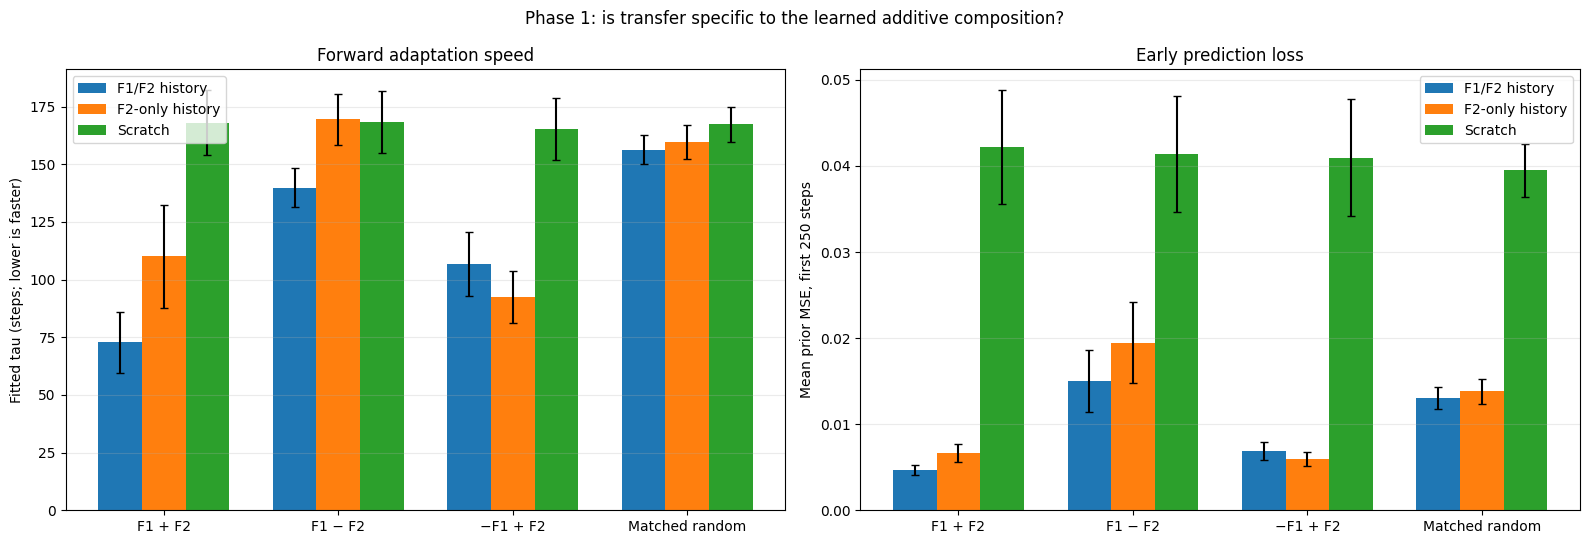

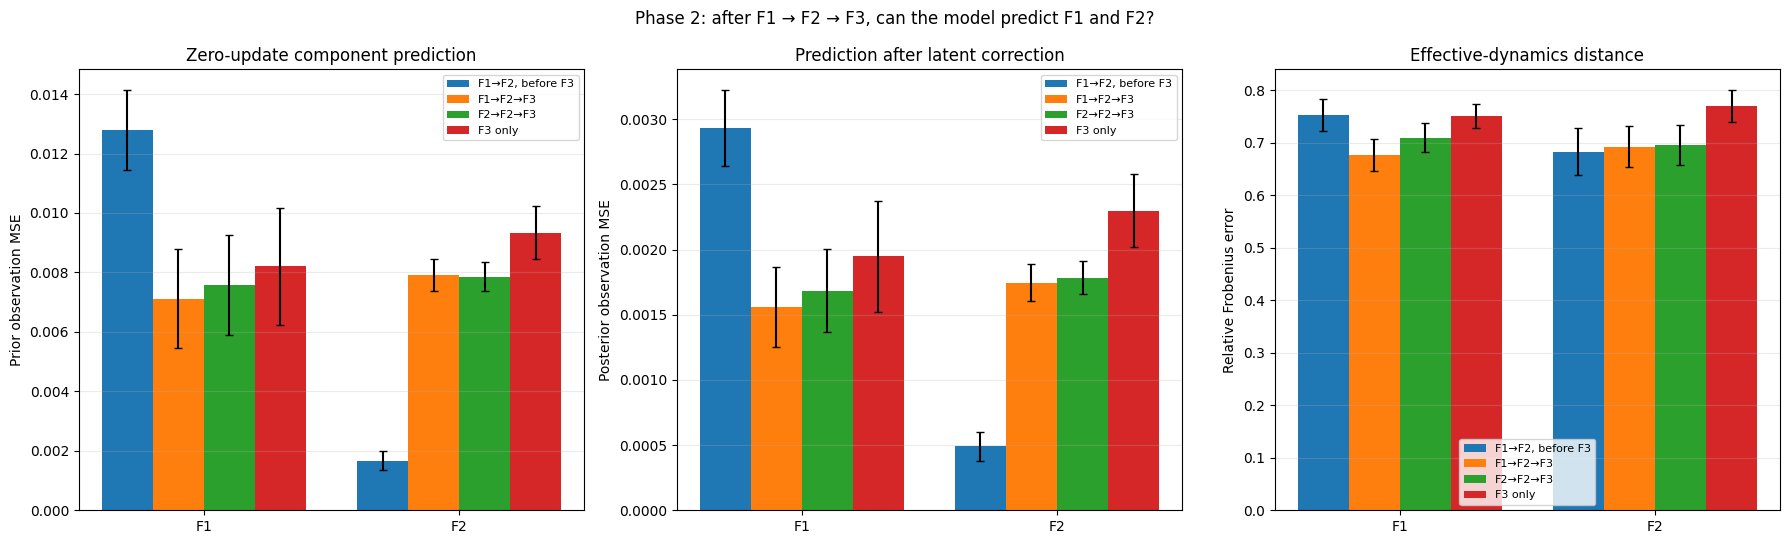

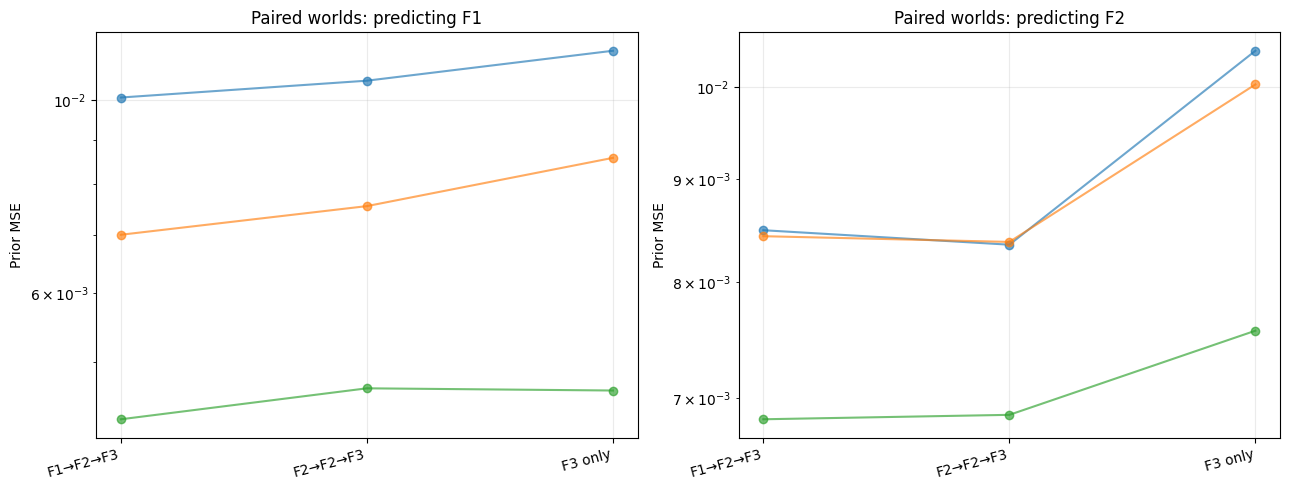

In [ ]:
# ============================================================
# NEXT CELL: specificity + corrected backward-composition test
#
# Phase 1 — forward transfer specificity
#   Pretrain on repeated F1/F2 or matched F2-only history.
#   Then, with all weights still plastic, test adaptation to:
#       F++     = F0 + beta(D1 + D2)      [the true composition]
#       F+-     = F0 + beta(D1 - D2)
#       F-+     = F0 + beta(-D1 + D2)
#       Frandom = F0 + beta(R)            [matched perturbation norm]
#   Scratch is included as a generic-pretraining control.
#
# Phase 2 — corrected backward test
#   One model follows exactly:
#       F1 -> F2 -> F3
#   where each arrow is one full training phase and
#       F3 = F0 + beta(D1 + D2).
#   After the F3 phase, that SAME model is used to predict F1 and F2.
#   There is no additional weight learning on the component probes.
#   Latent predictive-coding inference remains active.
#
#   Matched controls:
#       F2 -> F2 -> F3    (same pretraining duration; lacks D1 history)
#       F3 only           (same F3 exposure; no prior history)
#       F1 -> F2 pre-F3   (retention baseline before composition training)
#
# All comparisons use shared initializations and identical streams.
# Assumes the V9 cell or its helper definitions have already run.
# ============================================================

import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

_REQUIRED_BIDIRECTIONAL = [
    "PCConfig",
    "PredictiveCodingWorldModel",
    "set_seed",
    "_clone_transfer_model",
    "_train_transfer_history",
    "_fit_transfer_curve",
    "_first_half_decay_step",
    "_transfer_ema",
    "_effective_F_transfer",
    "_relative_matrix_error",
    "_spectral_radius",
]
_missing_bidirectional = [
    name for name in _REQUIRED_BIDIRECTIONAL if name not in globals()
]
if _missing_bidirectional:
    raise RuntimeError(
        "Run the predictive-coding architecture and V9 transfer-definition cell first. Missing: "
        + ", ".join(_missing_bidirectional)
    )


def _matrix_fro_inner(left, right):
    return torch.sum(left * right)


def _orthogonal_unit_matrix(raw, basis, eps=1e-8):
    """Frobenius Gram-Schmidt followed by unit Frobenius normalization."""
    value = raw.clone()
    for direction in basis:
        value = value - _matrix_fro_inner(value, direction) * direction
    norm = torch.linalg.matrix_norm(value).clamp_min(eps)
    return value / norm


def _raw_low_rank(dim, rank, device, generator):
    left = torch.randn(dim, rank, device=device, generator=generator)
    right = torch.randn(dim, rank, device=device, generator=generator)
    return (left @ right.T) / math.sqrt(max(rank, 1))


@torch.no_grad()
def _make_bidirectional_world(
    cfg,
    *,
    seed,
    factor_rank=4,
    stability_margin=0.985,
):
    """Construct matched orthogonal factors and all forward-test targets.

    D1 and D2 are Frobenius-orthogonal and unit norm, so D1+D2,
    D1-D2, and -D1+D2 have the same Frobenius norm. R is also
    orthogonal to both factors and scaled to the same perturbation norm.
    One shared beta is selected so every matrix remains stable.
    """
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    # Deterministic stable base with enough room for two factors.
    set_seed(seed + 17)
    base_radius = min(0.66, cfg.dynamics_radius * 0.70)
    F0 = stable_matrix(cfg.state_dim, base_radius, device)

    D1 = _orthogonal_unit_matrix(
        _raw_low_rank(cfg.state_dim, factor_rank, device, generator),
        [],
    )
    D2 = _orthogonal_unit_matrix(
        _raw_low_rank(cfg.state_dim, factor_rank, device, generator),
        [D1],
    )
    R_unit = _orthogonal_unit_matrix(
        _raw_low_rank(cfg.state_dim, factor_rank, device, generator),
        [D1, D2],
    )

    perturbations = {
        "Fpp": D1 + D2,
        "Fpm": D1 - D2,
        "Fmp": -D1 + D2,
        "Frandom": math.sqrt(2.0) * R_unit,
    }

    target_radius = cfg.dynamics_radius * stability_margin

    def candidate_matrices(beta):
        return {
            "F1": F0 + beta * D1,
            "F2": F0 + beta * D2,
            **{
                name: F0 + beta * perturbation
                for name, perturbation in perturbations.items()
            },
        }

    def all_stable(beta):
        return max(
            _spectral_radius(matrix)
            for matrix in candidate_matrices(beta).values()
        ) <= target_radius

    low, high = 0.0, 0.05
    while all_stable(high) and high < 8.0:
        low = high
        high *= 2.0
    for _ in range(60):
        middle = 0.5 * (low + high)
        if all_stable(middle):
            low = middle
        else:
            high = middle

    beta = low * 0.90
    matrices = candidate_matrices(beta)
    F1 = matrices["F1"]
    F2 = matrices["F2"]
    F3 = matrices["Fpp"]

    G = (
        torch.randn(
            cfg.state_dim,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        * cfg.action_scale
    )

    perturbation_norms = {
        name: float(torch.linalg.matrix_norm(value).item())
        for name, value in perturbations.items()
    }
    radii = {
        "F0": _spectral_radius(F0),
        "F1": _spectral_radius(F1),
        "F2": _spectral_radius(F2),
        "F3": _spectral_radius(F3),
        "Fpm": _spectral_radius(matrices["Fpm"]),
        "Fmp": _spectral_radius(matrices["Fmp"]),
        "Frandom": _spectral_radius(matrices["Frandom"]),
    }

    return {
        "F0": F0,
        "D1": D1,
        "D2": D2,
        "R": R_unit,
        "F1": F1,
        "F2": F2,
        "F3": F3,
        "Fpp": F3,
        "Fpm": matrices["Fpm"],
        "Fmp": matrices["Fmp"],
        "Frandom": matrices["Frandom"],
        "G": G,
        "beta": beta,
        "radii": radii,
        "perturbation_norms": perturbation_norms,
    }


@torch.no_grad()
def _run_shared_plastic_target(
    models,
    cfg,
    world,
    target_name,
    *,
    steps,
    seed,
    diagnostic_every=25,
    progress_description=None,
):
    """Fully plastic adaptation of several branches on one identical stream."""
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    F_target = world[target_name]

    x = 0.25 * torch.randn(
        cfg.batch_size,
        cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation = x + cfg.observation_noise * torch.randn(
        x.shape,
        device=device,
        generator=generator,
    )
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)
    z_previous = {
        name: model.infer(observation, zero_z, zero_action)["z"]
        for name, model in models.items()
    }

    history = {
        name: {
            "prior_mse": [],
            "posterior_mse": [],
            "temporal_mse": [],
            "delta_A_rms": [],
            "distance": [],
        }
        for name in models
    }
    latest_distance = {
        name: _relative_matrix_error(_effective_F_transfer(model), F_target)
        for name, model in models.items()
    }
    start_distance = dict(latest_distance)

    progress = tqdm(
        range(steps),
        desc=progress_description or f"adapt to {target_name}",
        unit="step",
        dynamic_ncols=True,
        leave=False,
    )

    for step in progress:
        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        x = (
            x @ F_target.T
            + action @ world["G"].T
            + cfg.process_noise
            * torch.randn(x.shape, device=device, generator=generator)
        )
        observation = x + cfg.observation_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )

        latest = {}
        for name, model in models.items():
            inferred = model.infer(observation, z_previous[name], action)
            stats = model.local_update(
                z=inferred["z"],
                z_previous=z_previous[name],
                action=action,
                observation_error=inferred["observation_error"],
                temporal_error=inferred["temporal_error"],
            )
            z_previous[name] = inferred["z"]

            prior = (
                inferred["prior_observation_prediction"] - observation
            ).square().mean().item()
            posterior = inferred["observation_error"].square().mean().item()
            temporal = inferred["temporal_error"].square().mean().item()

            if step == 0 or (step + 1) % diagnostic_every == 0 or step == steps - 1:
                latest_distance[name] = _relative_matrix_error(
                    _effective_F_transfer(model),
                    F_target,
                )

            history[name]["prior_mse"].append(prior)
            history[name]["posterior_mse"].append(posterior)
            history[name]["temporal_mse"].append(temporal)
            history[name]["delta_A_rms"].append(stats["delta_A_rms"])
            history[name]["distance"].append(latest_distance[name])
            latest[name] = prior

        if step == 0 or (step + 1) % 200 == 0:
            progress.set_postfix(
                **{name: f"{value:.2e}" for name, value in latest.items()}
            )

    return history, start_distance, latest_distance


@torch.no_grad()
def _frozen_component_probe(
    models,
    cfg,
    world,
    component_name,
    *,
    steps,
    burn_in,
    seed,
):
    """Predict a component with weights frozen but latent inference active.

    This prevents F1 evaluation from training the model before F2 is tested.
    All models receive the exact same states, actions, and noise.
    """
    if burn_in >= steps:
        raise ValueError("burn_in must be smaller than steps")

    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    F = world[component_name]

    x = 0.25 * torch.randn(
        cfg.batch_size,
        cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation = x + cfg.observation_noise * torch.randn(
        x.shape,
        device=device,
        generator=generator,
    )
    zero_action = torch.zeros(cfg.batch_size, cfg.action_dim, device=device)
    zero_z = torch.zeros(cfg.batch_size, cfg.latent_dim, device=device)
    z_previous = {
        name: model.infer(observation, zero_z, zero_action)["z"]
        for name, model in models.items()
    }

    traces = {
        name: {"prior_mse": [], "posterior_mse": [], "temporal_mse": []}
        for name in models
    }

    for _ in range(steps):
        action = cfg.action_std * torch.randn(
            cfg.batch_size,
            cfg.action_dim,
            device=device,
            generator=generator,
        )
        x = (
            x @ F.T
            + action @ world["G"].T
            + cfg.process_noise
            * torch.randn(x.shape, device=device, generator=generator)
        )
        observation = x + cfg.observation_noise * torch.randn(
            x.shape,
            device=device,
            generator=generator,
        )

        for name, model in models.items():
            inferred = model.infer(observation, z_previous[name], action)
            z_previous[name] = inferred["z"]
            traces[name]["prior_mse"].append(
                (
                    inferred["prior_observation_prediction"] - observation
                ).square().mean().item()
            )
            traces[name]["posterior_mse"].append(
                inferred["observation_error"].square().mean().item()
            )
            traces[name]["temporal_mse"].append(
                inferred["temporal_error"].square().mean().item()
            )

    summary = {}
    for name, model in models.items():
        prior = np.asarray(traces[name]["prior_mse"], dtype=np.float64)
        posterior = np.asarray(traces[name]["posterior_mse"], dtype=np.float64)
        temporal = np.asarray(traces[name]["temporal_mse"], dtype=np.float64)
        prior_eval = prior[burn_in:]
        posterior_eval = posterior[burn_in:]
        temporal_eval = temporal[burn_in:]
        summary[name] = {
            "prior_mse": float(np.mean(prior_eval)),
            "posterior_mse": float(np.mean(posterior_eval)),
            "temporal_mse": float(np.mean(temporal_eval)),
            "inference_reduction": float(
                1.0 - np.mean(posterior_eval) / max(np.mean(prior_eval), 1e-12)
            ),
            "structural_distance": _relative_matrix_error(
                _effective_F_transfer(model),
                F,
            ),
            "prior_trace": prior,
            "posterior_trace": posterior,
        }
    return summary


def _aggregate_mean_sem(values):
    array = np.asarray(values, dtype=np.float64)
    return float(np.mean(array)), float(
        np.std(array, ddof=1) / math.sqrt(len(array)) if len(array) > 1 else 0.0
    )


@torch.no_grad()
def run_bidirectional_composition_experiment(
    base_cfg,
    *,
    num_worlds=3,
    phase1_pretrain_steps=800,
    phase1_pretrain_cycles=2,
    phase1_target_steps=1000,
    phase1_auc_steps=250,
    phase2_steps_per_regime=1000,
    component_probe_steps=400,
    component_probe_burn_in=50,
    factor_rank=4,
    smoothing_span=25,
    seed_offset=31000,
):
    """Run forward specificity and corrected F1->F2->F3 backward prediction."""
    if num_worlds < 1:
        raise ValueError("num_worlds must be positive")
    if min(phase1_pretrain_steps, phase1_target_steps, phase2_steps_per_regime) < 100:
        raise ValueError("training phases must be at least 100 steps")

    cfg = copy.deepcopy(base_cfg)
    cfg.shift_step = None
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.validate()

    targets = ("Fpp", "Fpm", "Fmp", "Frandom")
    branches = ("history", "F2_only", "scratch")
    phase1_world_results = []
    phase2_world_results = []

    outer = tqdm(
        range(num_worlds),
        desc="bidirectional composition worlds",
        unit="world",
        dynamic_ncols=True,
    )

    for world_index in outer:
        world_seed = cfg.seed + seed_offset + 1000 * world_index
        set_seed(world_seed)
        world = _make_bidirectional_world(
            cfg,
            seed=world_seed + 1,
            factor_rank=factor_rank,
        )

        # ----------------------------------------------------
        # PHASE 1: specificity across composition/sign/random targets
        # ----------------------------------------------------
        set_seed(world_seed + 2)
        initial = PredictiveCodingWorldModel(cfg)
        history_checkpoint = _clone_transfer_model(cfg, initial)
        F2_checkpoint = _clone_transfer_model(cfg, initial)
        scratch_checkpoint = _clone_transfer_model(cfg, initial)

        alternating_schedule = tuple(
            regime
            for _ in range(phase1_pretrain_cycles)
            for regime in (1, 2)
        )
        F2_schedule = tuple(2 for _ in alternating_schedule)
        shared_pretrain_seed = world_seed + 10

        _train_transfer_history(
            history_checkpoint,
            cfg,
            world,
            alternating_schedule,
            steps_per_phase=phase1_pretrain_steps,
            seed=shared_pretrain_seed,
            description=f"world {world_index + 1}: F1/F2 history",
        )
        _train_transfer_history(
            F2_checkpoint,
            cfg,
            world,
            F2_schedule,
            steps_per_phase=phase1_pretrain_steps,
            seed=shared_pretrain_seed,
            description=f"world {world_index + 1}: F2-only history",
        )

        phase1_metrics = {}
        for target_index, target_name in enumerate(targets):
            test_models = {
                "history": _clone_transfer_model(cfg, history_checkpoint),
                "F2_only": _clone_transfer_model(cfg, F2_checkpoint),
                "scratch": _clone_transfer_model(cfg, scratch_checkpoint),
            }
            history, start_distance, final_distance = _run_shared_plastic_target(
                test_models,
                cfg,
                world,
                target_name,
                steps=phase1_target_steps,
                seed=world_seed + 100 + target_index,
                progress_description=(
                    f"world {world_index + 1}: adapt {target_name}"
                ),
            )

            target_rows = {}
            auc_count = min(phase1_auc_steps, phase1_target_steps)
            tail = max(25, phase1_target_steps // 10)
            for branch_name in branches:
                curve = np.asarray(
                    history[branch_name]["prior_mse"],
                    dtype=np.float64,
                )
                posterior = np.asarray(
                    history[branch_name]["posterior_mse"],
                    dtype=np.float64,
                )
                fit = _fit_transfer_curve(curve, smoothing_span=smoothing_span)
                target_rows[branch_name] = {
                    **fit,
                    "early_auc": float(np.mean(curve[:auc_count])),
                    "final_prior": float(np.mean(curve[-tail:])),
                    "final_posterior": float(np.mean(posterior[-tail:])),
                    "half_step": _first_half_decay_step(
                        curve,
                        fit["E0"],
                        fit["E_inf"],
                    ),
                    "start_distance": start_distance[branch_name],
                    "final_distance": final_distance[branch_name],
                }
            phase1_metrics[target_name] = target_rows

        phase1_world_results.append(
            {
                "world_seed": world_seed,
                "metrics": phase1_metrics,
                "radii": world["radii"],
                "perturbation_norms": world["perturbation_norms"],
            }
        )

        # ----------------------------------------------------
        # PHASE 2: exact chain F1 -> F2 -> F3, then predict F1/F2
        # ----------------------------------------------------
        set_seed(world_seed + 500)
        phase2_initial = PredictiveCodingWorldModel(cfg)

        chain_pre_F3 = _clone_transfer_model(cfg, phase2_initial)
        matched_F2 = _clone_transfer_model(cfg, phase2_initial)
        F3_only = _clone_transfer_model(cfg, phase2_initial)

        shared_chain_seed = world_seed + 510
        # Exactly one F1 -> F2 cycle.
        _train_transfer_history(
            chain_pre_F3,
            cfg,
            world,
            (1, 2),
            steps_per_phase=phase2_steps_per_regime,
            seed=shared_chain_seed,
            description=f"world {world_index + 1}: F1 -> F2",
        )
        # Matched history duration, but no D1 exposure.
        _train_transfer_history(
            matched_F2,
            cfg,
            world,
            (2, 2),
            steps_per_phase=phase2_steps_per_regime,
            seed=shared_chain_seed,
            description=f"world {world_index + 1}: F2 -> F2 control",
        )

        # Preserve the exact pre-F3 model for retention comparison.
        pre_F3_retention = _clone_transfer_model(cfg, chain_pre_F3)
        chain_post_F3 = _clone_transfer_model(cfg, chain_pre_F3)
        F2_post_F3 = _clone_transfer_model(cfg, matched_F2)

        F3_models = {
            "chain_post_F3": chain_post_F3,
            "F2_post_F3": F2_post_F3,
            "F3_only": F3_only,
        }
        _run_shared_plastic_target(
            F3_models,
            cfg,
            world,
            "F3",
            steps=phase2_steps_per_regime,
            seed=world_seed + 520,
            progress_description=f"world {world_index + 1}: one F3 cycle",
        )

        probe_models = {
            "pre_F3_chain": pre_F3_retention,
            "chain_post_F3": chain_post_F3,
            "F2_post_F3": F2_post_F3,
            "F3_only": F3_only,
        }
        component_results = {}
        for component_index, component_name in enumerate(("F1", "F2")):
            component_results[component_name] = _frozen_component_probe(
                probe_models,
                cfg,
                world,
                component_name,
                steps=component_probe_steps,
                burn_in=component_probe_burn_in,
                seed=world_seed + 600 + component_index,
            )

        phase2_world_results.append(
            {
                "world_seed": world_seed,
                "component_results": component_results,
                "radii": world["radii"],
            }
        )

        outer.set_postfix(
            Fpp_tau=f"{phase1_metrics['Fpp']['history']['tau']:.1f}",
            back_F1=f"{component_results['F1']['chain_post_F3']['prior_mse']:.2e}",
            back_F2=f"{component_results['F2']['chain_post_F3']['prior_mse']:.2e}",
        )

    result = {
        "config": cfg,
        "num_worlds": num_worlds,
        "targets": targets,
        "branches": branches,
        "phase1_world_results": phase1_world_results,
        "phase2_world_results": phase2_world_results,
        "phase1_auc_steps": phase1_auc_steps,
        "phase1_target_steps": phase1_target_steps,
        "phase2_steps_per_regime": phase2_steps_per_regime,
        "component_probe_steps": component_probe_steps,
        "component_probe_burn_in": component_probe_burn_in,
        "labels": {
            "history": "F1/F2 history",
            "F2_only": "F2-only history",
            "scratch": "Scratch",
            "pre_F3_chain": "F1→F2, before F3",
            "chain_post_F3": "F1→F2→F3",
            "F2_post_F3": "F2→F2→F3",
            "F3_only": "F3 only",
            "Fpp": "F1 + F2",
            "Fpm": "F1 − F2",
            "Fmp": "−F1 + F2",
            "Frandom": "Matched random",
        },
    }
    return result


def summarize_bidirectional_composition(result):
    labels = result["labels"]
    worlds1 = result["phase1_world_results"]
    worlds2 = result["phase2_world_results"]

    print("\nPHASE 1 — forward transfer specificity")
    print("=" * 108)
    print(
        "Mean ± SEM across independently generated worlds. Lower tau and early AUC are better."
    )
    print("-" * 108)
    print(
        f"{'Target':<18s} {'Branch':<18s} {'tau':>18s} {'early AUC':>18s} "
        f"{'final prior':>18s}"
    )
    print("-" * 108)
    for target in result["targets"]:
        for branch in result["branches"]:
            tau = _aggregate_mean_sem(
                [w["metrics"][target][branch]["tau"] for w in worlds1]
            )
            auc = _aggregate_mean_sem(
                [w["metrics"][target][branch]["early_auc"] for w in worlds1]
            )
            final = _aggregate_mean_sem(
                [w["metrics"][target][branch]["final_prior"] for w in worlds1]
            )
            print(
                f"{labels[target]:<18s} {labels[branch]:<18s} "
                f"{tau[0]:>8.1f} ± {tau[1]:<7.1f} "
                f"{auc[0]:>8.5f} ± {auc[1]:<7.5f} "
                f"{final[0]:>8.6f} ± {final[1]:<7.6f}"
            )
        print("-" * 108)

    history_tau = np.asarray(
        [w["metrics"]["Fpp"]["history"]["tau"] for w in worlds1]
    )
    F2_tau = np.asarray(
        [w["metrics"]["Fpp"]["F2_only"]["tau"] for w in worlds1]
    )
    random_history_tau = np.asarray(
        [w["metrics"]["Frandom"]["history"]["tau"] for w in worlds1]
    )
    print(
        f"F++ history speedup over F2-only: mean {np.mean(F2_tau / history_tau):.2f}x"
    )
    print(
        "Composition specificity check: history tau on F++ versus matched random = "
        f"{np.mean(history_tau):.1f} vs {np.mean(random_history_tau):.1f} steps"
    )

    print("\nPHASE 2 — corrected backward prediction after F1 → F2 → F3")
    print("=" * 108)
    print(
        "Weights are frozen only during the component probes; latent predictive-coding inference remains active."
    )
    print("-" * 108)
    print(
        f"{'Component':<12s} {'Model history':<22s} {'prior MSE':>20s} "
        f"{'posterior MSE':>20s} {'dynamics distance':>20s}"
    )
    print("-" * 108)
    phase2_models = ("pre_F3_chain", "chain_post_F3", "F2_post_F3", "F3_only")
    for component in ("F1", "F2"):
        for model_name in phase2_models:
            prior = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["prior_mse"]
                    for w in worlds2
                ]
            )
            posterior = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["posterior_mse"]
                    for w in worlds2
                ]
            )
            distance = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["structural_distance"]
                    for w in worlds2
                ]
            )
            print(
                f"{component:<12s} {labels[model_name]:<22s} "
                f"{prior[0]:>9.6f} ± {prior[1]:<8.6f} "
                f"{posterior[0]:>9.6f} ± {posterior[1]:<8.6f} "
                f"{distance[0]:>8.3f} ± {distance[1]:<7.3f}"
            )
        print("-" * 108)

    for component in ("F1", "F2"):
        chain = np.asarray(
            [
                w["component_results"][component]["chain_post_F3"]["prior_mse"]
                for w in worlds2
            ]
        )
        F2_control = np.asarray(
            [
                w["component_results"][component]["F2_post_F3"]["prior_mse"]
                for w in worlds2
            ]
        )
        F3_only = np.asarray(
            [
                w["component_results"][component]["F3_only"]["prior_mse"]
                for w in worlds2
            ]
        )
        pre = np.asarray(
            [
                w["component_results"][component]["pre_F3_chain"]["prior_mse"]
                for w in worlds2
            ]
        )
        print(
            f"{component}: F1→F2→F3 improvement vs F2→F2→F3 = "
            f"{(1.0 - np.mean(chain) / max(np.mean(F2_control), 1e-12)) * 100.0:.1f}%"
        )
        print(
            f"{component}: F1→F2→F3 improvement vs F3-only = "
            f"{(1.0 - np.mean(chain) / max(np.mean(F3_only), 1e-12)) * 100.0:.1f}%"
        )
        print(
            f"{component}: change caused by the F3 phase relative to pre-F3 chain = "
            f"{(np.mean(chain) / max(np.mean(pre), 1e-12) - 1.0) * 100.0:+.1f}%"
        )


def plot_bidirectional_composition(result):
    labels = result["labels"]
    worlds1 = result["phase1_world_results"]
    worlds2 = result["phase2_world_results"]
    targets = result["targets"]
    branches = result["branches"]

    # Phase 1 aggregated tau and early AUC.
    x = np.arange(len(targets))
    width = 0.25
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
    for branch_index, branch in enumerate(branches):
        tau_means, tau_sems, auc_means, auc_sems = [], [], [], []
        for target in targets:
            mean, sem = _aggregate_mean_sem(
                [w["metrics"][target][branch]["tau"] for w in worlds1]
            )
            tau_means.append(mean)
            tau_sems.append(sem)
            mean, sem = _aggregate_mean_sem(
                [w["metrics"][target][branch]["early_auc"] for w in worlds1]
            )
            auc_means.append(mean)
            auc_sems.append(sem)
        offset = (branch_index - 1) * width
        axes[0].bar(
            x + offset,
            tau_means,
            width,
            yerr=tau_sems,
            capsize=3,
            label=labels[branch],
        )
        axes[1].bar(
            x + offset,
            auc_means,
            width,
            yerr=auc_sems,
            capsize=3,
            label=labels[branch],
        )

    for axis, title, ylabel in (
        (axes[0], "Forward adaptation speed", "Fitted tau (steps; lower is faster)"),
        (
            axes[1],
            "Early prediction loss",
            f"Mean prior MSE, first {result['phase1_auc_steps']} steps",
        ),
    ):
        axis.set_xticks(x)
        axis.set_xticklabels([labels[target] for target in targets])
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
        axis.legend()
    fig.suptitle("Phase 1: is transfer specific to the learned additive composition?")
    fig.tight_layout()
    plt.show()

    # Phase 2 backward component prediction.
    models = ("pre_F3_chain", "chain_post_F3", "F2_post_F3", "F3_only")
    components = ("F1", "F2")
    x = np.arange(len(components))
    width = 0.20
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    for model_index, model_name in enumerate(models):
        prior_means, prior_sems = [], []
        posterior_means, posterior_sems = [], []
        distance_means, distance_sems = [], []
        for component in components:
            mean, sem = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["prior_mse"]
                    for w in worlds2
                ]
            )
            prior_means.append(mean)
            prior_sems.append(sem)
            mean, sem = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["posterior_mse"]
                    for w in worlds2
                ]
            )
            posterior_means.append(mean)
            posterior_sems.append(sem)
            mean, sem = _aggregate_mean_sem(
                [
                    w["component_results"][component][model_name]["structural_distance"]
                    for w in worlds2
                ]
            )
            distance_means.append(mean)
            distance_sems.append(sem)

        offset = (model_index - 1.5) * width
        axes[0].bar(
            x + offset,
            prior_means,
            width,
            yerr=prior_sems,
            capsize=3,
            label=labels[model_name],
        )
        axes[1].bar(
            x + offset,
            posterior_means,
            width,
            yerr=posterior_sems,
            capsize=3,
            label=labels[model_name],
        )
        axes[2].bar(
            x + offset,
            distance_means,
            width,
            yerr=distance_sems,
            capsize=3,
            label=labels[model_name],
        )

    titles = (
        "Zero-update component prediction",
        "Prediction after latent correction",
        "Effective-dynamics distance",
    )
    ylabels = (
        "Prior observation MSE",
        "Posterior observation MSE",
        "Relative Frobenius error",
    )
    for axis, title, ylabel in zip(axes, titles, ylabels):
        axis.set_xticks(x)
        axis.set_xticklabels(components)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
        axis.legend(fontsize=8)
    fig.suptitle("Phase 2: after F1 → F2 → F3, can the model predict F1 and F2?")
    fig.tight_layout()
    plt.show()

    # Per-world paired comparison: post-F3 chain vs matched controls.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for axis, component in zip(axes, components):
        chain = [
            w["component_results"][component]["chain_post_F3"]["prior_mse"]
            for w in worlds2
        ]
        F2_control = [
            w["component_results"][component]["F2_post_F3"]["prior_mse"]
            for w in worlds2
        ]
        F3_only = [
            w["component_results"][component]["F3_only"]["prior_mse"]
            for w in worlds2
        ]
        for index in range(len(worlds2)):
            axis.plot(
                [0, 1, 2],
                [chain[index], F2_control[index], F3_only[index]],
                marker="o",
                alpha=0.65,
            )
        axis.set_xticks([0, 1, 2])
        axis.set_xticklabels(
            [labels["chain_post_F3"], labels["F2_post_F3"], labels["F3_only"]],
            rotation=15,
            ha="right",
        )
        axis.set_yscale("log")
        axis.set_ylabel("Prior MSE")
        axis.set_title(f"Paired worlds: predicting {component}")
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


# -------------------------
# Run the experiment
# -------------------------
# Debug: 1 world, 200/1/300 steps, phase2=300, batch_size=256.
# Evidence run: set NUM_WORLDS=20 after the cell works.
BIDIRECTIONAL_NUM_WORLDS = 3
BIDIRECTIONAL_PHASE1_PRETRAIN_STEPS = 800
BIDIRECTIONAL_PHASE1_PRETRAIN_CYCLES = 2
BIDIRECTIONAL_PHASE1_TARGET_STEPS = 1000
BIDIRECTIONAL_PHASE1_AUC_STEPS = 250
BIDIRECTIONAL_PHASE2_STEPS_PER_REGIME = 1000
BIDIRECTIONAL_COMPONENT_PROBE_STEPS = 400
BIDIRECTIONAL_COMPONENT_PROBE_BURN_IN = 50
BIDIRECTIONAL_FACTOR_RANK = 4

if "transfer_cfg" in globals():
    bidirectional_cfg = copy.deepcopy(transfer_cfg)
elif "switch_cfg" in globals():
    bidirectional_cfg = copy.deepcopy(switch_cfg)
elif "cfg" in globals() and isinstance(cfg, PCConfig):
    bidirectional_cfg = copy.deepcopy(cfg)
else:
    bidirectional_cfg = PCConfig()

bidirectional_cfg.mixed_observations = False
bidirectional_cfg.obs_dim = bidirectional_cfg.state_dim
bidirectional_cfg.latent_dim = bidirectional_cfg.state_dim
bidirectional_cfg.visualize = False
bidirectional_cfg.record_checkpoints = False
bidirectional_cfg.shift_step = None
bidirectional_cfg.validate()

bidirectional_composition_result = run_bidirectional_composition_experiment(
    bidirectional_cfg,
    num_worlds=BIDIRECTIONAL_NUM_WORLDS,
    phase1_pretrain_steps=BIDIRECTIONAL_PHASE1_PRETRAIN_STEPS,
    phase1_pretrain_cycles=BIDIRECTIONAL_PHASE1_PRETRAIN_CYCLES,
    phase1_target_steps=BIDIRECTIONAL_PHASE1_TARGET_STEPS,
    phase1_auc_steps=BIDIRECTIONAL_PHASE1_AUC_STEPS,
    phase2_steps_per_regime=BIDIRECTIONAL_PHASE2_STEPS_PER_REGIME,
    component_probe_steps=BIDIRECTIONAL_COMPONENT_PROBE_STEPS,
    component_probe_burn_in=BIDIRECTIONAL_COMPONENT_PROBE_BURN_IN,
    factor_rank=BIDIRECTIONAL_FACTOR_RANK,
)

summarize_bidirectional_composition(bidirectional_composition_result)
plot_bidirectional_composition(bidirectional_composition_result)

packed pretraining: first cycle:   0%|          | 0/1200 [00:00<?, ?step/s]

packed pretraining: second cycle:   0%|          | 0/1200 [00:00<?, ?step/s]

fixed-checkpoint update fields:   0%|          | 0/160 [00:00<?, ?it/s]

packed F3 + random adaptation:   0%|          | 0/800 [00:00<?, ?step/s]

frozen component probes:   0%|          | 0/240 [00:00<?, ?it/s]


V11 — batched 20-world composition mechanism test
worlds=20 | per-world batch=96 | inference steps=8 | elapsed=16.0s
spectral radius mean: F0=0.644, F1=0.758, F2=0.733, F3=0.831, random=0.796

PHASE 1 — forward transfer and matched-random specificity
----------------------------------------------------------------------------------------------------------------
Target     Branch                      tau          early AUC        final prior
----------------------------------------------------------------------------------------------------------------
F3         history          69.1 ± 6.4       0.00721 ± 0.00064  0.002195 ± 0.000120
F3         F2_only         105.8 ± 8.8       0.00972 ± 0.00099  0.002702 ± 0.000197
F3         scratch         217.2 ± 4.4       0.05562 ± 0.00268  0.007022 ± 0.000324
random     history         153.5 ± 6.4       0.01806 ± 0.00181  0.003112 ± 0.000203
random     F2_only         159.2 ± 6.6       0.01931 ± 0.00198  0.003302 ± 0.000223
random     scratch   

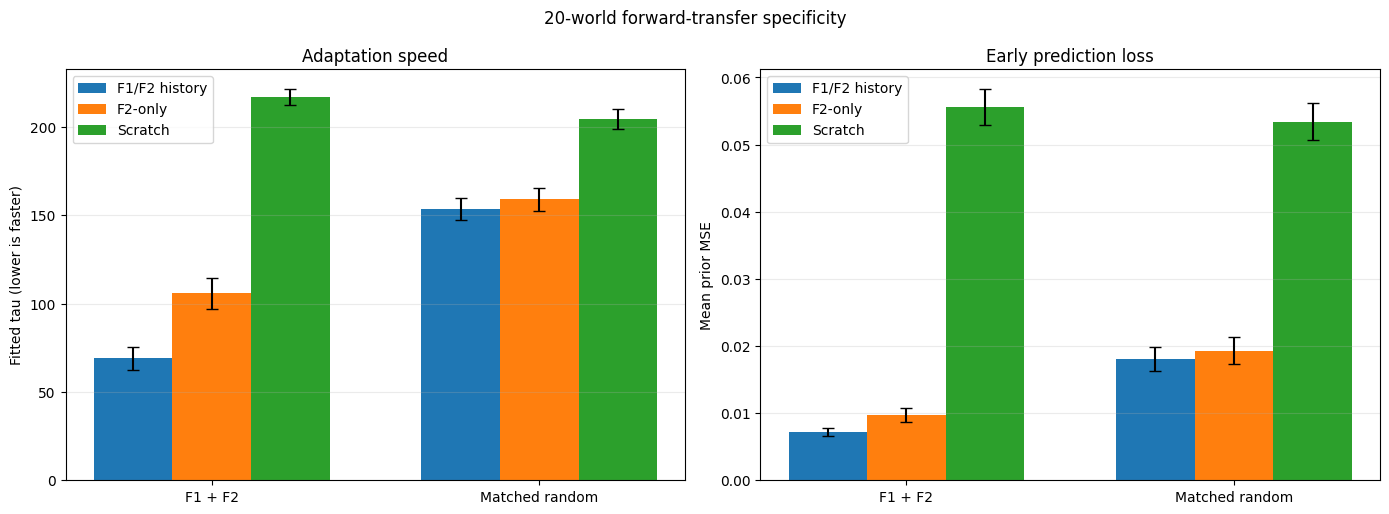

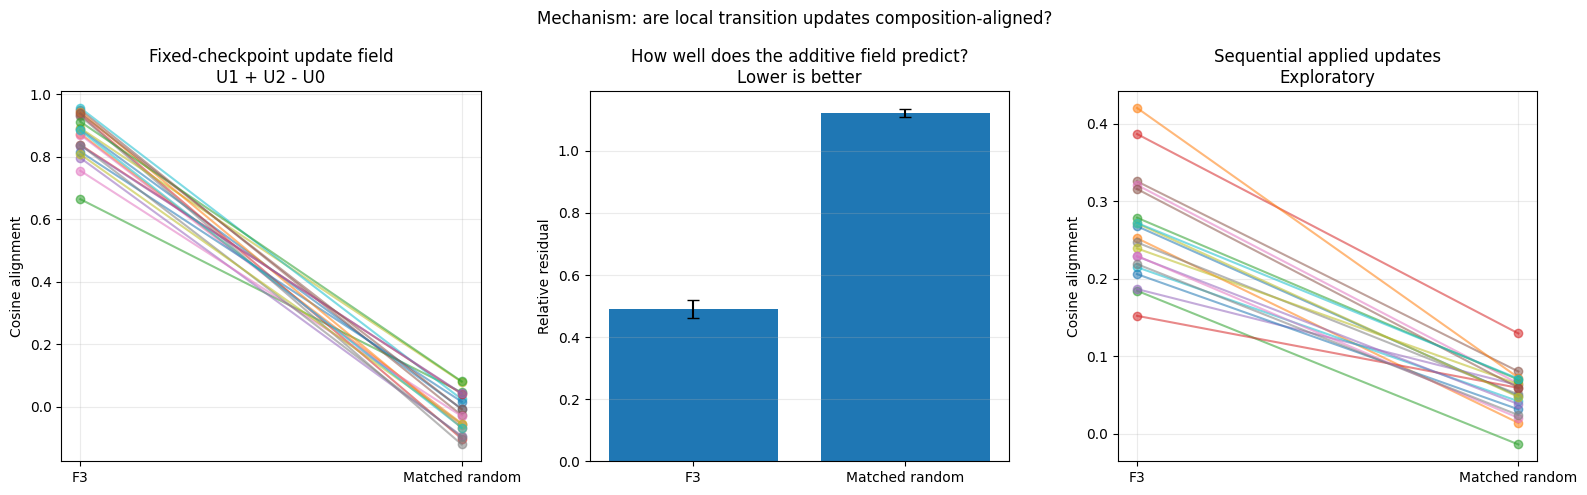

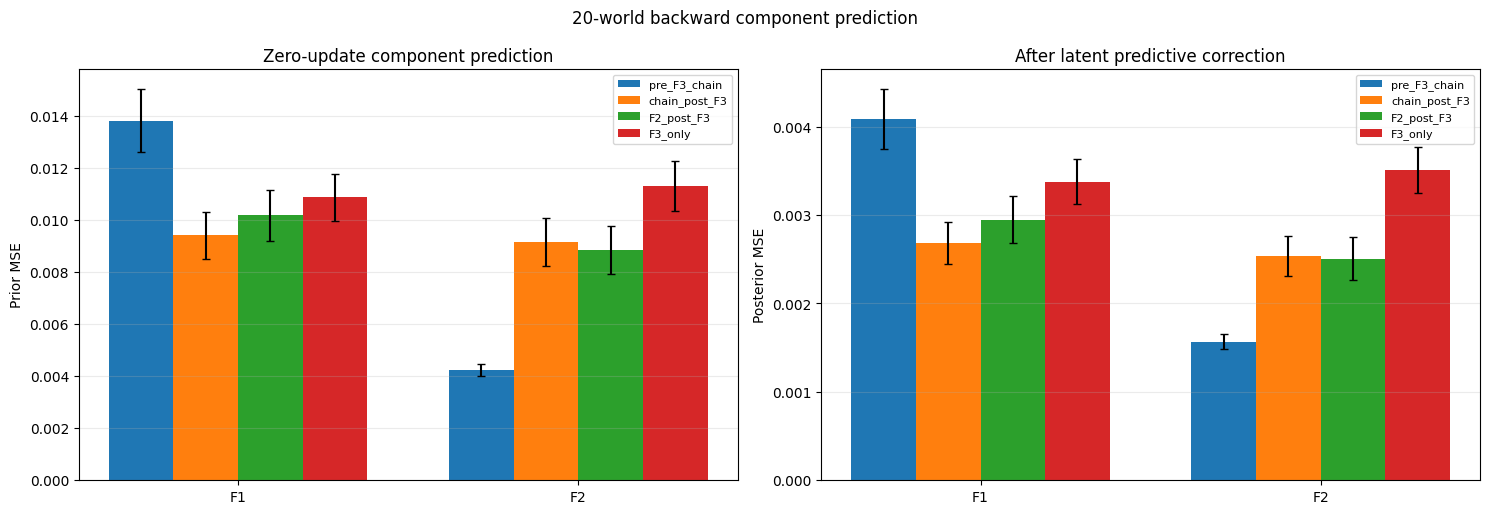

In [ ]:
# ============================================================
# V11 — T4-optimized 20-world composition mechanism test
#
# This cell tensorizes independent worlds and model branches so the T4
# runs them in parallel rather than looping over worlds in Python.
#
# It tests three claims:
#   1) Forward transfer:
#        repeated F1/F2 history learns F3 = F0 + beta(D1 + D2)
#        faster than F2-only history and scratch, but should not gain the
#        same advantage on a Frobenius-matched random target.
#   2) Backward prediction:
#        after F1 -> F2 -> F3, frozen weights are probed on F1 and F2.
#   3) Mechanism:
#        at one fixed post-history checkpoint, measure the actual local
#        transition-weight update fields U0,U1,U2,U3,UR and test
#
#          U3  approximately  U1 + U2 - U0
#
#        The subtraction of U0 is required because F1 and F2 both include
#        the shared base dynamics F0. U1 + U2 alone double-counts F0.
#
# Learning remains strictly local:
#   delta A = temporal_precision * e_z^T z_previous / batch
# No autograd or optimizer is used.
#
# Assumes an earlier architecture cell defined PCConfig.
# ============================================================

import copy
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

try:
    from scipy.optimize import curve_fit
    from scipy.stats import ttest_rel
except ImportError as exc:
    raise RuntimeError("SciPy is required for curve fitting and paired tests.") from exc

if "PCConfig" not in globals():
    raise RuntimeError("Run the predictive-coding architecture cell first; PCConfig is missing.")


# -------------------------
# Small numerical utilities
# -------------------------

def _v11_ema(values, span=21):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return values
    alpha = 2.0 / (span + 1.0)
    output = np.empty_like(values)
    output[0] = values[0]
    for index in range(1, len(values)):
        output[index] = alpha * values[index] + (1.0 - alpha) * output[index - 1]
    return output


def _v11_exp_curve(step, floor, amplitude, tau):
    return floor + amplitude * np.exp(-step / tau)


def _v11_fit_curve(values, smoothing_span=21):
    y = _v11_ema(values, smoothing_span)
    x = np.arange(len(y), dtype=np.float64)
    if len(y) < 30 or not np.all(np.isfinite(y)):
        return {"E0": np.nan, "E_inf": np.nan, "tau": np.nan, "r2": np.nan}

    tail = max(20, len(y) // 8)
    floor0 = max(float(np.median(y[-tail:])), 1e-12)
    amplitude0 = max(float(y[0] - floor0), 1e-12)
    tau0 = max(10.0, len(y) / 4.0)
    try:
        parameters, _ = curve_fit(
            _v11_exp_curve,
            x,
            y,
            p0=(floor0, amplitude0, tau0),
            bounds=(
                (0.0, 0.0, 1.0),
                (
                    max(float(y.max()) * 2.0, 1e-8),
                    max(float(y.max()) * 4.0, 1e-8),
                    len(y) * 30.0,
                ),
            ),
            maxfev=20000,
        )
        fitted = _v11_exp_curve(x, *parameters)
        residual = float(np.sum((y - fitted) ** 2))
        total = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - residual / max(total, 1e-12)
        floor, amplitude, tau = (float(value) for value in parameters)
        return {"E0": floor + amplitude, "E_inf": floor, "tau": tau, "r2": r2}
    except Exception:
        return {"E0": float(y[0]), "E_inf": float(np.median(y[-tail:])), "tau": np.nan, "r2": np.nan}


def _v11_mean_sem(values):
    array = np.asarray(values, dtype=np.float64)
    finite = array[np.isfinite(array)]
    if finite.size == 0:
        return np.nan, np.nan
    mean = float(finite.mean())
    sem = float(finite.std(ddof=1) / math.sqrt(len(finite))) if len(finite) > 1 else 0.0
    return mean, sem


def _v11_cosine(left, right, eps=1e-12):
    left_flat = left.flatten(start_dim=-2)
    right_flat = right.flatten(start_dim=-2)
    numerator = torch.sum(left_flat * right_flat, dim=-1)
    denominator = left_flat.norm(dim=-1) * right_flat.norm(dim=-1)
    return numerator / denominator.clamp_min(eps)


def _v11_relative_residual(target, prediction, eps=1e-12):
    return (target - prediction).flatten(start_dim=-2).norm(dim=-1) / target.flatten(start_dim=-2).norm(dim=-1).clamp_min(eps)


# -------------------------
# Batched additive worlds
# -------------------------

def _v11_low_rank(rng, dim, rank):
    left = rng.standard_normal((dim, rank), dtype=np.float32)
    right = rng.standard_normal((dim, rank), dtype=np.float32)
    return (left @ right.T) / math.sqrt(max(rank, 1))


def _v11_unit_frobenius(matrix, basis=()):
    value = matrix.astype(np.float64, copy=True)
    for direction in basis:
        value -= np.sum(value * direction) * direction
    norm = np.linalg.norm(value)
    if norm < 1e-10:
        raise RuntimeError("Degenerate factor generated; change the seed.")
    return (value / norm).astype(np.float32)


def _v11_spectral_radius_numpy(matrix):
    return float(np.max(np.abs(np.linalg.eigvals(matrix.astype(np.float64)))))


def _v11_make_worlds(
    cfg,
    *,
    num_worlds,
    seed,
    factor_rank=4,
    stability_margin=0.985,
):
    """Generate exact additive worlds on CPU, then transfer once to the GPU."""
    dim = cfg.state_dim
    action_dim = cfg.action_dim
    target_radius = cfg.dynamics_radius * stability_margin
    base_radius = min(0.66, cfg.dynamics_radius * 0.70)

    F0_all, D1_all, D2_all, R_all, G_all, beta_all = [], [], [], [], [], []
    radii = []

    for world_index in range(num_worlds):
        rng = np.random.default_rng(seed + 1009 * world_index)

        raw_base = rng.standard_normal((dim, dim), dtype=np.float32)
        raw_radius = _v11_spectral_radius_numpy(raw_base)
        F0 = raw_base * (base_radius / max(raw_radius, 1e-8))

        D1 = _v11_unit_frobenius(_v11_low_rank(rng, dim, factor_rank))
        D2 = _v11_unit_frobenius(_v11_low_rank(rng, dim, factor_rank), (D1,))
        R = _v11_unit_frobenius(_v11_low_rank(rng, dim, factor_rank), (D1, D2))

        perturbations = (D1, D2, D1 + D2, math.sqrt(2.0) * R)

        low, high = 0.0, 8.0
        for _ in range(42):
            middle = 0.5 * (low + high)
            maximum_radius = max(
                _v11_spectral_radius_numpy(F0 + middle * perturbation)
                for perturbation in perturbations
            )
            if maximum_radius <= target_radius:
                low = middle
            else:
                high = middle
        beta = 0.90 * low

        F1 = F0 + beta * D1
        F2 = F0 + beta * D2
        F3 = F0 + beta * (D1 + D2)
        Fr = F0 + beta * math.sqrt(2.0) * R
        G = rng.standard_normal((dim, action_dim), dtype=np.float32) * cfg.action_scale

        F0_all.append(F0)
        D1_all.append(D1)
        D2_all.append(D2)
        R_all.append(R)
        G_all.append(G)
        beta_all.append(beta)
        radii.append([
            _v11_spectral_radius_numpy(F0),
            _v11_spectral_radius_numpy(F1),
            _v11_spectral_radius_numpy(F2),
            _v11_spectral_radius_numpy(F3),
            _v11_spectral_radius_numpy(Fr),
        ])

    device = torch.device(cfg.device)
    F0 = torch.tensor(np.stack(F0_all), device=device, dtype=torch.float32)
    D1 = torch.tensor(np.stack(D1_all), device=device, dtype=torch.float32)
    D2 = torch.tensor(np.stack(D2_all), device=device, dtype=torch.float32)
    R = torch.tensor(np.stack(R_all), device=device, dtype=torch.float32)
    beta = torch.tensor(np.asarray(beta_all), device=device, dtype=torch.float32)
    beta_matrix = beta[:, None, None]

    return {
        "F0": F0,
        "F1": F0 + beta_matrix * D1,
        "F2": F0 + beta_matrix * D2,
        "F3": F0 + beta_matrix * (D1 + D2),
        "Frandom": F0 + beta_matrix * math.sqrt(2.0) * R,
        "D1": D1,
        "D2": D2,
        "R": R,
        "G": torch.tensor(np.stack(G_all), device=device, dtype=torch.float32),
        "beta": beta,
        "radii": np.asarray(radii, dtype=np.float64),
    }


# -------------------------
# Packed predictive coding
# -------------------------

def _v11_initial_checkpoint(cfg, num_worlds, seed):
    device = torch.device(cfg.device)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    dim = cfg.state_dim
    W = torch.eye(dim, device=device, dtype=torch.float32).expand(num_worlds, dim, dim).clone()
    W.add_(0.08 * torch.randn(W.shape, device=device, generator=generator))
    return {
        "A": torch.zeros(num_worlds, dim, dim, device=device),
        "B": torch.zeros(num_worlds, dim, cfg.action_dim, device=device),
        "W": W,
    }


def _v11_expand_checkpoint(checkpoint, branches):
    return {
        name: tensor[:, None].expand(-1, branches, *tensor.shape[1:]).clone()
        for name, tensor in checkpoint.items()
    }


def _v11_extract_branch(weights, branch):
    return {name: tensor[:, branch].clone() for name, tensor in weights.items()}


def _v11_stack_checkpoints(checkpoints):
    return {
        name: torch.stack([checkpoint[name] for checkpoint in checkpoints], dim=1)
        for name in ("A", "B", "W")
    }


@torch.no_grad()
def _v11_infer(weights, observation, z_previous, action, cfg):
    amp_enabled = bool(cfg.use_amp and observation.device.type == "cuda")
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=amp_enabled,
    ):
        z_prediction = (
            torch.matmul(z_previous, weights["A"].transpose(-1, -2))
            + torch.matmul(action, weights["B"].transpose(-1, -2))
        )
        prior_prediction = torch.matmul(z_prediction, weights["W"].transpose(-1, -2))
        z = z_prediction.clone()
        for _ in range(cfg.inference_steps):
            observation_prediction = torch.matmul(z, weights["W"].transpose(-1, -2))
            observation_error = observation - observation_prediction
            temporal_error = z - z_prediction
            sensory_drive = torch.matmul(observation_error, weights["W"])
            z = z + cfg.inference_rate * (
                cfg.observation_precision * sensory_drive
                - cfg.temporal_precision * temporal_error
                - cfg.latent_decay * z
            )
        observation_prediction = torch.matmul(z, weights["W"].transpose(-1, -2))
        observation_error = observation - observation_prediction
        temporal_error = z - z_prediction

    return {
        "z": z.float(),
        "prior_prediction": prior_prediction.float(),
        "observation_error": observation_error.float(),
        "temporal_error": temporal_error.float(),
    }


@torch.no_grad()
def _v11_local_deltas(inferred, z_previous, action, cfg):
    inverse_batch = 1.0 / z_previous.shape[-2]
    delta_W = (
        cfg.observation_precision
        * torch.matmul(inferred["observation_error"].transpose(-1, -2), inferred["z"])
        * inverse_batch
    )
    delta_A = (
        cfg.temporal_precision
        * torch.matmul(inferred["temporal_error"].transpose(-1, -2), z_previous)
        * inverse_batch
    )
    delta_B = (
        cfg.temporal_precision
        * torch.matmul(inferred["temporal_error"].transpose(-1, -2), action)
        * inverse_batch
    )
    return delta_W, delta_A, delta_B


@torch.no_grad()
def _v11_apply_local_update(weights, deltas, cfg):
    delta_W, delta_A, delta_B = deltas
    weights["W"].add_(cfg.lr_observation * delta_W)
    weights["A"].add_(cfg.lr_transition * delta_A)
    weights["B"].add_(cfg.lr_action * delta_B)

    if cfg.weight_decay:
        decay = 1.0 - cfg.weight_decay
        weights["W"].mul_(decay)
        weights["A"].mul_(decay)
        weights["B"].mul_(decay)
    if cfg.weight_clip:
        for tensor in weights.values():
            tensor.clamp_(-cfg.weight_clip, cfg.weight_clip)


@torch.no_grad()
def _v11_initial_latent(weights, observation, cfg):
    worlds, branches, batch, _ = observation.shape
    zero_z = torch.zeros(worlds, branches, batch, cfg.latent_dim, device=observation.device)
    zero_action = torch.zeros(worlds, branches, batch, cfg.action_dim, device=observation.device)
    return _v11_infer(weights, observation, zero_z, zero_action, cfg)["z"]


# -------------------------
# Packed training schedules
# -------------------------
@torch.no_grad()
def _v11_train_segment(
    weights,
    cfg,
    worlds,
    schedule,
    *,
    steps_per_phase,
    seed,
    x=None,
    z_previous=None,
    record_phase_updates=False,
    description="packed pretraining",
):
    """Train K branches. schedule is [K][num_phases] of world keys."""
    device = torch.device(cfg.device)
    num_worlds = worlds["F0"].shape[0]
    branches = len(schedule)
    phases = len(schedule[0])
    if any(len(row) != phases for row in schedule):
        raise ValueError("Every branch schedule must have the same phase count.")

    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    if x is None:
        base_x = 0.25 * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        x = base_x.expand(-1, branches, -1, -1).clone()
        observation_noise = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        observation = x + observation_noise.expand(-1, branches, -1, -1)
        z_previous = _v11_initial_latent(weights, observation, cfg)

    phase_updates = []
    progress = tqdm(
        range(phases * steps_per_phase),
        desc=description,
        unit="step",
        dynamic_ncols=True,
        leave=False,
    )
    active_sum = torch.zeros_like(weights["A"])

    for global_step in progress:
        phase = global_step // steps_per_phase
        step_in_phase = global_step % steps_per_phase
        if step_in_phase == 0:
            active_sum.zero_()

        matrices = torch.stack(
            [worlds[schedule[branch][phase]] for branch in range(branches)],
            dim=1,
        )
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device, generator=generator,
        )
        action = shared_action.expand(-1, branches, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )

        x = (
            torch.matmul(x, matrices.transpose(-1, -2))
            + torch.matmul(action, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, branches, -1, -1)
        )
        observation = x + shared_observation.expand(-1, branches, -1, -1)

        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        deltas = _v11_local_deltas(inferred, z_previous, action, cfg)
        _v11_apply_local_update(weights, deltas, cfg)
        z_previous = inferred["z"]
        active_sum.add_(cfg.lr_transition * deltas[1])

        if step_in_phase == steps_per_phase - 1:
            if record_phase_updates:
                phase_updates.append(active_sum.detach().clone())

        if global_step == 0 or (global_step + 1) % 300 == 0:
            prior = (inferred["prior_prediction"] - observation).square().mean().item()
            progress.set_postfix(phase=f"{phase + 1}/{phases}", prior=f"{prior:.2e}")

    return {
        "weights": weights,
        "x": x,
        "z_previous": z_previous,
        "phase_updates": phase_updates,
    }


@torch.no_grad()
def _v11_run_target_stage(
    checkpoints,
    cfg,
    worlds,
    *,
    steps,
    alignment_steps,
    seed,
):
    """Run five F3 branches and three matched-random branches together."""
    # Branches:
    # 0 repeated history -> F3
    # 1 repeated F2      -> F3
    # 2 scratch          -> F3
    # 3 exact F1->F2     -> F3
    # 4 exact F2->F2     -> F3
    # 5 repeated history -> random
    # 6 repeated F2      -> random
    # 7 scratch          -> random
    ordered = [
        checkpoints["repeat_history"],
        checkpoints["repeat_F2"],
        checkpoints["scratch"],
        checkpoints["exact_chain"],
        checkpoints["exact_F2"],
        checkpoints["repeat_history"],
        checkpoints["repeat_F2"],
        checkpoints["scratch"],
    ]
    weights = _v11_stack_checkpoints(ordered)
    target_ids = torch.tensor([0, 0, 0, 0, 0, 1, 1, 1], device=weights["A"].device)
    target_matrices = torch.stack([worlds["F3"], worlds["Frandom"]], dim=1)

    device = weights["A"].device
    num_worlds = worlds["F0"].shape[0]
    branches = len(ordered)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    base_x = 0.25 * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    x_target = base_x.expand(-1, 2, -1, -1).clone()
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    observation_target = x_target + initial_noise.expand(-1, 2, -1, -1)
    observation = observation_target[:, target_ids]
    z_previous = _v11_initial_latent(weights, observation, cfg)

    prior_curves = torch.empty(steps, num_worlds, branches, device=device)
    posterior_curves = torch.empty_like(prior_curves)
    early_update_F3 = torch.zeros(num_worlds, cfg.state_dim, cfg.state_dim, device=device)
    early_update_random = torch.zeros_like(early_update_F3)

    progress = tqdm(
        range(steps),
        desc="packed F3 + random adaptation",
        unit="step",
        dynamic_ncols=True,
    )
    for step in progress:
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device, generator=generator,
        )
        action_target = shared_action.expand(-1, 2, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        x_target = (
            torch.matmul(x_target, target_matrices.transpose(-1, -2))
            + torch.matmul(action_target, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, 2, -1, -1)
        )
        observation_target = x_target + shared_observation.expand(-1, 2, -1, -1)
        observation = observation_target[:, target_ids]
        action = action_target[:, target_ids]

        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        deltas = _v11_local_deltas(inferred, z_previous, action, cfg)
        _v11_apply_local_update(weights, deltas, cfg)
        z_previous = inferred["z"]

        prior_curves[step] = (inferred["prior_prediction"] - observation).square().mean(dim=(-1, -2))
        posterior_curves[step] = inferred["observation_error"].square().mean(dim=(-1, -2))

        if step < alignment_steps:
            early_update_F3.add_(cfg.lr_transition * deltas[1][:, 0])
            early_update_random.add_(cfg.lr_transition * deltas[1][:, 5])

        if step == 0 or (step + 1) % 250 == 0:
            progress.set_postfix(
                history=f"{prior_curves[step, :, 0].mean().item():.2e}",
                F2only=f"{prior_curves[step, :, 1].mean().item():.2e}",
                random=f"{prior_curves[step, :, 5].mean().item():.2e}",
            )

    return {
        "weights": weights,
        "prior": prior_curves.cpu().numpy(),
        "posterior": posterior_curves.cpu().numpy(),
        "early_update_F3": early_update_F3,
        "early_update_random": early_update_random,
    }


@torch.no_grad()
def _v11_update_fields(checkpoint, cfg, worlds, *, steps, seed):
    """Measure frozen-weight local A-update fields at one common checkpoint."""
    regime_names = ("F0", "F1", "F2", "F3", "Frandom")
    weights = _v11_expand_checkpoint(checkpoint, len(regime_names))
    matrices = torch.stack([worlds[name] for name in regime_names], dim=1)
    device = weights["A"].device
    num_worlds = worlds["F0"].shape[0]
    branches = len(regime_names)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    base_x = 0.25 * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    x = base_x.expand(-1, branches, -1, -1).clone()
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    observation = x + initial_noise.expand(-1, branches, -1, -1)
    z_previous = _v11_initial_latent(weights, observation, cfg)
    update_sums = torch.zeros_like(weights["A"])

    for _ in tqdm(range(steps), desc="fixed-checkpoint update fields", leave=False, dynamic_ncols=True):
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device, generator=generator,
        )
        action = shared_action.expand(-1, branches, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        x = (
            torch.matmul(x, matrices.transpose(-1, -2))
            + torch.matmul(action, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, branches, -1, -1)
        )
        observation = x + shared_observation.expand(-1, branches, -1, -1)
        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        _, delta_A, _ = _v11_local_deltas(inferred, z_previous, action, cfg)
        update_sums.add_(delta_A)
        z_previous = inferred["z"]

    return {name: update_sums[:, index] / steps for index, name in enumerate(regime_names)}


@torch.no_grad()
def _v11_component_probes(checkpoints, cfg, worlds, *, steps, burn_in, seed):
    """Frozen-weight F1/F2 probes, all histories and components packed together."""
    if burn_in >= steps:
        raise ValueError("burn_in must be smaller than steps")
    labels = ("pre_F3_chain", "chain_post_F3", "F2_post_F3", "F3_only")
    base_weights = _v11_stack_checkpoints([checkpoints[label] for label in labels])

    # Expand model histories across the two component environments.
    weights = {
        name: tensor[:, None].expand(-1, 2, -1, *tensor.shape[2:]).clone()
        for name, tensor in base_weights.items()
    }
    matrices = torch.stack([worlds["F1"], worlds["F2"]], dim=1)
    device = base_weights["A"].device
    num_worlds = worlds["F0"].shape[0]
    models = len(labels)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    base_x = 0.25 * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    x = base_x.expand(-1, 2, -1, -1).clone()
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device, generator=generator,
    )
    observation_env = x + initial_noise.expand(-1, 2, -1, -1)
    observation = observation_env[:, :, None].expand(-1, -1, models, -1, -1)

    zero_z = torch.zeros(
        num_worlds, 2, models, cfg.batch_size, cfg.latent_dim,
        device=device,
    )
    zero_action = torch.zeros(
        num_worlds, 2, models, cfg.batch_size, cfg.action_dim,
        device=device,
    )
    z_previous = _v11_infer(weights, observation, zero_z, zero_action, cfg)["z"]

    prior_sum = torch.zeros(num_worlds, 2, models, device=device)
    posterior_sum = torch.zeros_like(prior_sum)
    count = 0

    for step in tqdm(range(steps), desc="frozen component probes", leave=False, dynamic_ncols=True):
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device, generator=generator,
        )
        action_env = shared_action.expand(-1, 2, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device, generator=generator,
        )
        x = (
            torch.matmul(x, matrices.transpose(-1, -2))
            + torch.matmul(action_env, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, 2, -1, -1)
        )
        observation_env = x + shared_observation.expand(-1, 2, -1, -1)
        observation = observation_env[:, :, None].expand(-1, -1, models, -1, -1)
        action = action_env[:, :, None].expand(-1, -1, models, -1, -1)
        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        z_previous = inferred["z"]

        if step >= burn_in:
            prior_sum.add_((inferred["prior_prediction"] - observation).square().mean(dim=(-1, -2)))
            posterior_sum.add_(inferred["observation_error"].square().mean(dim=(-1, -2)))
            count += 1

    return {
        "labels": labels,
        "prior": (prior_sum / count).cpu().numpy(),
        "posterior": (posterior_sum / count).cpu().numpy(),
    }


# -------------------------
# Full experiment
# -------------------------
@torch.no_grad()
def run_v11_batched_composition_mechanism(
    base_cfg,
    *,
    num_worlds=20,
    batch_per_world=96,
    inference_steps=8,
    pretrain_steps_per_regime=600,
    target_steps=800,
    early_auc_steps=200,
    update_alignment_steps=160,
    field_probe_steps=160,
    component_probe_steps=240,
    component_probe_burn_in=40,
    factor_rank=4,
    seed_offset=47000,
):
    started = time.perf_counter()
    cfg = copy.deepcopy(base_cfg)
    cfg.batch_size = batch_per_world
    cfg.inference_steps = inference_steps
    cfg.mixed_observations = False
    cfg.obs_dim = cfg.state_dim
    cfg.latent_dim = cfg.state_dim
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.shift_step = None
    cfg.validate()

    if torch.device(cfg.device).type != "cuda":
        print("Warning: this cell is optimized for CUDA/T4; CPU execution will be slow.")

    worlds = _v11_make_worlds(
        cfg,
        num_worlds=num_worlds,
        seed=cfg.seed + seed_offset,
        factor_rank=factor_rank,
    )
    initial = _v11_initial_checkpoint(cfg, num_worlds, cfg.seed + seed_offset + 1)

    # Segment A: shared first F1/F2 cycle plus exact matched controls.
    first_weights = _v11_expand_checkpoint(initial, 4)
    first_schedule = [
        ["F1", "F2"],  # repeated history, continues later
        ["F2", "F2"],  # repeated F2, continues later
        ["F1", "F2"],  # exact chain checkpoint
        ["F2", "F2"],  # exact F2 checkpoint
    ]
    first = _v11_train_segment(
        first_weights,
        cfg,
        worlds,
        first_schedule,
        steps_per_phase=pretrain_steps_per_regime,
        seed=cfg.seed + seed_offset + 10,
        description="packed pretraining: first cycle",
    )
    exact_chain = _v11_extract_branch(first["weights"], 2)
    exact_F2 = _v11_extract_branch(first["weights"], 3)

    # Segment B: one more cycle for the forward-transfer histories.
    continued_weights = {
        name: tensor[:, :2].clone() for name, tensor in first["weights"].items()
    }
    second = _v11_train_segment(
        continued_weights,
        cfg,
        worlds,
        [["F1", "F2"], ["F2", "F2"]],
        steps_per_phase=pretrain_steps_per_regime,
        seed=cfg.seed + seed_offset + 20,
        x=first["x"][:, :2].clone(),
        z_previous=first["z_previous"][:, :2].clone(),
        record_phase_updates=True,
        description="packed pretraining: second cycle",
    )
    repeat_history = _v11_extract_branch(second["weights"], 0)
    repeat_F2 = _v11_extract_branch(second["weights"], 1)
    actual_update_F1 = second["phase_updates"][0][:, 0]
    actual_update_F2 = second["phase_updates"][1][:, 0]

    # Clean same-checkpoint update-field measurement before any F3 adaptation.
    fields = _v11_update_fields(
        repeat_history,
        cfg,
        worlds,
        steps=field_probe_steps,
        seed=cfg.seed + seed_offset + 30,
    )

    checkpoints = {
        "repeat_history": repeat_history,
        "repeat_F2": repeat_F2,
        "scratch": initial,
        "exact_chain": exact_chain,
        "exact_F2": exact_F2,
    }
    target = _v11_run_target_stage(
        checkpoints,
        cfg,
        worlds,
        steps=target_steps,
        alignment_steps=min(update_alignment_steps, target_steps),
        seed=cfg.seed + seed_offset + 40,
    )

    # Extract post-F3 checkpoints from the packed target model.
    packed = target["weights"]
    target_checkpoints = {
        "pre_F3_chain": exact_chain,
        "chain_post_F3": _v11_extract_branch(packed, 3),
        "F2_post_F3": _v11_extract_branch(packed, 4),
        "F3_only": _v11_extract_branch(packed, 2),
    }
    backward = _v11_component_probes(
        target_checkpoints,
        cfg,
        worlds,
        steps=component_probe_steps,
        burn_in=component_probe_burn_in,
        seed=cfg.seed + seed_offset + 50,
    )

    # Forward metrics per world.
    # F3 branch indices 0,1,2; random branch indices 5,6,7.
    forward_indices = {
        "F3": {"history": 0, "F2_only": 1, "scratch": 2},
        "random": {"history": 5, "F2_only": 6, "scratch": 7},
    }
    forward = {target_name: {} for target_name in forward_indices}
    auc_count = min(early_auc_steps, target_steps)
    tail = max(25, target_steps // 10)
    for target_name, branch_map in forward_indices.items():
        for branch_name, branch_index in branch_map.items():
            rows = []
            for world_index in range(num_worlds):
                curve = target["prior"][:, world_index, branch_index]
                posterior = target["posterior"][:, world_index, branch_index]
                fit = _v11_fit_curve(curve)
                rows.append({
                    **fit,
                    "early_auc": float(np.mean(curve[:auc_count])),
                    "final_prior": float(np.mean(curve[-tail:])),
                    "final_posterior": float(np.mean(posterior[-tail:])),
                })
            forward[target_name][branch_name] = rows

    # Same-checkpoint local update-field composition.
    field_prediction = fields["F1"] + fields["F2"] - fields["F0"]
    field_cos_F3 = _v11_cosine(fields["F3"], field_prediction)
    field_cos_random = _v11_cosine(fields["Frandom"], field_prediction)
    field_residual_F3 = _v11_relative_residual(fields["F3"], field_prediction)
    field_residual_random = _v11_relative_residual(fields["Frandom"], field_prediction)
    naive_prediction = fields["F1"] + fields["F2"]
    naive_cos_F3 = _v11_cosine(fields["F3"], naive_prediction)

    # Sequential on-policy phase displacements (exploratory, checkpoint-confounded).
    actual_prediction = actual_update_F1 + actual_update_F2
    actual_cos_F3 = _v11_cosine(target["early_update_F3"], actual_prediction)
    actual_cos_random = _v11_cosine(target["early_update_random"], actual_prediction)

    elapsed = time.perf_counter() - started
    return {
        "cfg": cfg,
        "num_worlds": num_worlds,
        "elapsed_seconds": elapsed,
        "worlds": worlds,
        "forward": forward,
        "backward": backward,
        "alignments": {
            "field_cos_F3": field_cos_F3.cpu().numpy(),
            "field_cos_random": field_cos_random.cpu().numpy(),
            "field_residual_F3": field_residual_F3.cpu().numpy(),
            "field_residual_random": field_residual_random.cpu().numpy(),
            "naive_cos_F3": naive_cos_F3.cpu().numpy(),
            "actual_cos_F3": actual_cos_F3.cpu().numpy(),
            "actual_cos_random": actual_cos_random.cpu().numpy(),
        },
    }


def summarize_v11_batched_composition(result):
    print("\nV11 — batched 20-world composition mechanism test")
    print("=" * 112)
    print(
        f"worlds={result['num_worlds']} | per-world batch={result['cfg'].batch_size} | "
        f"inference steps={result['cfg'].inference_steps} | elapsed={result['elapsed_seconds']:.1f}s"
    )
    radii = result["worlds"]["radii"]
    print(
        "spectral radius mean: "
        + ", ".join(
            f"{name}={radii[:, index].mean():.3f}"
            for index, name in enumerate(("F0", "F1", "F2", "F3", "random"))
        )
    )

    print("\nPHASE 1 — forward transfer and matched-random specificity")
    print("-" * 112)
    print(f"{'Target':<10s} {'Branch':<12s} {'tau':>18s} {'early AUC':>18s} {'final prior':>18s}")
    print("-" * 112)
    for target_name in ("F3", "random"):
        for branch_name in ("history", "F2_only", "scratch"):
            rows = result["forward"][target_name][branch_name]
            tau = _v11_mean_sem([row["tau"] for row in rows])
            auc = _v11_mean_sem([row["early_auc"] for row in rows])
            final = _v11_mean_sem([row["final_prior"] for row in rows])
            print(
                f"{target_name:<10s} {branch_name:<12s} "
                f"{tau[0]:>8.1f} ± {tau[1]:<7.1f} "
                f"{auc[0]:>9.5f} ± {auc[1]:<7.5f} "
                f"{final[0]:>9.6f} ± {final[1]:<8.6f}"
            )
    history_tau = np.array([row["tau"] for row in result["forward"]["F3"]["history"]])
    F2_tau = np.array([row["tau"] for row in result["forward"]["F3"]["F2_only"]])
    random_history_tau = np.array([row["tau"] for row in result["forward"]["random"]["history"]])
    print(f"\nF3 tau speedup over F2-only: {np.nanmean(F2_tau / history_tau):.2f}x")
    print(f"History specificity, random/F3 tau ratio: {np.nanmean(random_history_tau / history_tau):.2f}x")

    print("\nPHASE 2 — frozen component prediction after F1 -> F2 -> F3")
    print("-" * 112)
    print(f"{'Component':<10s} {'History':<20s} {'prior MSE':>20s} {'posterior MSE':>20s}")
    print("-" * 112)
    labels = result["backward"]["labels"]
    for component_index, component in enumerate(("F1", "F2")):
        for model_index, label in enumerate(labels):
            prior = _v11_mean_sem(result["backward"]["prior"][:, component_index, model_index])
            posterior = _v11_mean_sem(result["backward"]["posterior"][:, component_index, model_index])
            print(
                f"{component:<10s} {label:<20s} "
                f"{prior[0]:>10.6f} ± {prior[1]:<8.6f} "
                f"{posterior[0]:>10.6f} ± {posterior[1]:<8.6f}"
            )

    align = result["alignments"]
    print("\nPHASE 3 — local transition-update direction mechanism")
    print("-" * 112)
    print("Primary fixed-checkpoint prediction: U3 ≈ U1 + U2 - U0")
    for key, label in (
        ("field_cos_F3", "cos(U3, U1+U2-U0)"),
        ("field_cos_random", "cos(UR, U1+U2-U0)"),
        ("field_residual_F3", "relative residual on F3"),
        ("field_residual_random", "relative residual on random"),
        ("naive_cos_F3", "naive cos(U3, U1+U2)"),
        ("actual_cos_F3", "sequential-phase cos on F3"),
        ("actual_cos_random", "sequential-phase cos on random"),
    ):
        mean, sem = _v11_mean_sem(align[key])
        print(f"{label:<38s}: {mean:>8.4f} ± {sem:<8.4f}")

    t_stat, p_value = ttest_rel(align["field_cos_F3"], align["field_cos_random"])
    print(f"Paired field-alignment test, F3 > random: t={t_stat:.3f}, two-sided p={p_value:.3g}")
    print(
        "Interpretation: high F3 alignment plus lower F3 residual than random supports an approximately "
        "additive local error/update field. It does not by itself prove explicit modular storage."
    )


def plot_v11_batched_composition(result):
    branches = ("history", "F2_only", "scratch")
    branch_labels = ("F1/F2 history", "F2-only", "Scratch")
    targets = ("F3", "random")
    x = np.arange(len(targets))
    width = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    for branch_index, (branch, label) in enumerate(zip(branches, branch_labels)):
        tau_means, tau_sems, auc_means, auc_sems = [], [], [], []
        for target in targets:
            rows = result["forward"][target][branch]
            tau = _v11_mean_sem([row["tau"] for row in rows])
            auc = _v11_mean_sem([row["early_auc"] for row in rows])
            tau_means.append(tau[0]); tau_sems.append(tau[1])
            auc_means.append(auc[0]); auc_sems.append(auc[1])
        offset = (branch_index - 1) * width
        axes[0].bar(x + offset, tau_means, width, yerr=tau_sems, capsize=4, label=label)
        axes[1].bar(x + offset, auc_means, width, yerr=auc_sems, capsize=4, label=label)
    for axis, title, ylabel in (
        (axes[0], "Adaptation speed", "Fitted tau (lower is faster)"),
        (axes[1], "Early prediction loss", "Mean prior MSE"),
    ):
        axis.set_xticks(x)
        axis.set_xticklabels(("F1 + F2", "Matched random"))
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
        axis.legend()
    fig.suptitle("20-world forward-transfer specificity")
    fig.tight_layout()
    plt.show()

    align = result["alignments"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for world_index in range(result["num_worlds"]):
        axes[0].plot(
            [0, 1],
            [align["field_cos_F3"][world_index], align["field_cos_random"][world_index]],
            marker="o",
            alpha=0.55,
        )
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(("F3", "Matched random"))
    axes[0].set_ylabel("Cosine alignment")
    axes[0].set_title("Fixed-checkpoint update field\nU1 + U2 - U0")
    axes[0].grid(alpha=0.25)

    residual_means = [
        _v11_mean_sem(align["field_residual_F3"])[0],
        _v11_mean_sem(align["field_residual_random"])[0],
    ]
    residual_sems = [
        _v11_mean_sem(align["field_residual_F3"])[1],
        _v11_mean_sem(align["field_residual_random"])[1],
    ]
    axes[1].bar([0, 1], residual_means, yerr=residual_sems, capsize=4)
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(("F3", "Matched random"))
    axes[1].set_ylabel("Relative residual")
    axes[1].set_title("How well does the additive field predict?\nLower is better")
    axes[1].grid(axis="y", alpha=0.25)

    for world_index in range(result["num_worlds"]):
        axes[2].plot(
            [0, 1],
            [align["actual_cos_F3"][world_index], align["actual_cos_random"][world_index]],
            marker="o",
            alpha=0.55,
        )
    axes[2].set_xticks([0, 1])
    axes[2].set_xticklabels(("F3", "Matched random"))
    axes[2].set_ylabel("Cosine alignment")
    axes[2].set_title("Sequential applied updates\nExploratory")
    axes[2].grid(alpha=0.25)
    fig.suptitle("Mechanism: are local transition updates composition-aligned?")
    fig.tight_layout()
    plt.show()

    labels = result["backward"]["labels"]
    components = ("F1", "F2")
    x = np.arange(2)
    width = 0.19
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    for model_index, label in enumerate(labels):
        prior_means, prior_sems, post_means, post_sems = [], [], [], []
        for component_index in range(2):
            prior = _v11_mean_sem(result["backward"]["prior"][:, component_index, model_index])
            post = _v11_mean_sem(result["backward"]["posterior"][:, component_index, model_index])
            prior_means.append(prior[0]); prior_sems.append(prior[1])
            post_means.append(post[0]); post_sems.append(post[1])
        offset = (model_index - 1.5) * width
        axes[0].bar(x + offset, prior_means, width, yerr=prior_sems, capsize=3, label=label)
        axes[1].bar(x + offset, post_means, width, yerr=post_sems, capsize=3, label=label)
    for axis, title, ylabel in (
        (axes[0], "Zero-update component prediction", "Prior MSE"),
        (axes[1], "After latent predictive correction", "Posterior MSE"),
    ):
        axis.set_xticks(x)
        axis.set_xticklabels(components)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
        axis.legend(fontsize=8)
    fig.suptitle("20-world backward component prediction")
    fig.tight_layout()
    plt.show()


# -------------------------
# Run: tuned for one T4
# -------------------------
# These defaults trade per-world Monte Carlo batch size for 20 independent worlds.
# Set V11_INFERENCE_STEPS=12 for exact parity with the earlier notebook at higher cost.
V11_NUM_WORLDS = 20
V11_BATCH_PER_WORLD = 96
V11_INFERENCE_STEPS = 8
V11_PRETRAIN_STEPS_PER_REGIME = 600
V11_TARGET_STEPS = 800
V11_EARLY_AUC_STEPS = 200
V11_UPDATE_ALIGNMENT_STEPS = 160
V11_FIELD_PROBE_STEPS = 160
V11_COMPONENT_PROBE_STEPS = 240
V11_COMPONENT_PROBE_BURN_IN = 40
V11_FACTOR_RANK = 4

if "bidirectional_cfg" in globals() and isinstance(bidirectional_cfg, PCConfig):
    v11_cfg = copy.deepcopy(bidirectional_cfg)
elif "transfer_cfg" in globals() and isinstance(transfer_cfg, PCConfig):
    v11_cfg = copy.deepcopy(transfer_cfg)
elif "cfg" in globals() and isinstance(cfg, PCConfig):
    v11_cfg = copy.deepcopy(cfg)
else:
    v11_cfg = PCConfig()

v11_result = run_v11_batched_composition_mechanism(
    v11_cfg,
    num_worlds=V11_NUM_WORLDS,
    batch_per_world=V11_BATCH_PER_WORLD,
    inference_steps=V11_INFERENCE_STEPS,
    pretrain_steps_per_regime=V11_PRETRAIN_STEPS_PER_REGIME,
    target_steps=V11_TARGET_STEPS,
    early_auc_steps=V11_EARLY_AUC_STEPS,
    update_alignment_steps=V11_UPDATE_ALIGNMENT_STEPS,
    field_probe_steps=V11_FIELD_PROBE_STEPS,
    component_probe_steps=V11_COMPONENT_PROBE_STEPS,
    component_probe_burn_in=V11_COMPONENT_PROBE_BURN_IN,
    factor_rank=V11_FACTOR_RANK,
)

summarize_v11_batched_composition(v11_result)
plot_v11_batched_composition(v11_result)

one-example F1/F2 mixture pretraining:   0%|          | 0/1200 [00:00<?, ?update/s]

pre-F3 frozen F1/F2 probes:   0%|          | 0/180 [00:00<?, ?it/s]

identical F3 adaptation after mixed pretraining:   0%|          | 0/800 [00:00<?, ?step/s]


V12 — interleaved and random-mixture F1/F2 -> F3 transfer
worlds=20 | pretraining updates=1200 | F3 steps=800 | inference steps=8 | elapsed=11.8s
Alternating/random/blocked each contain exactly 50% F1 and 50% F2. Every minibatch is followed immediately by one local predictive-coding update.
--------------------------------------------------------------------------------------------------------------------------
History                     tau          early AUC       final prior     final post      start dF3   final dF3
--------------------------------------------------------------------------------------------------------------------------
Alternating 1-by-1            103.6 ± 9.6      0.00953 ± 0.00065   0.003073 ± 0.000118  0.001090 ± 0.000035   0.758 ± 0.006    0.664 ± 0.008 
Random exact 50/50            103.5 ± 9.6      0.00951 ± 0.00064   0.003072 ± 0.000119  0.001089 ± 0.000035   0.758 ± 0.006    0.664 ± 0.008 
Blocked F1 -> F2              111.7 ± 8.9      0.01059 ± 0.00082  

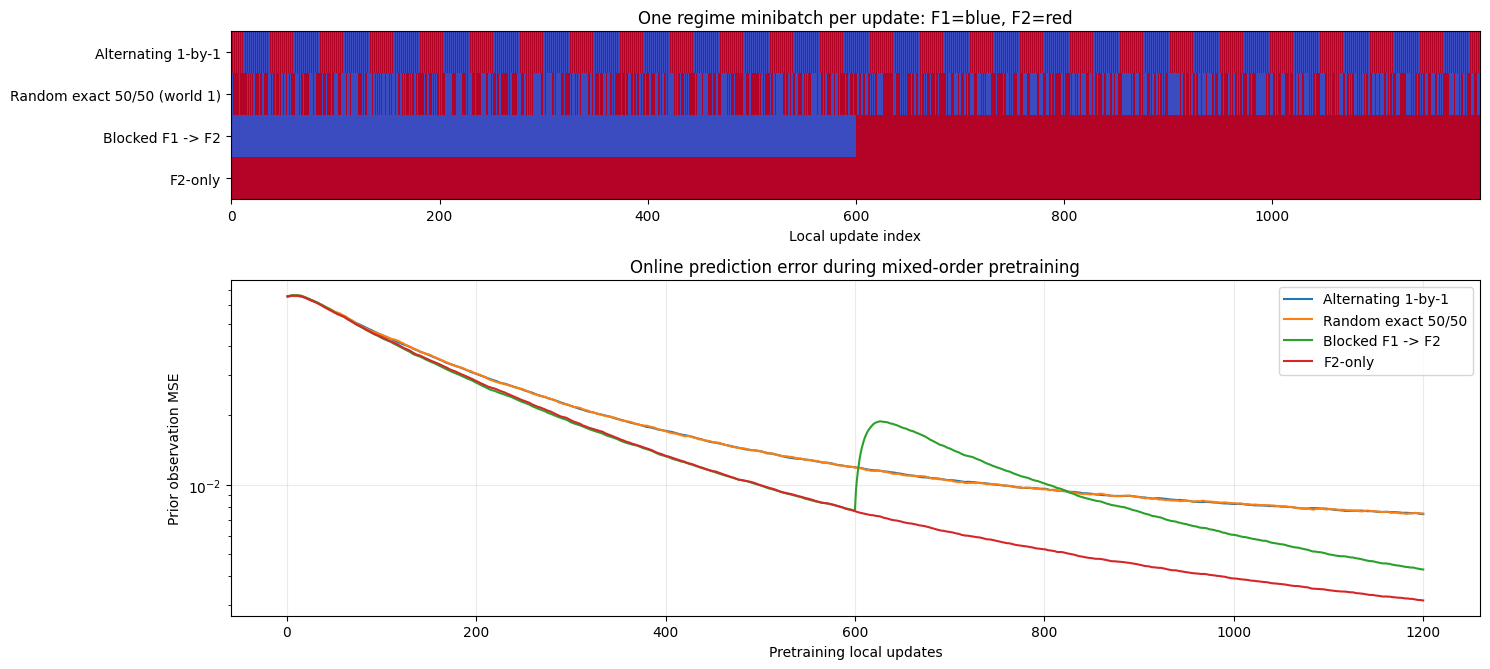

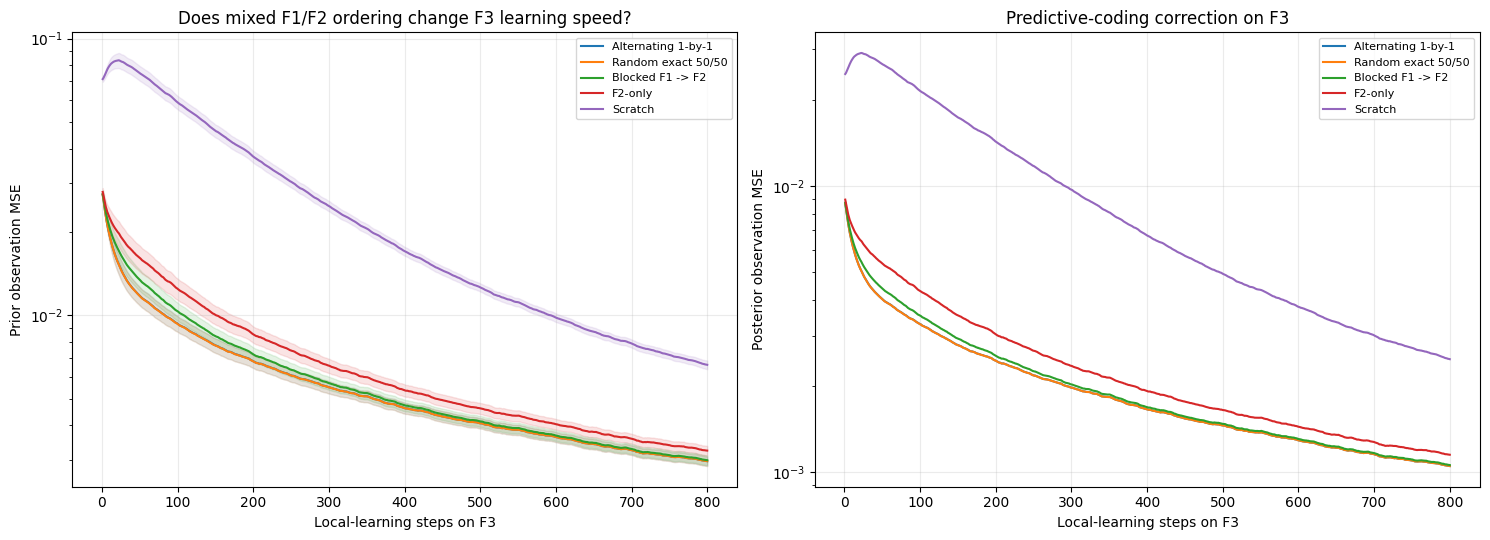

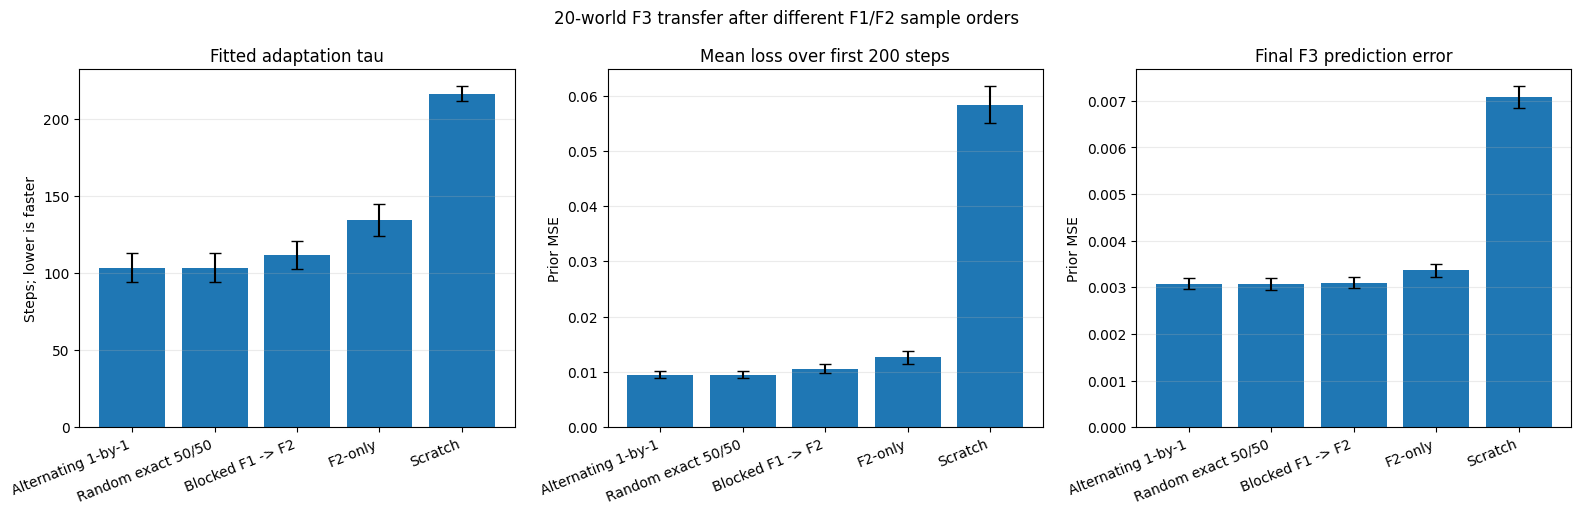

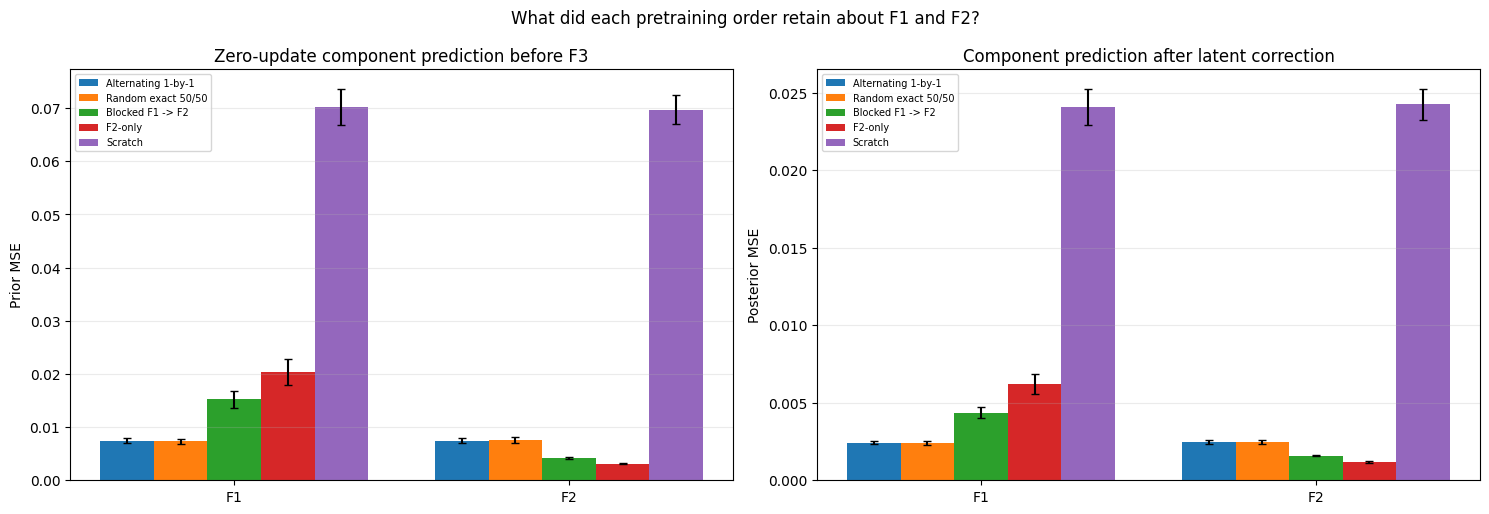

In [ ]:
# ============================================================
# V12 — T4-optimized interleaved / random-mixture F1-F2 -> F3 test
#
# Pretraining uses ONE regime minibatch per local update.
# The model is updated immediately after every minibatch.
#
# Equal-update pretraining branches:
#   1) alternating_1by1 : F1, F2, F1, F2, ...
#   2) random_50_50    : exactly 50% F1 / 50% F2, randomly shuffled
#                        independently in every world
#   3) blocked         : all F1 examples, then all F2 examples
#   4) F2_only         : equal total updates, all from F2
#   5) scratch         : no pretraining; included only in the F3 test
#
# F1 and F2 are maintained as SEPARATE persistent streams. Switching
# the training example does not incorrectly carry an F1 latent state
# into an F2 trajectory or vice versa. Each branch therefore has one
# latent/world state for each regime, while the WEIGHTS are shared.
#
# After pretraining, every branch remains fully plastic and receives
# the identical F3 trajectory. We compare fitted adaptation tau,
# early-loss AUC, final prediction error, and pre-F3 component probes.
#
# Requires the V11 helper cell to have been run first:
#   _v11_make_worlds, _v11_initial_checkpoint, _v11_expand_checkpoint,
#   _v11_stack_checkpoints, _v11_infer, _v11_initial_latent,
#   _v11_local_deltas, _v11_apply_local_update, _v11_fit_curve,
#   _v11_mean_sem, PCConfig
# ============================================================

import copy
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

_REQUIRED_V12 = [
    "PCConfig",
    "_v11_make_worlds",
    "_v11_initial_checkpoint",
    "_v11_expand_checkpoint",
    "_v11_stack_checkpoints",
    "_v11_infer",
    "_v11_initial_latent",
    "_v11_local_deltas",
    "_v11_apply_local_update",
    "_v11_fit_curve",
    "_v11_mean_sem",
]
_missing_v12 = [name for name in _REQUIRED_V12 if name not in globals()]
if _missing_v12:
    raise RuntimeError(
        "Run the V11 batched helper/experiment cell first. Missing: "
        + ", ".join(_missing_v12)
    )


def _v12_ema(values, span=21):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return values
    alpha = 2.0 / (span + 1.0)
    output = np.empty_like(values)
    output[0] = values[0]
    for index in range(1, len(values)):
        output[index] = alpha * values[index] + (1.0 - alpha) * output[index - 1]
    return output


def _v12_schedule_tensor(num_worlds, total_updates, device, seed):
    """Return [world, branch, update] regime ids: 0=F1, 1=F2."""
    if total_updates < 2 or total_updates % 2:
        raise ValueError("total_updates must be an even integer >= 2")

    half = total_updates // 2
    alternating = np.arange(total_updates, dtype=np.int64) % 2
    blocked = np.concatenate([
        np.zeros(half, dtype=np.int64),
        np.ones(half, dtype=np.int64),
    ])
    F2_only = np.ones(total_updates, dtype=np.int64)

    rng = np.random.default_rng(seed)
    random_balanced = np.empty((num_worlds, total_updates), dtype=np.int64)
    base = np.concatenate([
        np.zeros(half, dtype=np.int64),
        np.ones(half, dtype=np.int64),
    ])
    for world_index in range(num_worlds):
        random_balanced[world_index] = rng.permutation(base)

    schedules = np.empty((num_worlds, 4, total_updates), dtype=np.int64)
    schedules[:, 0] = alternating[None, :]
    schedules[:, 1] = random_balanced
    schedules[:, 2] = blocked[None, :]
    schedules[:, 3] = F2_only[None, :]
    return torch.tensor(schedules, device=device, dtype=torch.long)


@torch.no_grad()
def _v12_pretrain_mixed_streams(
    initial_checkpoint,
    cfg,
    worlds,
    *,
    total_updates,
    seed,
):
    """Train four weight branches using one selected regime stream per update."""
    device = torch.device(cfg.device)
    num_worlds = worlds["F1"].shape[0]
    branches = 4
    batch = cfg.batch_size
    dim = cfg.state_dim

    weights = _v11_expand_checkpoint(initial_checkpoint, branches)
    schedules = _v12_schedule_tensor(
        num_worlds,
        total_updates,
        device,
        seed + 1,
    )
    generator = torch.Generator(device=device)
    generator.manual_seed(seed + 2)

    # Separate persistent state and latent stream for F1 and F2.
    base_x = 0.25 * torch.randn(
        num_worlds, 1, 2, batch, dim,
        device=device,
        generator=generator,
    )
    x_stream = base_x.expand(-1, branches, -1, -1, -1).clone()
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, 2, batch, dim,
        device=device,
        generator=generator,
    )
    observation_stream = x_stream + initial_noise.expand(-1, branches, -1, -1, -1)

    z_stream = torch.empty(
        num_worlds, branches, 2, batch, cfg.latent_dim,
        device=device,
        dtype=torch.float32,
    )
    for regime in range(2):
        z_stream[:, :, regime] = _v11_initial_latent(
            weights,
            observation_stream[:, :, regime],
            cfg,
        )

    world_index = torch.arange(num_worlds, device=device)[:, None].expand(-1, branches)
    branch_index = torch.arange(branches, device=device)[None, :].expand(num_worlds, -1)
    regime_matrices = torch.stack([worlds["F1"], worlds["F2"]], dim=1)

    prior_curves = torch.empty(total_updates, num_worlds, branches, device=device)
    posterior_curves = torch.empty_like(prior_curves)
    temporal_curves = torch.empty_like(prior_curves)
    delta_A_curves = torch.empty_like(prior_curves)

    progress = tqdm(
        range(total_updates),
        desc="one-example F1/F2 mixture pretraining",
        unit="update",
        dynamic_ncols=True,
    )
    for step in progress:
        regime_ids = schedules[:, :, step]
        matrices = regime_matrices[world_index, regime_ids]
        x_previous = x_stream[world_index, branch_index, regime_ids]
        z_previous = z_stream[world_index, branch_index, regime_ids]

        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, batch, cfg.action_dim,
            device=device,
            generator=generator,
        )
        action = shared_action.expand(-1, branches, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, batch, dim,
            device=device,
            generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, batch, dim,
            device=device,
            generator=generator,
        )

        x_new = (
            torch.matmul(x_previous, matrices.transpose(-1, -2))
            + torch.matmul(action, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, branches, -1, -1)
        )
        observation = x_new + shared_observation.expand(-1, branches, -1, -1)

        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        deltas = _v11_local_deltas(inferred, z_previous, action, cfg)
        _v11_apply_local_update(weights, deltas, cfg)

        # Write only the selected regime stream back; the other stream is untouched.
        x_stream[world_index, branch_index, regime_ids] = x_new
        z_stream[world_index, branch_index, regime_ids] = inferred["z"]

        prior_curves[step] = (
            inferred["prior_prediction"] - observation
        ).square().mean(dim=(-1, -2))
        posterior_curves[step] = inferred["observation_error"].square().mean(dim=(-1, -2))
        temporal_curves[step] = inferred["temporal_error"].square().mean(dim=(-1, -2))
        delta_A_curves[step] = deltas[1].square().mean(dim=(-1, -2)).sqrt()

        if step == 0 or (step + 1) % 300 == 0:
            progress.set_postfix(
                alt=f"{prior_curves[step, :, 0].mean().item():.2e}",
                random=f"{prior_curves[step, :, 1].mean().item():.2e}",
                blocked=f"{prior_curves[step, :, 2].mean().item():.2e}",
            )

    checkpoints = {
        "alternating": {name: tensor[:, 0].clone() for name, tensor in weights.items()},
        "random_50_50": {name: tensor[:, 1].clone() for name, tensor in weights.items()},
        "blocked": {name: tensor[:, 2].clone() for name, tensor in weights.items()},
        "F2_only": {name: tensor[:, 3].clone() for name, tensor in weights.items()},
        "scratch": {name: tensor.clone() for name, tensor in initial_checkpoint.items()},
    }
    return {
        "checkpoints": checkpoints,
        "schedules": schedules.cpu().numpy(),
        "prior": prior_curves.cpu().numpy(),
        "posterior": posterior_curves.cpu().numpy(),
        "temporal": temporal_curves.cpu().numpy(),
        "delta_A": delta_A_curves.cpu().numpy(),
    }


@torch.no_grad()
def _v12_component_probes(checkpoints, cfg, worlds, *, steps, burn_in, seed):
    """Frozen-weight F1/F2 probes before F3 training."""
    if burn_in >= steps:
        raise ValueError("burn_in must be smaller than steps")
    labels = tuple(checkpoints.keys())
    base_weights = _v11_stack_checkpoints([checkpoints[label] for label in labels])
    models = len(labels)

    weights = {
        name: tensor[:, None].expand(-1, 2, -1, *tensor.shape[2:]).clone()
        for name, tensor in base_weights.items()
    }
    matrices = torch.stack([worlds["F1"], worlds["F2"]], dim=1)
    device = base_weights["A"].device
    num_worlds = worlds["F1"].shape[0]
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    x = 0.25 * torch.randn(
        num_worlds, 2, cfg.batch_size, cfg.state_dim,
        device=device,
        generator=generator,
    )
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation_env = x + initial_noise.expand(-1, 2, -1, -1)
    observation = observation_env[:, :, None].expand(-1, -1, models, -1, -1)
    zero_z = torch.zeros(
        num_worlds, 2, models, cfg.batch_size, cfg.latent_dim,
        device=device,
    )
    zero_action = torch.zeros(
        num_worlds, 2, models, cfg.batch_size, cfg.action_dim,
        device=device,
    )
    z_previous = _v11_infer(weights, observation, zero_z, zero_action, cfg)["z"]

    prior_sum = torch.zeros(num_worlds, 2, models, device=device)
    posterior_sum = torch.zeros_like(prior_sum)
    count = 0

    for step in tqdm(
        range(steps),
        desc="pre-F3 frozen F1/F2 probes",
        leave=False,
        dynamic_ncols=True,
    ):
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device,
            generator=generator,
        )
        action_env = shared_action.expand(-1, 2, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device,
            generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device,
            generator=generator,
        )
        x = (
            torch.matmul(x, matrices.transpose(-1, -2))
            + torch.matmul(action_env, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, 2, -1, -1)
        )
        observation_env = x + shared_observation.expand(-1, 2, -1, -1)
        observation = observation_env[:, :, None].expand(-1, -1, models, -1, -1)
        action = action_env[:, :, None].expand(-1, -1, models, -1, -1)
        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        z_previous = inferred["z"]
        if step >= burn_in:
            prior_sum.add_(
                (inferred["prior_prediction"] - observation)
                .square().mean(dim=(-1, -2))
            )
            posterior_sum.add_(inferred["observation_error"].square().mean(dim=(-1, -2)))
            count += 1

    return {
        "labels": labels,
        "prior": (prior_sum / count).cpu().numpy(),
        "posterior": (posterior_sum / count).cpu().numpy(),
    }


def _v12_effective_dynamics(weights):
    W = weights["W"].float()
    A = weights["A"].float()
    return torch.matmul(torch.matmul(W, A), torch.linalg.pinv(W))


@torch.no_grad()
def _v12_run_F3_adaptation(
    checkpoints,
    cfg,
    worlds,
    *,
    steps,
    early_auc_steps,
    seed,
):
    labels = tuple(checkpoints.keys())
    weights = _v11_stack_checkpoints([checkpoints[label] for label in labels])
    device = weights["A"].device
    num_worlds = worlds["F3"].shape[0]
    branches = len(labels)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    start_effective = _v12_effective_dynamics(weights)
    F3_expanded = worlds["F3"][:, None]
    start_distance = (
        torch.linalg.matrix_norm(start_effective - F3_expanded, dim=(-2, -1))
        / torch.linalg.matrix_norm(F3_expanded, dim=(-2, -1)).clamp_min(1e-12)
    )

    base_x = 0.25 * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device,
        generator=generator,
    )
    x = base_x.expand(-1, branches, -1, -1).clone()
    initial_noise = cfg.observation_noise * torch.randn(
        num_worlds, 1, cfg.batch_size, cfg.state_dim,
        device=device,
        generator=generator,
    )
    observation = x + initial_noise.expand(-1, branches, -1, -1)
    z_previous = _v11_initial_latent(weights, observation, cfg)

    prior = torch.empty(steps, num_worlds, branches, device=device)
    posterior = torch.empty_like(prior)
    temporal = torch.empty_like(prior)
    delta_A = torch.empty_like(prior)

    progress = tqdm(
        range(steps),
        desc="identical F3 adaptation after mixed pretraining",
        unit="step",
        dynamic_ncols=True,
    )
    for step in progress:
        shared_action = cfg.action_std * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.action_dim,
            device=device,
            generator=generator,
        )
        action = shared_action.expand(-1, branches, -1, -1)
        shared_process = cfg.process_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device,
            generator=generator,
        )
        shared_observation = cfg.observation_noise * torch.randn(
            num_worlds, 1, cfg.batch_size, cfg.state_dim,
            device=device,
            generator=generator,
        )
        x = (
            torch.matmul(x, worlds["F3"][:, None].transpose(-1, -2))
            + torch.matmul(action, worlds["G"][:, None].transpose(-1, -2))
            + shared_process.expand(-1, branches, -1, -1)
        )
        observation = x + shared_observation.expand(-1, branches, -1, -1)

        inferred = _v11_infer(weights, observation, z_previous, action, cfg)
        deltas = _v11_local_deltas(inferred, z_previous, action, cfg)
        _v11_apply_local_update(weights, deltas, cfg)
        z_previous = inferred["z"]

        prior[step] = (
            inferred["prior_prediction"] - observation
        ).square().mean(dim=(-1, -2))
        posterior[step] = inferred["observation_error"].square().mean(dim=(-1, -2))
        temporal[step] = inferred["temporal_error"].square().mean(dim=(-1, -2))
        delta_A[step] = deltas[1].square().mean(dim=(-1, -2)).sqrt()

        if step == 0 or (step + 1) % 250 == 0:
            progress.set_postfix(
                alt=f"{prior[step, :, 0].mean().item():.2e}",
                random=f"{prior[step, :, 1].mean().item():.2e}",
                blocked=f"{prior[step, :, 2].mean().item():.2e}",
            )

    final_effective = _v12_effective_dynamics(weights)
    final_distance = (
        torch.linalg.matrix_norm(final_effective - F3_expanded, dim=(-2, -1))
        / torch.linalg.matrix_norm(F3_expanded, dim=(-2, -1)).clamp_min(1e-12)
    )

    prior_np = prior.cpu().numpy()
    posterior_np = posterior.cpu().numpy()
    metrics = {}
    for branch_index, label in enumerate(labels):
        tau, E0, E_inf, r2, auc, final_prior, final_post = [], [], [], [], [], [], []
        for world_index in range(num_worlds):
            fit = _v11_fit_curve(prior_np[:, world_index, branch_index], smoothing_span=21)
            tau.append(fit["tau"])
            E0.append(fit["E0"])
            E_inf.append(fit["E_inf"])
            r2.append(fit["r2"])
            auc.append(
                float(prior_np[: min(early_auc_steps, steps), world_index, branch_index].mean())
            )
            final_prior.append(float(prior_np[-100:, world_index, branch_index].mean()))
            final_post.append(float(posterior_np[-100:, world_index, branch_index].mean()))
        metrics[label] = {
            "tau": np.asarray(tau),
            "E0": np.asarray(E0),
            "E_inf": np.asarray(E_inf),
            "r2": np.asarray(r2),
            "early_auc": np.asarray(auc),
            "final_prior": np.asarray(final_prior),
            "final_posterior": np.asarray(final_post),
            "start_dF3": start_distance[:, branch_index].cpu().numpy(),
            "final_dF3": final_distance[:, branch_index].cpu().numpy(),
        }

    return {
        "labels": labels,
        "weights": weights,
        "prior": prior_np,
        "posterior": posterior_np,
        "temporal": temporal.cpu().numpy(),
        "delta_A": delta_A.cpu().numpy(),
        "metrics": metrics,
    }


@torch.no_grad()
def run_v12_interleaved_mixture_transfer(
    base_cfg,
    *,
    num_worlds=20,
    batch_per_world=96,
    inference_steps=8,
    total_pretrain_updates=1200,
    F3_test_steps=800,
    early_auc_steps=200,
    component_probe_steps=180,
    component_probe_burn_in=30,
    factor_rank=4,
    seed_offset=56000,
):
    started = time.perf_counter()
    cfg = copy.deepcopy(base_cfg)
    cfg.batch_size = batch_per_world
    cfg.inference_steps = inference_steps
    cfg.mixed_observations = False
    cfg.obs_dim = cfg.state_dim
    cfg.latent_dim = cfg.state_dim
    cfg.visualize = False
    cfg.record_checkpoints = False
    cfg.shift_step = None
    cfg.validate()

    if total_pretrain_updates % 2:
        raise ValueError("total_pretrain_updates must be even for exact 50/50 schedules")
    if torch.device(cfg.device).type != "cuda":
        print("Warning: V12 is optimized for CUDA/T4; CPU execution is only for smoke testing.")

    worlds = _v11_make_worlds(
        cfg,
        num_worlds=num_worlds,
        seed=cfg.seed + seed_offset,
        factor_rank=factor_rank,
    )
    initial = _v11_initial_checkpoint(
        cfg,
        num_worlds,
        cfg.seed + seed_offset + 1,
    )

    pretrain = _v12_pretrain_mixed_streams(
        initial,
        cfg,
        worlds,
        total_updates=total_pretrain_updates,
        seed=cfg.seed + seed_offset + 20,
    )
    probes = _v12_component_probes(
        pretrain["checkpoints"],
        cfg,
        worlds,
        steps=component_probe_steps,
        burn_in=component_probe_burn_in,
        seed=cfg.seed + seed_offset + 30,
    )
    F3 = _v12_run_F3_adaptation(
        pretrain["checkpoints"],
        cfg,
        worlds,
        steps=F3_test_steps,
        early_auc_steps=early_auc_steps,
        seed=cfg.seed + seed_offset + 40,
    )

    elapsed = time.perf_counter() - started
    return {
        "cfg": cfg,
        "worlds": worlds,
        "pretrain": pretrain,
        "probes": probes,
        "F3": F3,
        "elapsed": elapsed,
        "num_worlds": num_worlds,
        "total_pretrain_updates": total_pretrain_updates,
        "F3_test_steps": F3_test_steps,
        "early_auc_steps": early_auc_steps,
    }


def summarize_v12_interleaved_mixture(result):
    labels = result["F3"]["labels"]
    metrics = result["F3"]["metrics"]
    display = {
        "alternating": "Alternating 1-by-1",
        "random_50_50": "Random exact 50/50",
        "blocked": "Blocked F1 -> F2",
        "F2_only": "F2-only",
        "scratch": "Scratch",
    }

    print("\nV12 — interleaved and random-mixture F1/F2 -> F3 transfer")
    print("=" * 122)
    print(
        f"worlds={result['num_worlds']} | pretraining updates={result['total_pretrain_updates']} "
        f"| F3 steps={result['F3_test_steps']} | inference steps={result['cfg'].inference_steps} "
        f"| elapsed={result['elapsed']:.1f}s"
    )
    print(
        "Alternating/random/blocked each contain exactly 50% F1 and 50% F2. "
        "Every minibatch is followed immediately by one local predictive-coding update."
    )
    print("-" * 122)
    print(
        "History                     tau          early AUC       final prior     final post      start dF3   final dF3"
    )
    print("-" * 122)
    for label in labels:
        row = metrics[label]
        tau = _v11_mean_sem(row["tau"])
        auc = _v11_mean_sem(row["early_auc"])
        fp = _v11_mean_sem(row["final_prior"])
        fpost = _v11_mean_sem(row["final_posterior"])
        sd = _v11_mean_sem(row["start_dF3"])
        fd = _v11_mean_sem(row["final_dF3"])
        print(
            f"{display[label]:<27s} "
            f"{tau[0]:7.1f} ± {tau[1]:<6.1f} "
            f"{auc[0]:9.5f} ± {auc[1]:<8.5f} "
            f"{fp[0]:9.6f} ± {fp[1]:<8.6f} "
            f"{fpost[0]:9.6f} ± {fpost[1]:<8.6f} "
            f"{sd[0]:7.3f} ± {sd[1]:<6.3f} "
            f"{fd[0]:7.3f} ± {fd[1]:<6.3f}"
        )

    alt_tau = np.nanmean(metrics["alternating"]["tau"])
    random_tau = np.nanmean(metrics["random_50_50"]["tau"])
    blocked_tau = np.nanmean(metrics["blocked"]["tau"])
    print("\nPrimary order comparisons")
    print("-" * 72)
    print(f"Alternating speedup over blocked: {blocked_tau / max(alt_tau, 1e-12):.2f}x")
    print(f"Random-50/50 speedup over blocked: {blocked_tau / max(random_tau, 1e-12):.2f}x")
    print(f"Alternating vs random tau ratio:  {random_tau / max(alt_tau, 1e-12):.2f}x (>1 favors alternating)")
    print(
        "Interpretation: alternating and random have identical regime counts; differences isolate ordering/spacing, "
        "while blocked tests the effect of temporal separation and recency."
    )


def plot_v12_interleaved_mixture(result, smoothing_span=21):
    labels = result["F3"]["labels"]
    display = {
        "alternating": "Alternating 1-by-1",
        "random_50_50": "Random exact 50/50",
        "blocked": "Blocked F1 -> F2",
        "F2_only": "F2-only",
        "scratch": "Scratch",
    }
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # Figure 1: actual schedule raster and pretraining error.
    schedules = result["pretrain"]["schedules"]
    total_updates = result["total_pretrain_updates"]
    fig, axes = plt.subplots(2, 1, figsize=(15, 6.8), gridspec_kw={"height_ratios": [1, 2]})
    schedule_image = schedules[0, :4]
    axes[0].imshow(schedule_image, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=0, vmax=1)
    axes[0].set_yticks(range(4))
    axes[0].set_yticklabels([
        "Alternating 1-by-1",
        "Random exact 50/50 (world 1)",
        "Blocked F1 -> F2",
        "F2-only",
    ])
    axes[0].set_xlabel("Local update index")
    axes[0].set_title("One regime minibatch per update: F1=blue, F2=red")

    pre_prior = result["pretrain"]["prior"]
    pre_labels = labels[:4]
    x_pre = np.arange(1, total_updates + 1)
    for index, label in enumerate(pre_labels):
        mean_curve = pre_prior[:, :, index].mean(axis=1)
        axes[1].plot(x_pre, _v12_ema(mean_curve, smoothing_span), label=display[label], color=colors[index])
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Pretraining local updates")
    axes[1].set_ylabel("Prior observation MSE")
    axes[1].set_title("Online prediction error during mixed-order pretraining")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

    # Figure 2: F3 loss trajectories.
    prior = result["F3"]["prior"]
    posterior = result["F3"]["posterior"]
    steps = np.arange(1, result["F3_test_steps"] + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for index, label in enumerate(labels):
        mean = prior[:, :, index].mean(axis=1)
        sem = prior[:, :, index].std(axis=1, ddof=1) / math.sqrt(result["num_worlds"])
        smoothed = _v12_ema(mean, smoothing_span)
        axes[0].plot(steps, smoothed, label=display[label], color=colors[index % len(colors)])
        axes[0].fill_between(
            steps,
            np.maximum(_v12_ema(mean - sem, smoothing_span), 1e-10),
            _v12_ema(mean + sem, smoothing_span),
            alpha=0.12,
            color=colors[index % len(colors)],
        )
        post_mean = posterior[:, :, index].mean(axis=1)
        axes[1].plot(steps, _v12_ema(post_mean, smoothing_span), label=display[label], color=colors[index % len(colors)])
    for axis, title, ylabel in (
        (axes[0], "Does mixed F1/F2 ordering change F3 learning speed?", "Prior observation MSE"),
        (axes[1], "Predictive-coding correction on F3", "Posterior observation MSE"),
    ):
        axis.set_yscale("log")
        axis.set_xlabel("Local-learning steps on F3")
        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    # Figure 3: quantitative F3 metrics.
    metrics = result["F3"]["metrics"]
    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
    metric_specs = (
        ("tau", "Fitted adaptation tau", "Steps; lower is faster"),
        ("early_auc", f"Mean loss over first {result['early_auc_steps']} steps", "Prior MSE"),
        ("final_prior", "Final F3 prediction error", "Prior MSE"),
    )
    for axis, (key, title, ylabel) in zip(axes, metric_specs):
        means, sems = [], []
        for label in labels:
            mean, sem = _v11_mean_sem(metrics[label][key])
            means.append(mean); sems.append(sem)
        axis.bar(x, means, yerr=sems, capsize=4)
        axis.set_xticks(x)
        axis.set_xticklabels([display[label] for label in labels], rotation=22, ha="right")
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
    fig.suptitle("20-world F3 transfer after different F1/F2 sample orders")
    fig.tight_layout()
    plt.show()

    # Figure 4: frozen component knowledge immediately before F3.
    probe_labels = result["probes"]["labels"]
    prior_probe = result["probes"]["prior"]
    posterior_probe = result["probes"]["posterior"]
    components = ("F1", "F2")
    width = 0.16
    x = np.arange(2)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    for model_index, label in enumerate(probe_labels):
        prior_means, prior_sems, post_means, post_sems = [], [], [], []
        for component_index in range(2):
            pm = _v11_mean_sem(prior_probe[:, component_index, model_index])
            qm = _v11_mean_sem(posterior_probe[:, component_index, model_index])
            prior_means.append(pm[0]); prior_sems.append(pm[1])
            post_means.append(qm[0]); post_sems.append(qm[1])
        offset = (model_index - (len(probe_labels) - 1) / 2) * width
        axes[0].bar(x + offset, prior_means, width, yerr=prior_sems, capsize=3, label=display[label])
        axes[1].bar(x + offset, post_means, width, yerr=post_sems, capsize=3, label=display[label])
    for axis, title, ylabel in (
        (axes[0], "Zero-update component prediction before F3", "Prior MSE"),
        (axes[1], "Component prediction after latent correction", "Posterior MSE"),
    ):
        axis.set_xticks(x)
        axis.set_xticklabels(components)
        axis.set_title(title)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", alpha=0.25)
        axis.legend(fontsize=7)
    fig.suptitle("What did each pretraining order retain about F1 and F2?")
    fig.tight_layout()
    plt.show()


# -------------------------
# Run: tuned for one T4
# -------------------------
V12_NUM_WORLDS = 20
V12_BATCH_PER_WORLD = 96
V12_INFERENCE_STEPS = 8
V12_TOTAL_PRETRAIN_UPDATES = 1200   # even: 600 F1 + 600 F2 for all 50/50 branches
V12_F3_TEST_STEPS = 800
V12_EARLY_AUC_STEPS = 200
V12_COMPONENT_PROBE_STEPS = 180
V12_COMPONENT_PROBE_BURN_IN = 30
V12_FACTOR_RANK = 4

if "v11_cfg" in globals() and isinstance(v11_cfg, PCConfig):
    v12_cfg = copy.deepcopy(v11_cfg)
elif "bidirectional_cfg" in globals() and isinstance(bidirectional_cfg, PCConfig):
    v12_cfg = copy.deepcopy(bidirectional_cfg)
elif "cfg" in globals() and isinstance(cfg, PCConfig):
    v12_cfg = copy.deepcopy(cfg)
else:
    v12_cfg = PCConfig()

v12_result = run_v12_interleaved_mixture_transfer(
    v12_cfg,
    num_worlds=V12_NUM_WORLDS,
    batch_per_world=V12_BATCH_PER_WORLD,
    inference_steps=V12_INFERENCE_STEPS,
    total_pretrain_updates=V12_TOTAL_PRETRAIN_UPDATES,
    F3_test_steps=V12_F3_TEST_STEPS,
    early_auc_steps=V12_EARLY_AUC_STEPS,
    component_probe_steps=V12_COMPONENT_PROBE_STEPS,
    component_probe_burn_in=V12_COMPONENT_PROBE_BURN_IN,
    factor_rank=V12_FACTOR_RANK,
)

summarize_v12_interleaved_mixture(v12_result)
plot_v12_interleaved_mixture(v12_result)

V14 fixed-color object-slot occlusion experiment
device: cuda
slots: 4 | pattern-type-specific outputs: 0


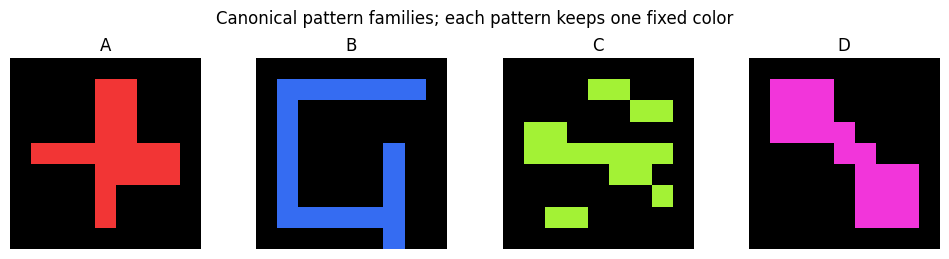

Building transformed-mask banks...
bank memory MB: 21.2


non-occluded object-slot training:   0%|          | 0/1800 [00:00<?, ?it/s]

training elapsed: 160.6s


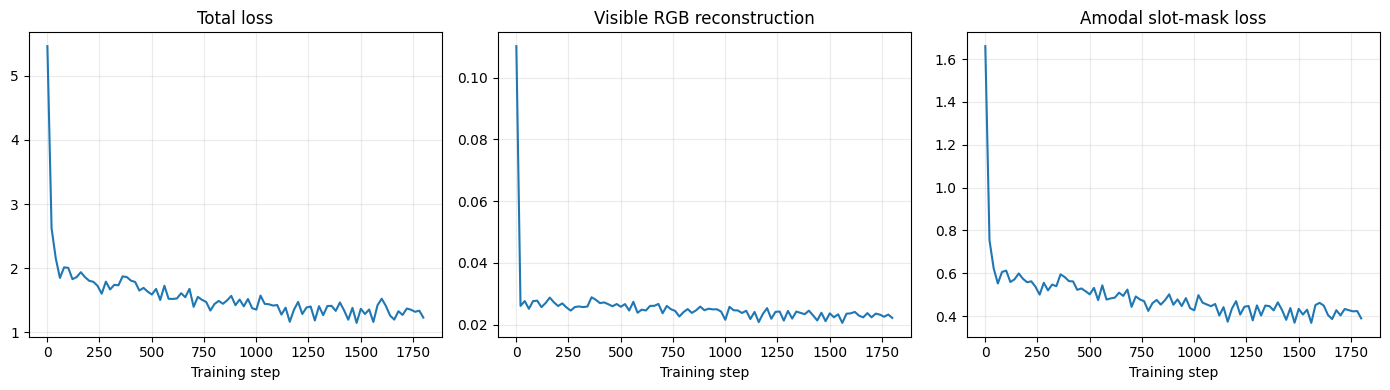


Primary occlusion decomposition results


,phase,boundary,amodal_iou,hidden_recall,count_accuracy,recomposition_mse,n_scenes
2,phase1_known_pairs,flat,0.207758,0.534589,0.328125,0.017121,128
3,phase1_known_pairs,torus,0.218694,0.275419,0.562500,0.018973,128
16,phase2_random_instances,flat,0.191079,0.354931,0.445312,0.026983,128
22,phase2_random_instances,torus,0.179299,0.354068,0.523438,0.031908,128



Random-scene multiple-instance breakdown


,boundary,subset,amodal_iou,hidden_recall,count_accuracy,n_scenes
17,flat,unique_types,0.204864,0.532118,0.458333,48
18,flat,duplicate_types,0.185077,0.293301,0.437500,80
19,flat,count_2,0.226480,0.642063,0.525000,40
20,flat,count_3,0.177967,0.305437,0.534884,43
21,flat,count_4,0.184742,0.291528,0.288889,45
23,torus,unique_types,0.205648,0.444231,0.672727,55
24,torus,duplicate_types,0.165613,0.315321,0.410959,73
25,torus,count_2,0.223936,0.524074,0.790698,43
26,torus,count_3,0.191832,0.375289,0.529412,34
27,torus,count_4,0.154214,0.299913,0.294118,51


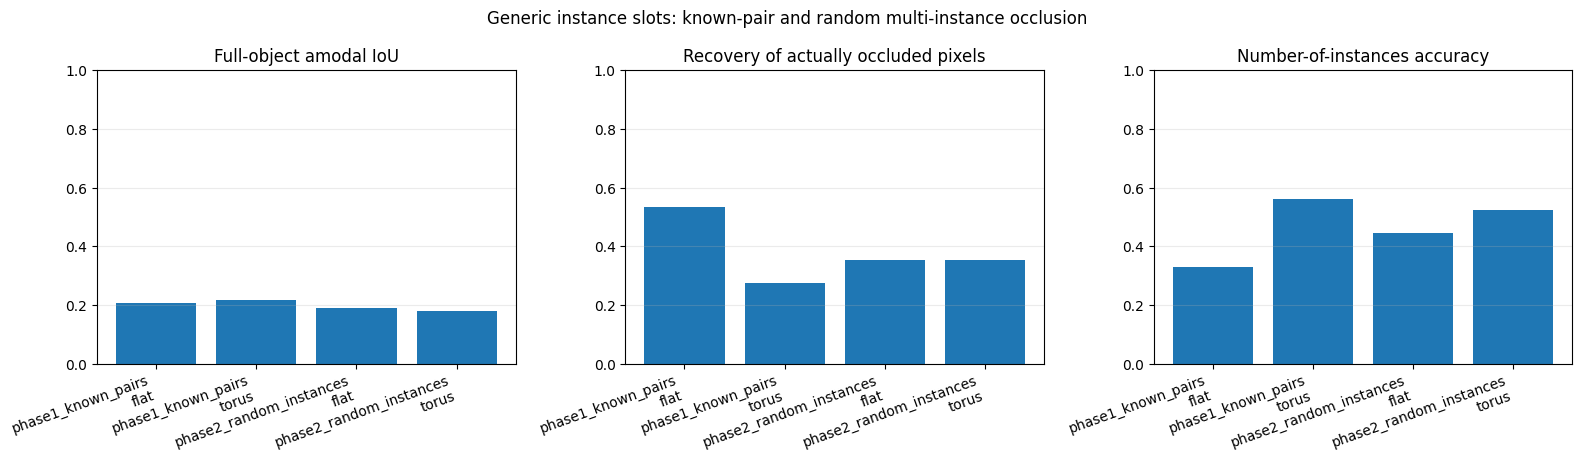

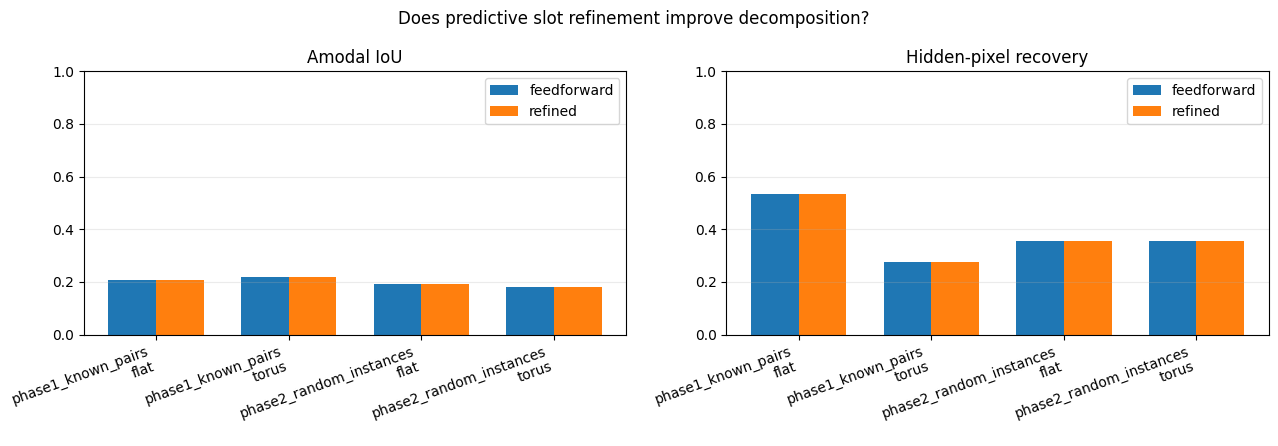

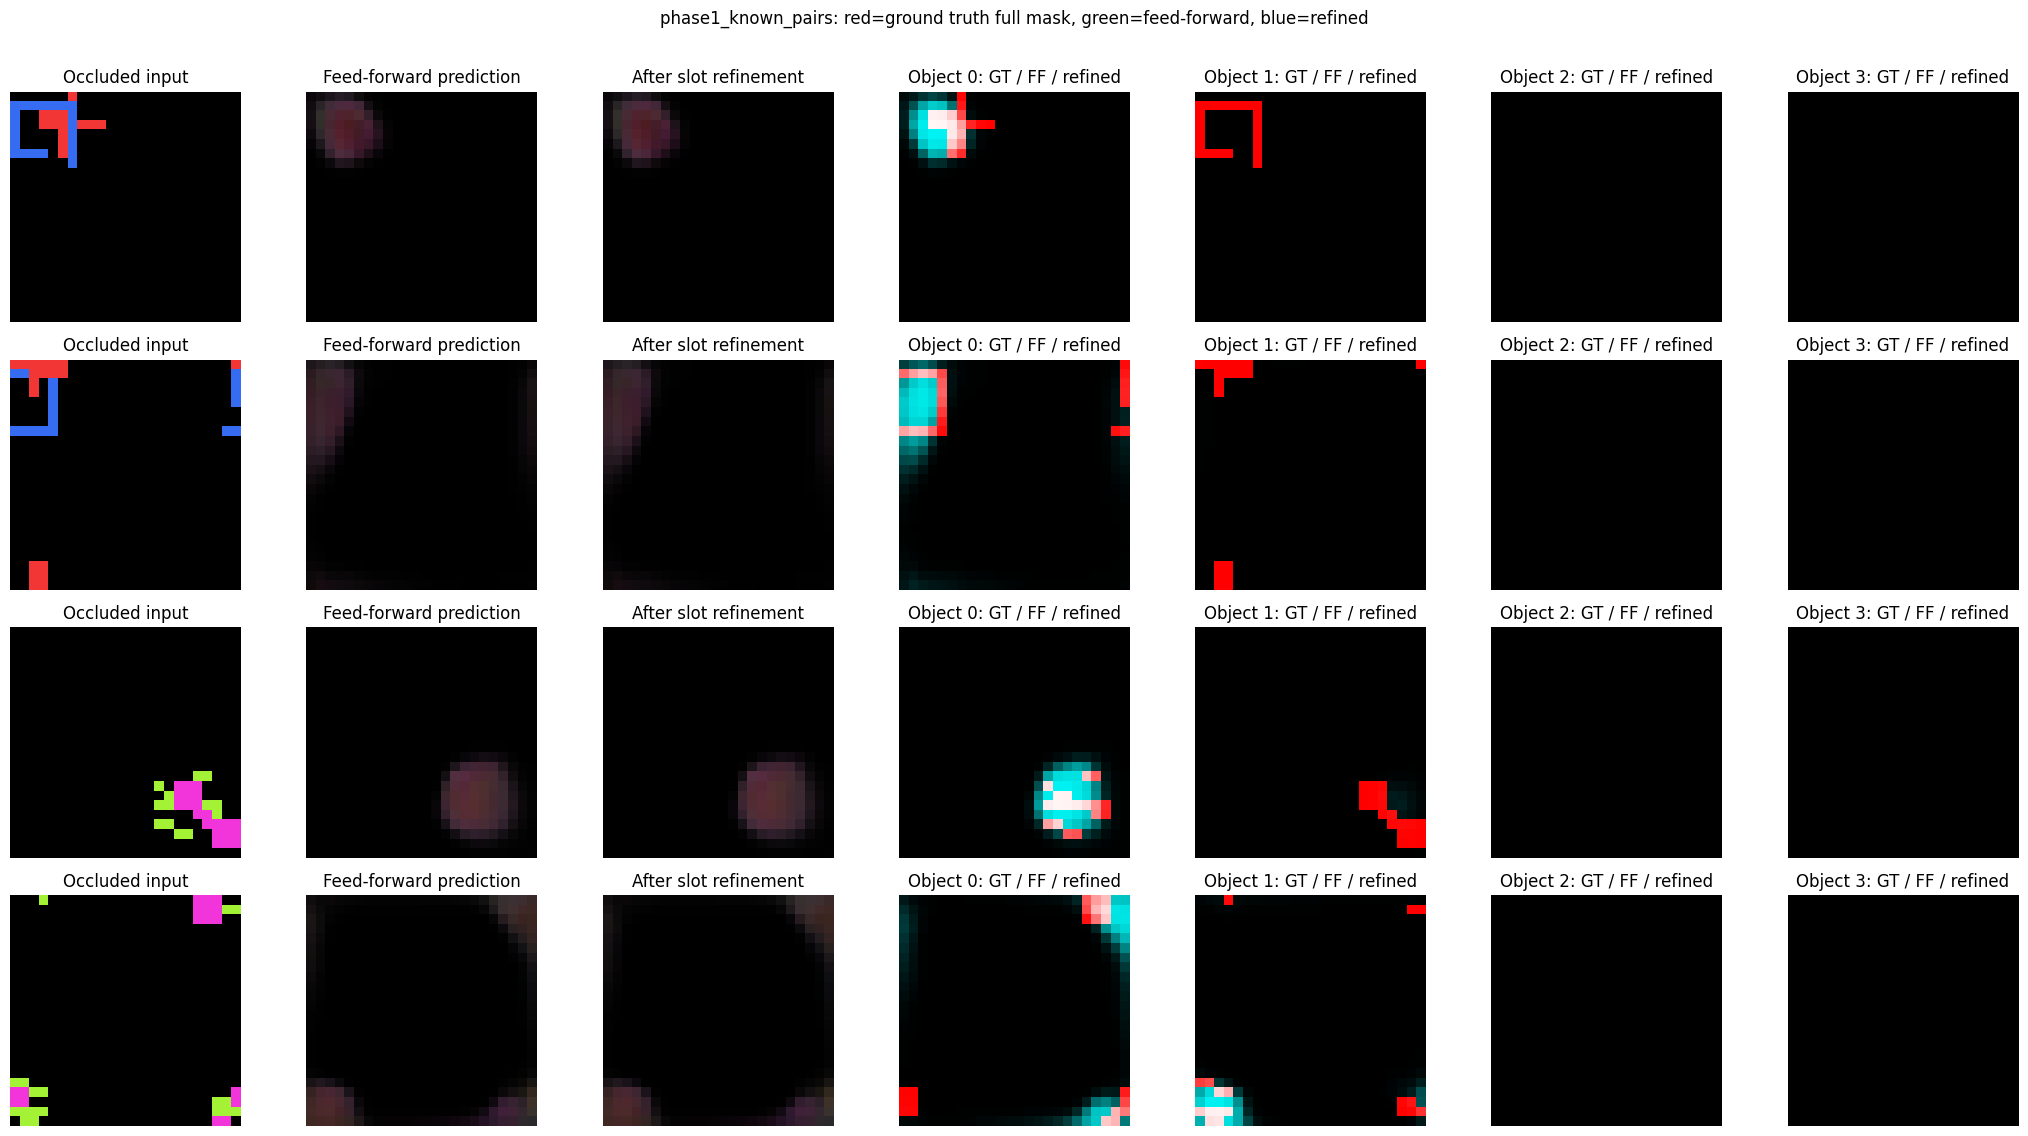

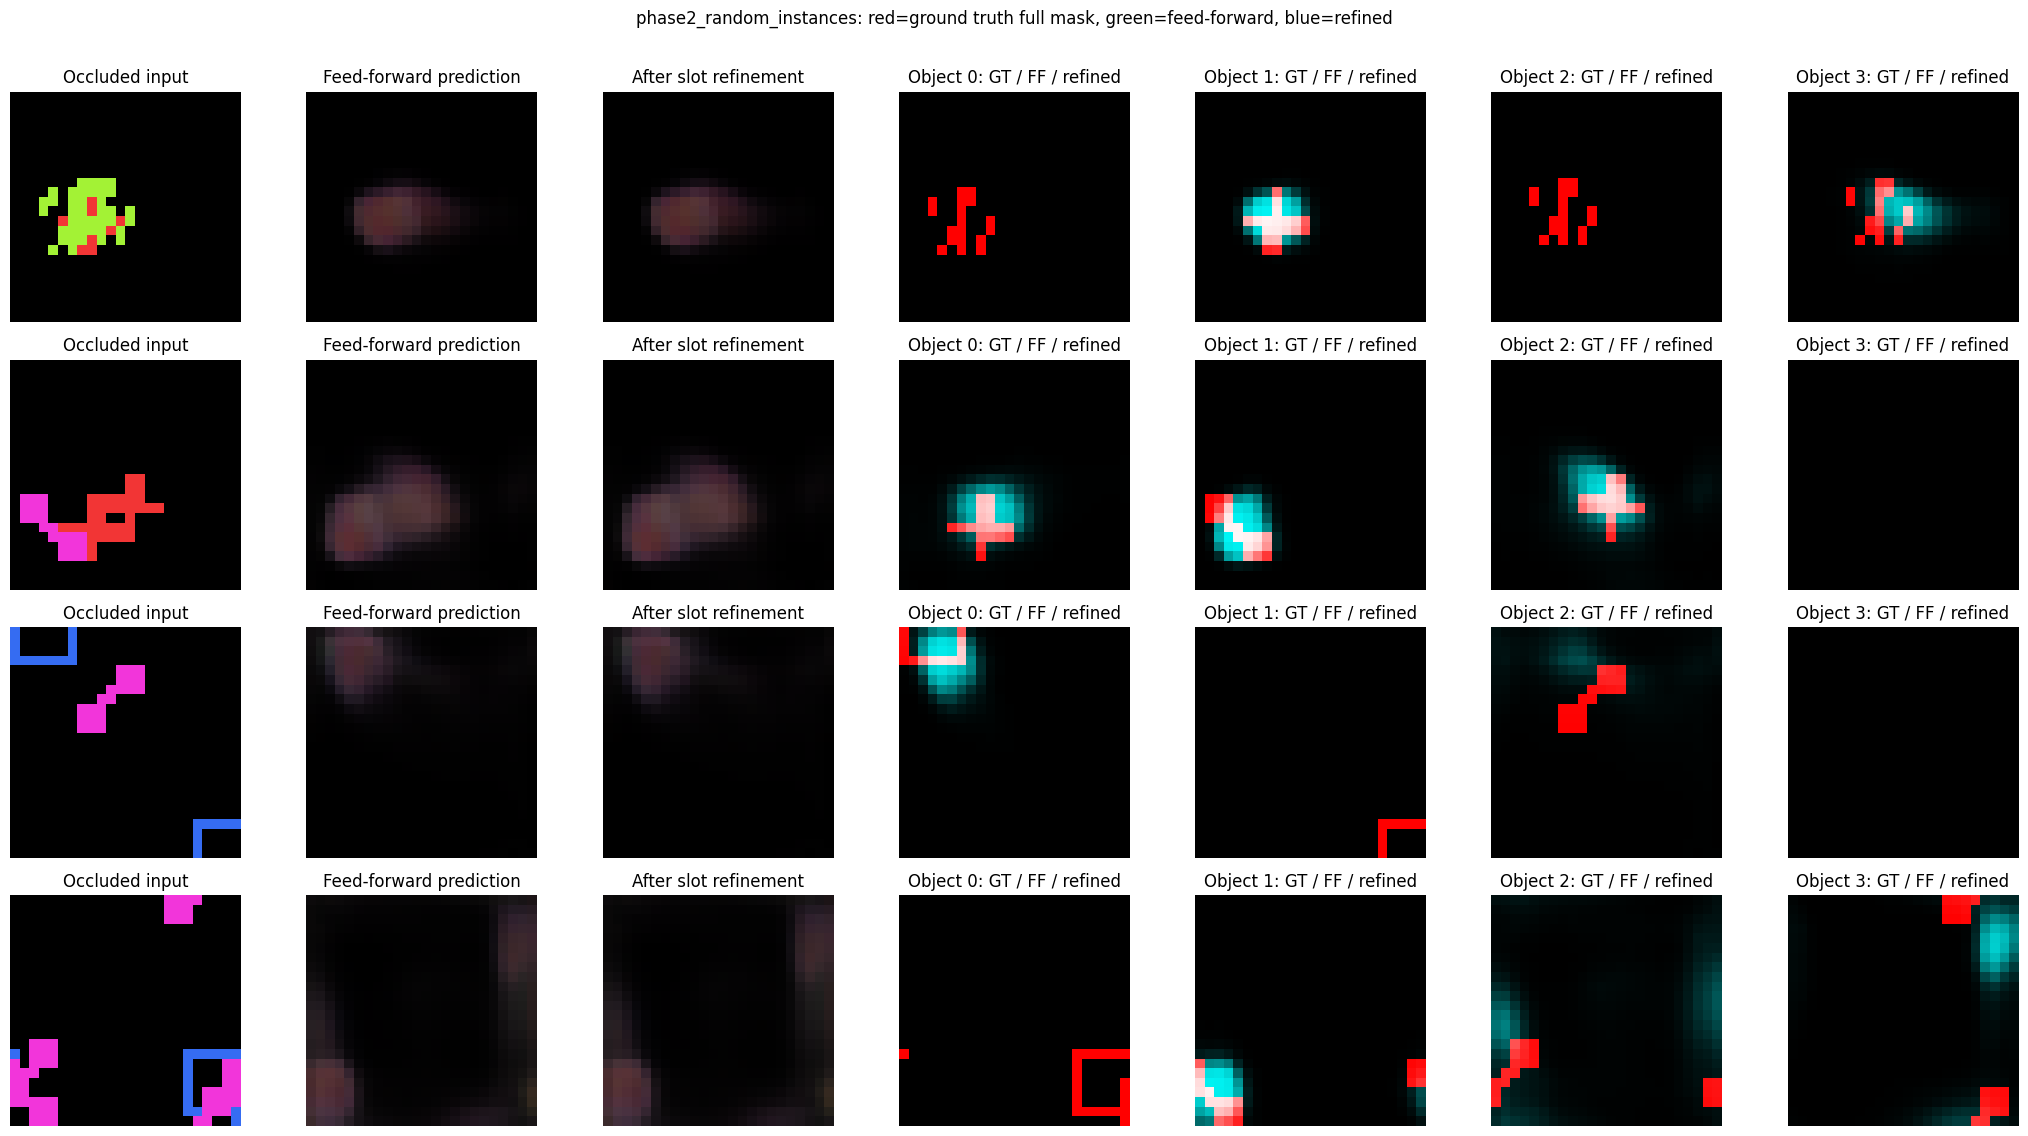

Saved /content/object_slot_occlusion_results.csv

Interpretation guide
- High phase-1 hidden recall: known isolated patterns support amodal completion under new overlap.
- Similar phase-2 performance: slots generalize to held-out pairings, variable counts, and duplicates.
- A duplicate-types collapse means slots are still type-like rather than instance-like.
- A torus-only drop indicates reliance on flat-boundary clipping cues.
- Refinement > feed-forward supports iterative predictive correction; equal scores mean the encoder already settled.
- The number of slots limits simultaneous instances, not the number of pattern families.


In [ ]:
# ============================================================
# V14 — FIXED-COLOR OBJECT-SLOT OCCLUSION / AMODAL COMPLETION TEST
#
# Scientific question
# -------------------
# Can a fixed set of interchangeable INSTANCE slots learn four pattern
# families from isolated/non-overlapping scenes, then recover complete
# object masks when previously unseen overlaps hide parts of the objects?
#
# No slot corresponds to A/B/C/D. The model receives no type labels and
# contains no output whose size depends on the number of pattern types.
# Adding another pattern only changes the procedural training data; the
# encoder, slots, shared decoder, and losses remain unchanged.
#
# Training:
#   - 50% isolated one-object scenes
#   - 50% non-overlapping scenes with 2..MAX_SLOTS instances
#   - pattern identity, pose, and boundary condition are interwoven
#   - duplicate instances of the same pattern are allowed
#   - NO occlusion is shown during training
#
# Test 1:
#   - A/B and C/D overlaps, both depth orders
# Test 2:
#   - random 2..MAX_SLOTS scenes drawn with replacement from A/B/C/D
#   - duplicate pattern instances are explicitly included
#
# Both tests report flat and toroidal boundaries separately.
# After the feed-forward slot estimate, frozen-weight latent refinement
# minimizes visible prediction error. This is predictive-coding-style
# inference over slot activities; network weights do not change at test.
#
# T4 defaults target a useful run in a few minutes. Reduce TRAIN_STEPS to
# 300 for a quick pipeline check, then restore 1800+ for real evidence.
# ============================================================

import copy
import colorsys
import itertools
import math
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

try:
    from IPython.display import display
except Exception:
    display = print

# -----------------------------
# Configuration
# -----------------------------

@dataclass
class OcclusionConfig:
    seed: int = 17
    grid_size: int = 24
    canonical_size: int = 9
    max_slots: int = 4
    slot_dim: int = 64
    feature_dim: int = 64
    slot_iterations: int = 3

    train_steps: int = 1800
    batch_size: int = 128
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    isolated_probability: float = 0.50

    mask_loss_weight: float = 3.0
    presence_loss_weight: float = 0.5
    reconstruction_loss_weight: float = 1.0
    slot_entropy_weight: float = 0.002

    eval_scenes_per_condition: int = 256
    refine_steps: int = 18
    refine_rate: float = 0.35
    refine_prior_weight: float = 0.02

    min_occlusion: float = 0.18
    max_occlusion: float = 0.72
    amp: bool = True

    def validate(self):
        if self.grid_size % 4 != 0:
            raise ValueError("grid_size should be divisible by 4")
        if self.max_slots < 4:
            raise ValueError("max_slots must be >= 4 for the requested test")
        if not (0.0 <= self.isolated_probability <= 1.0):
            raise ValueError("isolated_probability must be in [0,1]")


CFG_OCC = OcclusionConfig()
CFG_OCC.validate()

DEVICE_OCC = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE_OCC.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print("V14 fixed-color object-slot occlusion experiment")
print("device:", DEVICE_OCC)
print("slots:", CFG_OCC.max_slots, "| pattern-type-specific outputs: 0")


def set_occ_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_occ_seed(CFG_OCC.seed)

# -----------------------------
# Four canonical pattern families
# -----------------------------


def make_canonical_patterns(size: int = 9) -> torch.Tensor:
    """Return [4, size, size] binary patterns A/B/C/D.

    Nothing downstream assumes there are exactly four pattern categories.
    The neural model never sees these labels. Appending another mask here
    changes only the data distribution, not the number of slots or heads.
    """
    if size < 7 or size % 2 == 0:
        raise ValueError("canonical_size must be odd and >= 7")

    c = size // 2
    patterns = []

    # A: asymmetric hooked cross
    A = torch.zeros(size, size)
    A[c, 1:-1] = 1
    A[1:-1, c] = 1
    A[1:4, c + 1] = 1
    A[c + 1, c + 1:-1] = 1
    patterns.append(A)

    # B: hollow angular frame with one missing side
    B = torch.zeros(size, size)
    B[1:-1, 1] = 1
    B[1, 1:-1] = 1
    B[-2, 1:-3] = 1
    B[c:, -3] = 1
    patterns.append(B)

    # C: zig-zag / lightning
    C = torch.zeros(size, size)
    for i in range(1, size - 1):
        j = (2 * i + 1) % (size - 2) + 1
        C[i, j] = 1
        if j + 1 < size - 1:
            C[i, j + 1] = 1
    C[c, 1:-1] = torch.maximum(C[c, 1:-1], torch.ones(size - 2))
    patterns.append(C)

    # D: two separated lobes joined by a diagonal bridge
    D = torch.zeros(size, size)
    D[1:4, 1:4] = 1
    D[-4:-1, -4:-1] = 1
    for i in range(2, size - 2):
        D[i, i] = 1
        if i + 1 < size:
            D[i, i + 1] = 1
    patterns.append(D)

    return torch.stack(patterns).float()


PATTERNS_OCC = make_canonical_patterns(CFG_OCC.canonical_size)
PATTERN_NAMES_OCC = ["A", "B", "C", "D"]
NUM_PATTERNS_OCC = PATTERNS_OCC.shape[0]

# Each pattern family has one deterministic color across every scene.
# The mapping is generated from the pattern index, so adding a new pattern
# does not require adding another learnable variable, slot, or output head.
def make_pattern_colors(num_patterns: int) -> torch.Tensor:
    golden_ratio = 0.6180339887498949
    rgb = [
        colorsys.hsv_to_rgb((index * golden_ratio) % 1.0, 0.78, 0.95)
        for index in range(num_patterns)
    ]
    return torch.tensor(rgb, dtype=torch.float32)


PATTERN_COLORS_OCC = make_pattern_colors(NUM_PATTERNS_OCC)


def plot_canonical_patterns(patterns: torch.Tensor) -> None:
    fig, axes = plt.subplots(1, len(patterns), figsize=(10, 2.6))
    for i, ax in enumerate(axes):
        mask = patterns[i].numpy()[..., None]
        color = PATTERN_COLORS_OCC[i].numpy()[None, None, :]
        ax.imshow(mask * color)
        ax.set_title(PATTERN_NAMES_OCC[i] if i < len(PATTERN_NAMES_OCC) else str(i))
        ax.axis("off")
    fig.suptitle("Canonical pattern families; each pattern keeps one fixed color")
    fig.tight_layout()
    plt.show()


plot_canonical_patterns(PATTERNS_OCC)

# -----------------------------
# Fast transformed-mask bank
# -----------------------------


def build_transform_bank(
    patterns: torch.Tensor,
    grid_size: int,
    boundary: str,
    device: torch.device,
) -> torch.Tensor:
    """[type, rotation, y, x, H, W] masks on device."""
    P, S, _ = patterns.shape
    H = W = grid_size
    bank = torch.zeros(P, 4, H, W, H, W, dtype=torch.uint8)

    patterns_bool = patterns.bool()
    for p in range(P):
        for r in range(4):
            rotated = torch.rot90(patterns_bool[p], r, dims=(0, 1))
            ys, xs = torch.where(rotated)
            ys = ys - S // 2
            xs = xs - S // 2

            for cy in range(H):
                for cx in range(W):
                    gy = ys + cy
                    gx = xs + cx
                    if boundary == "torus":
                        gy = gy.remainder(H)
                        gx = gx.remainder(W)
                        bank[p, r, cy, cx, gy, gx] = 1
                    elif boundary == "flat":
                        valid = (gy >= 0) & (gy < H) & (gx >= 0) & (gx < W)
                        bank[p, r, cy, cx, gy[valid], gx[valid]] = 1
                    else:
                        raise ValueError(boundary)

    return bank.to(device=device, dtype=torch.float16)


print("Building transformed-mask banks...")
BANK_FLAT_OCC = build_transform_bank(PATTERNS_OCC, CFG_OCC.grid_size, "flat", DEVICE_OCC)
BANK_TORUS_OCC = build_transform_bank(PATTERNS_OCC, CFG_OCC.grid_size, "torus", DEVICE_OCC)
print(
    "bank memory MB:",
    round((BANK_FLAT_OCC.numel() + BANK_TORUS_OCC.numel()) * 2 / 1e6, 1),
)

# -----------------------------
# Scene generation
# -----------------------------


def _gather_masks(
    boundary_ids: torch.Tensor,
    type_ids: torch.Tensor,
    rotations: torch.Tensor,
    ys: torch.Tensor,
    xs: torch.Tensor,
) -> torch.Tensor:
    """Vectorized retrieval for [B] indices -> [B,H,W]."""
    B = type_ids.shape[0]
    out = torch.empty(B, CFG_OCC.grid_size, CFG_OCC.grid_size, device=DEVICE_OCC, dtype=torch.float16)
    flat = boundary_ids == 0
    if flat.any():
        out[flat] = BANK_FLAT_OCC[type_ids[flat], rotations[flat], ys[flat], xs[flat]]
    if (~flat).any():
        out[~flat] = BANK_TORUS_OCC[type_ids[~flat], rotations[~flat], ys[~flat], xs[~flat]]
    return out


def _colors_from_types(type_ids: torch.Tensor) -> torch.Tensor:
    """Map every pattern identity to its fixed RGB color."""
    return PATTERN_COLORS_OCC.to(DEVICE_OCC)[type_ids]


def _compose_scene(
    masks: torch.Tensor,
    colors: torch.Tensor,
    presence: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Back-to-front composition. Slot index is depth order.

    Returns:
      rgb [B,3,H,W]
      visible_masks [B,K,H,W]
    """
    B, K, H, W = masks.shape
    image = torch.zeros(B, 3, H, W, device=masks.device, dtype=torch.float32)
    visible = torch.zeros_like(masks, dtype=torch.float32)

    # Exact visible mask for each object: remove all masks in front.
    for k in range(K):
        current = masks[:, k].float() * presence[:, k, None, None]
        if k + 1 < K:
            front_union = 1.0 - torch.prod(
                1.0 - masks[:, k + 1 :].float() * presence[:, k + 1 :, None, None],
                dim=1,
            )
            visible[:, k] = current * (1.0 - front_union)
        else:
            visible[:, k] = current

        image = image * (1.0 - current[:, None]) + colors[:, k, :, None, None] * current[:, None]

    return image, visible


def generate_training_batch(cfg: OcclusionConfig) -> Dict[str, torch.Tensor]:
    """No-overlap training scenes, with isolated and multi-instance examples."""
    B, K, H = cfg.batch_size, cfg.max_slots, cfg.grid_size
    boundary = torch.randint(0, 2, (B,), device=DEVICE_OCC)

    isolated = torch.rand(B, device=DEVICE_OCC) < cfg.isolated_probability
    counts = torch.randint(2, K + 1, (B,), device=DEVICE_OCC)
    counts = torch.where(isolated, torch.ones_like(counts), counts)
    presence = torch.arange(K, device=DEVICE_OCC)[None] < counts[:, None]

    type_ids = torch.randint(0, NUM_PATTERNS_OCC, (B, K), device=DEVICE_OCC)
    rotations = torch.randint(0, 4, (B, K), device=DEVICE_OCC)
    ys = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    xs = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    colors = _colors_from_types(type_ids)

    masks = torch.zeros(B, K, H, H, device=DEVICE_OCC, dtype=torch.float16)
    occupancy = torch.zeros(B, H, H, device=DEVICE_OCC, dtype=torch.float16)

    for k in range(K):
        active = presence[:, k]
        candidate = _gather_masks(boundary, type_ids[:, k], rotations[:, k], ys[:, k], xs[:, k])
        for _ in range(12):
            conflict = active & ((candidate * occupancy).sum(dim=(1, 2)) > 0)
            if not conflict.any():
                break
            ys[conflict, k] = torch.randint(0, H, (int(conflict.sum()),), device=DEVICE_OCC)
            xs[conflict, k] = torch.randint(0, H, (int(conflict.sum()),), device=DEVICE_OCC)
            rotations[conflict, k] = torch.randint(0, 4, (int(conflict.sum()),), device=DEVICE_OCC)
            candidate[conflict] = _gather_masks(
                boundary[conflict],
                type_ids[conflict, k],
                rotations[conflict, k],
                ys[conflict, k],
                xs[conflict, k],
            )
        candidate = candidate * active[:, None, None]
        masks[:, k] = candidate
        occupancy = torch.maximum(occupancy, candidate)

    image, visible = _compose_scene(masks, colors, presence.float())
    boundary_channel = boundary[:, None, None, None].float().expand(B, 1, H, H)
    model_input = torch.cat([image, boundary_channel], dim=1)

    return {
        "input": model_input,
        "rgb": image,
        "full_masks": masks.float(),
        "visible_masks": visible,
        "presence": presence.float(),
        "types": type_ids,
        "boundary": boundary,
        "colors": colors,
    }


def _force_two_object_overlap(
    boundary: torch.Tensor,
    type_back: torch.Tensor,
    type_front: torch.Tensor,
    cfg: OcclusionConfig,
) -> Dict[str, torch.Tensor]:
    B, H, K = len(boundary), cfg.grid_size, cfg.max_slots
    rotations = torch.randint(0, 4, (B, K), device=DEVICE_OCC)
    ys = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    xs = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    types = torch.zeros(B, K, dtype=torch.long, device=DEVICE_OCC)
    types[:, 0] = type_back
    types[:, 1] = type_front
    presence = torch.zeros(B, K, device=DEVICE_OCC)
    presence[:, :2] = 1
    colors = _colors_from_types(types)

    back = _gather_masks(boundary, types[:, 0], rotations[:, 0], ys[:, 0], xs[:, 0])
    front = _gather_masks(boundary, types[:, 1], rotations[:, 1], ys[:, 1], xs[:, 1])

    for _ in range(30):
        overlap = (back * front).sum(dim=(1, 2))
        back_area = back.sum(dim=(1, 2)).clamp_min(1)
        frac = overlap / back_area
        bad = (frac < cfg.min_occlusion) | (frac > cfg.max_occlusion)
        if not bad.any():
            break
        # Put the front object near the back object's center, then jitter.
        jitter_y = torch.randint(-4, 5, (int(bad.sum()),), device=DEVICE_OCC)
        jitter_x = torch.randint(-4, 5, (int(bad.sum()),), device=DEVICE_OCC)
        ys[bad, 1] = (ys[bad, 0] + jitter_y).remainder(H)
        xs[bad, 1] = (xs[bad, 0] + jitter_x).remainder(H)
        rotations[bad, 1] = torch.randint(0, 4, (int(bad.sum()),), device=DEVICE_OCC)
        front[bad] = _gather_masks(
            boundary[bad], types[bad, 1], rotations[bad, 1], ys[bad, 1], xs[bad, 1]
        )

    masks = torch.zeros(B, K, H, H, device=DEVICE_OCC, dtype=torch.float32)
    masks[:, 0] = back.float()
    masks[:, 1] = front.float()
    image, visible = _compose_scene(masks, colors, presence)
    boundary_channel = boundary[:, None, None, None].float().expand(B, 1, H, H)

    return {
        "input": torch.cat([image, boundary_channel], dim=1),
        "rgb": image,
        "full_masks": masks,
        "visible_masks": visible,
        "presence": presence,
        "types": types,
        "boundary": boundary,
        "colors": colors,
    }


def generate_phase1_batch(cfg: OcclusionConfig, batch_size: int) -> Dict[str, torch.Tensor]:
    """AB/CD, both depth orders, half flat and half torus."""
    boundary = torch.arange(batch_size, device=DEVICE_OCC) % 2
    condition = torch.arange(batch_size, device=DEVICE_OCC) % 4
    # 0=A behind B, 1=B behind A, 2=C behind D, 3=D behind C
    back = torch.tensor([0, 1, 2, 3], device=DEVICE_OCC)[condition]
    front = torch.tensor([1, 0, 3, 2], device=DEVICE_OCC)[condition]
    batch = _force_two_object_overlap(boundary, back, front, cfg)
    batch["condition"] = condition
    return batch


def generate_phase2_batch(cfg: OcclusionConfig, batch_size: int) -> Dict[str, torch.Tensor]:
    """Random 2..K instances, sampled WITH replacement; duplicates allowed."""
    B, K, H = batch_size, cfg.max_slots, cfg.grid_size
    boundary = torch.arange(B, device=DEVICE_OCC) % 2
    counts = torch.randint(2, K + 1, (B,), device=DEVICE_OCC)
    presence = torch.arange(K, device=DEVICE_OCC)[None] < counts[:, None]
    types = torch.randint(0, NUM_PATTERNS_OCC, (B, K), device=DEVICE_OCC)
    rotations = torch.randint(0, 4, (B, K), device=DEVICE_OCC)
    ys = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    xs = torch.randint(0, H, (B, K), device=DEVICE_OCC)
    colors = _colors_from_types(types)

    # Anchor later objects near the first to create occlusion, but retain randomness.
    for k in range(1, K):
        near = presence[:, k] & (torch.rand(B, device=DEVICE_OCC) < 0.75)
        ys[near, k] = (ys[near, 0] + torch.randint(-5, 6, (int(near.sum()),), device=DEVICE_OCC)).remainder(H)
        xs[near, k] = (xs[near, 0] + torch.randint(-5, 6, (int(near.sum()),), device=DEVICE_OCC)).remainder(H)

    masks = torch.zeros(B, K, H, H, device=DEVICE_OCC, dtype=torch.float32)
    for k in range(K):
        masks[:, k] = _gather_masks(
            boundary, types[:, k], rotations[:, k], ys[:, k], xs[:, k]
        ).float() * presence[:, k, None, None]

    image, visible = _compose_scene(masks, colors, presence.float())
    boundary_channel = boundary[:, None, None, None].float().expand(B, 1, H, H)

    # Whether any pattern type appears more than once in the active set.
    duplicate = torch.zeros(B, dtype=torch.bool, device=DEVICE_OCC)
    for i in range(K):
        for j in range(i + 1, K):
            duplicate |= presence[:, i] & presence[:, j] & (types[:, i] == types[:, j])

    return {
        "input": torch.cat([image, boundary_channel], dim=1),
        "rgb": image,
        "full_masks": masks,
        "visible_masks": visible,
        "presence": presence.float(),
        "types": types,
        "boundary": boundary,
        "colors": colors,
        "counts": counts,
        "duplicate": duplicate,
    }

# -----------------------------
# Generic slot-attention model
# -----------------------------


class SlotAttention(nn.Module):
    def __init__(self, num_slots: int, dim: int, iterations: int, eps: float = 1e-8):
        super().__init__()
        self.num_slots = num_slots
        self.dim = dim
        self.iterations = iterations
        self.eps = eps
        self.scale = dim ** -0.5

        self.slots_mu = nn.Parameter(torch.randn(1, 1, dim) * 0.05)
        self.slots_logsigma = nn.Parameter(torch.zeros(1, 1, dim))

        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.gru = nn.GRUCell(dim, dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(dim * 2, dim),
        )
        self.norm_input = nn.LayerNorm(dim)
        self.norm_slots = nn.LayerNorm(dim)
        self.norm_mlp = nn.LayerNorm(dim)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        B, N, D = inputs.shape
        inputs = self.norm_input(inputs)
        k = self.to_k(inputs)
        v = self.to_v(inputs)

        mu = self.slots_mu.expand(B, self.num_slots, -1)
        sigma = self.slots_logsigma.exp().expand(B, self.num_slots, -1)
        slots = mu + sigma * torch.randn_like(mu)

        for _ in range(self.iterations):
            previous = slots
            q = self.to_q(self.norm_slots(slots)) * self.scale
            attn_logits = torch.einsum("bkd,bnd->bkn", q, k)
            attn = attn_logits.softmax(dim=1) + self.eps
            attn = attn / attn.sum(dim=-1, keepdim=True)
            updates = torch.einsum("bnd,bkn->bkd", v, attn)

            slots = self.gru(
                updates.reshape(B * self.num_slots, D),
                previous.reshape(B * self.num_slots, D),
            ).reshape(B, self.num_slots, D)
            slots = slots + self.mlp(self.norm_mlp(slots))
        return slots


class ObjectSlotModel(nn.Module):
    def __init__(self, cfg: OcclusionConfig):
        super().__init__()
        D = cfg.slot_dim
        self.cfg = cfg

        self.encoder = nn.Sequential(
            nn.Conv2d(4, 32, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, cfg.feature_dim, 5, stride=2, padding=2),
            nn.ReLU(inplace=True),
        )
        self.feature_projector = nn.Sequential(
            nn.Linear(cfg.feature_dim + 2, D),
            nn.ReLU(inplace=True),
            nn.Linear(D, D),
        )
        self.slot_attention = SlotAttention(cfg.max_slots, D, cfg.slot_iterations)

        # Shared decoder: exactly the same weights decode every slot.
        self.decoder = nn.Sequential(
            nn.Conv2d(D + 3, 96, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 64, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 4, 3, padding=1),
        )
        self.presence_head = nn.Sequential(nn.LayerNorm(D), nn.Linear(D, 1))
        self.depth_head = nn.Sequential(nn.LayerNorm(D), nn.Linear(D, 1))

        H = cfg.grid_size
        y, x = torch.meshgrid(
            torch.linspace(-1, 1, H),
            torch.linspace(-1, 1, H),
            indexing="ij",
        )
        self.register_buffer("decoder_xy", torch.stack([x, y], dim=0)[None, None])

    def encode_slots(self, model_input: torch.Tensor) -> torch.Tensor:
        features = self.encoder(model_input)
        B, C, h, w = features.shape
        y, x = torch.meshgrid(
            torch.linspace(-1, 1, h, device=features.device, dtype=features.dtype),
            torch.linspace(-1, 1, w, device=features.device, dtype=features.dtype),
            indexing="ij",
        )
        xy = torch.stack([x, y], dim=0)[None].expand(B, -1, -1, -1)
        tokens = torch.cat([features, xy], dim=1).permute(0, 2, 3, 1).reshape(B, h * w, C + 2)
        tokens = self.feature_projector(tokens)
        return self.slot_attention(tokens)

    def decode_slots(self, slots: torch.Tensor, boundary_flag: torch.Tensor) -> Dict[str, torch.Tensor]:
        B, K, D = slots.shape
        H = self.cfg.grid_size
        broadcast = slots[:, :, :, None, None].expand(B, K, D, H, H)
        xy = self.decoder_xy.to(dtype=slots.dtype).expand(B, K, -1, -1, -1)
        boundary = boundary_flag[:, None, None, None, None].to(dtype=slots.dtype).expand(B, K, 1, H, H)
        decoder_input = torch.cat([broadcast, xy, boundary], dim=2).reshape(B * K, D + 3, H, H)
        decoded = self.decoder(decoder_input).reshape(B, K, 4, H, H)

        rgb_layers = decoded[:, :, :3].sigmoid()
        mask_logits = decoded[:, :, 3]
        amodal_masks = mask_logits.sigmoid()
        presence_logits = self.presence_head(slots).squeeze(-1)
        presence = presence_logits.sigmoid()
        depth = self.depth_head(slots).squeeze(-1)

        alpha = (amodal_masks * presence[:, :, None, None]).clamp(1e-5, 1 - 1e-5)
        visibility_logits = torch.log(alpha) + depth[:, :, None, None]
        background_logits = torch.zeros(B, 1, H, H, device=slots.device, dtype=slots.dtype)
        all_logits = torch.cat([visibility_logits, background_logits], dim=1)
        visibility = all_logits.softmax(dim=1)
        slot_visibility = visibility[:, :K]
        reconstruction = (slot_visibility[:, :, None] * rgb_layers).sum(dim=1)

        return {
            "rgb_layers": rgb_layers,
            "mask_logits": mask_logits,
            "amodal_masks": amodal_masks,
            "presence_logits": presence_logits,
            "presence": presence,
            "depth": depth,
            "visibility": slot_visibility,
            "reconstruction": reconstruction,
        }

    def forward(self, model_input: torch.Tensor) -> Dict[str, torch.Tensor]:
        slots = self.encode_slots(model_input)
        decoded = self.decode_slots(slots, model_input[:, 3, 0, 0])
        decoded["slots"] = slots
        return decoded

# -----------------------------
# Permutation-invariant matching
# -----------------------------


PERMUTATIONS_OCC = torch.tensor(
    list(itertools.permutations(range(CFG_OCC.max_slots))),
    dtype=torch.long,
    device=DEVICE_OCC,
)


def best_slot_permutation(pred_masks: torch.Tensor, true_masks: torch.Tensor) -> torch.Tensor:
    """Return [B,K] permutation: ground-truth index -> predicted slot index."""
    B, K, H, W = pred_masks.shape
    pred = pred_masks[:, :, None]
    true = true_masks[:, None]
    intersection = (pred * true).sum(dim=(-1, -2))
    union = pred.sum(dim=(-1, -2)) + true.sum(dim=(-1, -2)) - intersection
    iou = (intersection + 1e-5) / (union + 1e-5)  # [B,pred,true]
    cost = 1.0 - iou

    # Evaluate all K! permutations on GPU.
    P = PERMUTATIONS_OCC.shape[0]
    gt_indices = torch.arange(K, device=pred_masks.device)
    expanded_cost = cost[:, PERMUTATIONS_OCC, gt_indices]  # [B,P,K]
    best = expanded_cost.sum(dim=-1).argmin(dim=1)
    return PERMUTATIONS_OCC[best]


def gather_slots_by_gt(tensor: torch.Tensor, permutation: torch.Tensor) -> torch.Tensor:
    """Reorder predicted slot axis so axis k matches ground-truth object k."""
    B, K = permutation.shape
    view_shape = [B, K] + [1] * (tensor.ndim - 2)
    expand_shape = [B, K] + list(tensor.shape[2:])
    index = permutation.view(*view_shape).expand(*expand_shape)
    return torch.gather(tensor, 1, index)


def slot_training_loss(outputs: Dict[str, torch.Tensor], batch: Dict[str, torch.Tensor], cfg: OcclusionConfig):
    permutation = best_slot_permutation(outputs["amodal_masks"].detach(), batch["full_masks"])
    masks = gather_slots_by_gt(outputs["amodal_masks"], permutation)
    mask_logits = gather_slots_by_gt(outputs["mask_logits"], permutation)
    presence_logits = gather_slots_by_gt(outputs["presence_logits"], permutation)

    reconstruction = F.mse_loss(outputs["reconstruction"], batch["rgb"])

    # BCE-with-logits is numerically stable and safe under CUDA autocast.
    # Dice still operates on sigmoid probabilities for sparse-mask overlap.
    bce = F.binary_cross_entropy_with_logits(
        mask_logits.float(), batch["full_masks"].float()
    )
    intersection = (masks * batch["full_masks"]).sum(dim=(-1, -2))
    dice = 1.0 - ((2 * intersection + 1.0) / (
        masks.sum(dim=(-1, -2)) + batch["full_masks"].sum(dim=(-1, -2)) + 1.0
    )).mean()
    mask_loss = bce + dice

    presence_loss = F.binary_cross_entropy_with_logits(presence_logits, batch["presence"])

    p = outputs["presence"].clamp(1e-6, 1 - 1e-6)
    entropy = -(p * p.log() + (1 - p) * (1 - p).log()).mean()

    total = (
        cfg.reconstruction_loss_weight * reconstruction
        + cfg.mask_loss_weight * mask_loss
        + cfg.presence_loss_weight * presence_loss
        + cfg.slot_entropy_weight * entropy
    )
    return total, {
        "total": total.detach(),
        "reconstruction": reconstruction.detach(),
        "mask": mask_loss.detach(),
        "presence": presence_loss.detach(),
    }

# -----------------------------
# Train
# -----------------------------


def train_object_slot_model(cfg: OcclusionConfig) -> Tuple[ObjectSlotModel, pd.DataFrame]:
    set_occ_seed(cfg.seed)
    model = ObjectSlotModel(cfg).to(DEVICE_OCC)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(cfg.amp and DEVICE_OCC.type == "cuda"))

    records = []
    model.train()
    progress = tqdm(range(cfg.train_steps), desc="non-occluded object-slot training")
    start = time.time()

    for step in progress:
        batch = generate_training_batch(cfg)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=DEVICE_OCC.type,
            dtype=torch.float16,
            enabled=(cfg.amp and DEVICE_OCC.type == "cuda"),
        ):
            outputs = model(batch["input"])
            loss, parts = slot_training_loss(outputs, batch, cfg)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        if step % 20 == 0 or step == cfg.train_steps - 1:
            row = {"step": step + 1, **{k: float(v) for k, v in parts.items()}}
            records.append(row)
            progress.set_postfix(
                total=f"{row['total']:.3f}",
                recon=f"{row['reconstruction']:.4f}",
                mask=f"{row['mask']:.3f}",
            )

    print(f"training elapsed: {time.time() - start:.1f}s")
    return model, pd.DataFrame(records)


object_slot_model, object_slot_training_history = train_object_slot_model(CFG_OCC)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(
    axes,
    ["total", "reconstruction", "mask"],
    ["Total loss", "Visible RGB reconstruction", "Amodal slot-mask loss"],
):
    ax.plot(object_slot_training_history["step"], object_slot_training_history[key])
    ax.set_xlabel("Training step")
    ax.set_title(title)
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# -----------------------------
# Frozen-weight predictive slot refinement
# -----------------------------


def refine_slot_activities(
    model: ObjectSlotModel,
    model_input: torch.Tensor,
    initial_slots: torch.Tensor,
    cfg: OcclusionConfig,
) -> Dict[str, torch.Tensor]:
    """Predictive-coding-style latent inference; weights remain frozen."""
    boundary = model_input[:, 3, 0, 0]
    target_rgb = model_input[:, :3]
    slots0 = initial_slots.detach()
    slots = slots0.clone().requires_grad_(True)

    for _ in range(cfg.refine_steps):
        decoded = model.decode_slots(slots, boundary)
        prediction_error = F.mse_loss(decoded["reconstruction"], target_rgb)
        prior = (slots - slots0).square().mean()
        energy = prediction_error + cfg.refine_prior_weight * prior
        (gradient,) = torch.autograd.grad(energy, slots, create_graph=False)
        slots = (slots - cfg.refine_rate * gradient).detach().requires_grad_(True)

    return model.decode_slots(slots.detach(), boundary)

# -----------------------------
# Evaluation metrics
# -----------------------------


def evaluate_predictions(
    outputs: Dict[str, torch.Tensor],
    batch: Dict[str, torch.Tensor],
) -> Dict[str, torch.Tensor]:
    permutation = best_slot_permutation(outputs["amodal_masks"], batch["full_masks"])
    pred_masks = gather_slots_by_gt(outputs["amodal_masks"], permutation)
    pred_presence = gather_slots_by_gt(outputs["presence"], permutation)

    true = batch["full_masks"]
    visible = batch["visible_masks"]
    present = batch["presence"]
    hidden = (true - visible).clamp_min(0)

    pred_binary = (pred_masks >= 0.5).float()
    intersection = (pred_binary * true).sum(dim=(-1, -2))
    union = ((pred_binary + true) > 0).float().sum(dim=(-1, -2))
    amodal_iou = (intersection + 1e-5) / (union + 1e-5)

    visible_intersection = (pred_binary * visible).sum(dim=(-1, -2))
    visible_union = ((pred_binary + visible) > 0).float().sum(dim=(-1, -2))
    visible_iou = (visible_intersection + 1e-5) / (visible_union + 1e-5)

    hidden_area = hidden.sum(dim=(-1, -2))
    hidden_recall = (pred_binary * hidden).sum(dim=(-1, -2)) / hidden_area.clamp_min(1)
    hidden_valid = (hidden_area > 0) & (present > 0)

    count_pred = (outputs["presence"] >= 0.5).sum(dim=1)
    count_true = present.sum(dim=1).long()

    return {
        "amodal_iou": amodal_iou,
        "visible_iou": visible_iou,
        "hidden_recall": hidden_recall,
        "hidden_valid": hidden_valid,
        "present": present.bool(),
        "count_correct": count_pred == count_true,
        "recomposition_mse": (outputs["reconstruction"] - batch["rgb"]).square().mean(dim=(1, 2, 3)),
        "pred_masks": pred_masks,
        "pred_presence": pred_presence,
    }


def _masked_mean(values: torch.Tensor, mask: torch.Tensor) -> float:
    selected = values[mask]
    return float(selected.mean().item()) if selected.numel() else float("nan")


def run_occlusion_evaluation(
    model: ObjectSlotModel,
    cfg: OcclusionConfig,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, torch.Tensor]]]:
    model.eval()
    rows = []
    examples = {}

    test_batches = {
        "phase1_known_pairs": generate_phase1_batch(cfg, cfg.eval_scenes_per_condition),
        "phase2_random_instances": generate_phase2_batch(cfg, cfg.eval_scenes_per_condition),
    }

    for phase_name, batch in test_batches.items():
        with torch.no_grad():
            initial = model(batch["input"])
        refined = refine_slot_activities(model, batch["input"], initial["slots"], cfg)

        for inference_name, outputs in [("feedforward", initial), ("refined", refined)]:
            metrics = evaluate_predictions(outputs, batch)
            for boundary_id, boundary_name in [(0, "flat"), (1, "torus")]:
                scene_mask = batch["boundary"] == boundary_id
                present_mask = metrics["present"] & scene_mask[:, None]
                hidden_mask = metrics["hidden_valid"] & scene_mask[:, None]

                base = {
                    "phase": phase_name,
                    "inference": inference_name,
                    "boundary": boundary_name,
                    "subset": "all",
                    "amodal_iou": _masked_mean(metrics["amodal_iou"], present_mask),
                    "visible_iou": _masked_mean(metrics["visible_iou"], present_mask),
                    "hidden_recall": _masked_mean(metrics["hidden_recall"], hidden_mask),
                    "count_accuracy": float(metrics["count_correct"][scene_mask].float().mean().item()),
                    "recomposition_mse": float(metrics["recomposition_mse"][scene_mask].mean().item()),
                    "n_scenes": int(scene_mask.sum().item()),
                }
                rows.append(base)

                if phase_name == "phase2_random_instances":
                    duplicate = batch["duplicate"]
                    for value, subset_name in [(False, "unique_types"), (True, "duplicate_types")]:
                        subset_scene = scene_mask & (duplicate == value)
                        if not subset_scene.any():
                            continue
                        subset_present = metrics["present"] & subset_scene[:, None]
                        subset_hidden = metrics["hidden_valid"] & subset_scene[:, None]
                        rows.append({
                            "phase": phase_name,
                            "inference": inference_name,
                            "boundary": boundary_name,
                            "subset": subset_name,
                            "amodal_iou": _masked_mean(metrics["amodal_iou"], subset_present),
                            "visible_iou": _masked_mean(metrics["visible_iou"], subset_present),
                            "hidden_recall": _masked_mean(metrics["hidden_recall"], subset_hidden),
                            "count_accuracy": float(metrics["count_correct"][subset_scene].float().mean().item()),
                            "recomposition_mse": float(metrics["recomposition_mse"][subset_scene].mean().item()),
                            "n_scenes": int(subset_scene.sum().item()),
                        })

                    for object_count in range(2, cfg.max_slots + 1):
                        subset_scene = scene_mask & (batch["counts"] == object_count)
                        if not subset_scene.any():
                            continue
                        subset_present = metrics["present"] & subset_scene[:, None]
                        subset_hidden = metrics["hidden_valid"] & subset_scene[:, None]
                        rows.append({
                            "phase": phase_name,
                            "inference": inference_name,
                            "boundary": boundary_name,
                            "subset": f"count_{object_count}",
                            "amodal_iou": _masked_mean(metrics["amodal_iou"], subset_present),
                            "visible_iou": _masked_mean(metrics["visible_iou"], subset_present),
                            "hidden_recall": _masked_mean(metrics["hidden_recall"], subset_hidden),
                            "count_accuracy": float(metrics["count_correct"][subset_scene].float().mean().item()),
                            "recomposition_mse": float(metrics["recomposition_mse"][subset_scene].mean().item()),
                            "n_scenes": int(subset_scene.sum().item()),
                        })

        examples[phase_name] = {
            "batch": {k: v.detach().cpu() if torch.is_tensor(v) else v for k, v in batch.items()},
            "initial": {k: v.detach().cpu() for k, v in initial.items() if torch.is_tensor(v)},
            "refined": {k: v.detach().cpu() for k, v in refined.items() if torch.is_tensor(v)},
        }

    return pd.DataFrame(rows), examples


object_slot_results, object_slot_examples = run_occlusion_evaluation(object_slot_model, CFG_OCC)

print("\nPrimary occlusion decomposition results")
primary = object_slot_results[
    (object_slot_results["subset"] == "all")
    & (object_slot_results["inference"] == "refined")
].copy()
display(primary[[
    "phase", "boundary", "amodal_iou", "hidden_recall", "count_accuracy", "recomposition_mse", "n_scenes"
]])

print("\nRandom-scene multiple-instance breakdown")
breakdown = object_slot_results[
    (object_slot_results["phase"] == "phase2_random_instances")
    & (object_slot_results["inference"] == "refined")
    & (object_slot_results["subset"] != "all")
].copy()
display(breakdown[[
    "boundary", "subset", "amodal_iou", "hidden_recall", "count_accuracy", "n_scenes"
]])

# -----------------------------
# Static plots
# -----------------------------


def plot_occlusion_metrics(results: pd.DataFrame) -> None:
    refined = results[(results["inference"] == "refined") & (results["subset"] == "all")].copy()
    labels = [f"{row.phase}\n{row.boundary}" for row in refined.itertuples()]
    x = np.arange(len(refined))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    axes[0].bar(x, refined["amodal_iou"])
    axes[0].set_title("Full-object amodal IoU")
    axes[0].set_ylim(0, 1)

    axes[1].bar(x, refined["hidden_recall"])
    axes[1].set_title("Recovery of actually occluded pixels")
    axes[1].set_ylim(0, 1)

    axes[2].bar(x, refined["count_accuracy"])
    axes[2].set_title("Number-of-instances accuracy")
    axes[2].set_ylim(0, 1)

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle("Generic instance slots: known-pair and random multi-instance occlusion")
    fig.tight_layout()
    plt.show()


def plot_refinement_effect(results: pd.DataFrame) -> None:
    subset = results[results["subset"] == "all"]
    conditions = sorted({(p, b) for p, b in zip(subset["phase"], subset["boundary"])})
    x = np.arange(len(conditions))
    width = 0.36

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for offset, inference in [(-width / 2, "feedforward"), (width / 2, "refined")]:
        rows = []
        for phase, boundary in conditions:
            row = subset[
                (subset["phase"] == phase)
                & (subset["boundary"] == boundary)
                & (subset["inference"] == inference)
            ].iloc[0]
            rows.append(row)
        axes[0].bar(x + offset, [r["amodal_iou"] for r in rows], width, label=inference)
        axes[1].bar(x + offset, [r["hidden_recall"] for r in rows], width, label=inference)

    labels = [f"{p}\n{b}" for p, b in conditions]
    for ax, title in zip(axes, ["Amodal IoU", "Hidden-pixel recovery"]):
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
    fig.suptitle("Does predictive slot refinement improve decomposition?")
    fig.tight_layout()
    plt.show()


def plot_scene_examples(examples: Dict[str, Dict[str, torch.Tensor]], phase: str, n: int = 4) -> None:
    data = examples[phase]
    batch = data["batch"]
    refined = data["refined"]
    initial = data["initial"]

    # Match refined predictions for display.
    with torch.no_grad():
        pred = refined["amodal_masks"].to(DEVICE_OCC)
        true = batch["full_masks"].to(DEVICE_OCC)
        perm = best_slot_permutation(pred, true).cpu()
        refined_masks = gather_slots_by_gt(refined["amodal_masks"], perm)
        initial_masks = gather_slots_by_gt(initial["amodal_masks"], perm)

    K = CFG_OCC.max_slots
    fig, axes = plt.subplots(n, 3 + K, figsize=(3.0 * (3 + K), 2.8 * n))
    if n == 1:
        axes = axes[None]

    for i in range(n):
        axes[i, 0].imshow(batch["rgb"][i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 0].set_title("Occluded input")
        axes[i, 1].imshow(initial["reconstruction"][i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 1].set_title("Feed-forward prediction")
        axes[i, 2].imshow(refined["reconstruction"][i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 2].set_title("After slot refinement")
        for k in range(K):
            overlay = torch.cat(
                [
                    batch["full_masks"][i, k, None],
                    initial_masks[i, k, None],
                    refined_masks[i, k, None],
                ],
                dim=0,
            ).permute(1, 2, 0)
            axes[i, 3 + k].imshow(overlay.clamp(0, 1))
            axes[i, 3 + k].set_title(f"Object {k}: GT / FF / refined")
        for ax in axes[i]:
            ax.axis("off")

    fig.suptitle(
        f"{phase}: red=ground truth full mask, green=feed-forward, blue=refined",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_occlusion_metrics(object_slot_results)
plot_refinement_effect(object_slot_results)
plot_scene_examples(object_slot_examples, "phase1_known_pairs", n=4)
plot_scene_examples(object_slot_examples, "phase2_random_instances", n=4)

# Save results for later seed sweeps.
import os
_OCCLUSION_CSV = "/content/object_slot_occlusion_results.csv" if os.path.isdir("/content") else "/mnt/data/object_slot_occlusion_results.csv"
object_slot_results.to_csv(_OCCLUSION_CSV, index=False)
print(f"Saved {_OCCLUSION_CSV}")

# -----------------------------
# Interpretation guardrails
# -----------------------------

print("\nInterpretation guide")
print("- High phase-1 hidden recall: known isolated patterns support amodal completion under new overlap.")
print("- Similar phase-2 performance: slots generalize to held-out pairings, variable counts, and duplicates.")
print("- A duplicate-types collapse means slots are still type-like rather than instance-like.")
print("- A torus-only drop indicates reliance on flat-boundary clipping cues.")
print("- Refinement > feed-forward supports iterative predictive correction; equal scores mean the encoder already settled.")
print("- The number of slots limits simultaneous instances, not the number of pattern families.")